# E-Commerce Data
This dataset consists of orders made in different countries from December 2010 to December 2011. The company is a UK-based online retailer that mainly sells unique all-occasion gifts. Many of its customers are wholesalers.

## Data Dictionary
| Variable    | Explanation                                                                                                                       |
|-------------|-----------------------------------------------------------------------------------------------------------------------------------|
| InvoiceNo   | A 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c' it indicates a cancellation. |
| StockCode   | A 5-digit integral number uniquely assigned to each distinct product.                                                             |
| Description | Product (item) name                                                                                                               |
| Quantity    | The quantities of each product (item) per transaction                                                                             |
| InvoiceDate | The day and time when each transaction was generated                                                                              |
| UnitPrice   | Product price per unit in sterling (pound)                                                                                        |
| CustomerID  | A 5-digit integral number uniquely assigned to each customer                                                                      |
| Country     | The name of the country where each customer resides                                                                               |


[Source](https://archive.ics.uci.edu/ml/datasets/online+retail#) of dataset.

**Citation:** Daqing Chen, Sai Liang Sain, and Kun Guo, Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining, Journal of Database Marketing and Customer Strategy Management, Vol. 19, No. 3, pp. 197-208, 2012 (Published online before print: 27 August 2012. doi: 10.1057/dbm.2012.17).


## Don't know where to start?

**Challenges are brief tasks designed to help you practice specific skills:**

- 🗺️ **Explore**: Negative order quantities indicate returns. Which products have been returned the most?
- 📊 **Visualize**: Create a plot visualizing the profits earned from UK customers weekly, monthly, and quarterly.
- 🔎 **Analyze**: Are order sizes from countries outside the United Kingdom significantly larger than orders from inside the United Kingdom?

**Scenarios are broader questions to help you develop an end-to-end project for your portfolio:**

You are working for an online retailer. Currently, the retailer sells over 4000 unique products. To take inventory of the items, your manager has asked you whether you can group the products into a small number of categories. The categories should be similar in terms of price and quantity sold and any other characteristics you can extract from the data.

Prepare a report that is accessible to a broad audience. It should outline your motivation, steps, findings, and conclusions.

### Import packages & modules

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import colorcet as cc
import statistics
import datetime
import math
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import re
import random
import itertools
from scipy import stats
from collections import Counter
from matplotlib.lines import Line2D
from datetime import date, timedelta, datetime
from matplotlib.patches import Ellipse
from matplotlib.text import OffsetFrom


from sklearn import linear_model
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
#import statsmodels.formula.api from smf

#get a color palette
#seaborn_palette = sns.color_palette()

### Understand, Clean, & Organize Data

In [2]:
#Import the data & display it
orig_data = pd.read_csv('online_retail.csv')
display(orig_data)
display(orig_data.info())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

There are roughly 540,000 rows (orders) & eight different features in the dataset. Two features, 'Description' & 'CustomerID,' have missing values, about 1,500 & 135,000 missing values respectively. 
Three of the columns are identifiers, one column is a date-time column, & three columns are numerical. The 'Description' & 'Country' columns are potential candidates to be converted to a categorical data type, which could help save memory usage depending on the number of unique values they have. 
The original dataset has a memory usage of 33.1+ megabytes (MB). The data appears to be sorted numerically by 'InvoiceNo' which coincides with 'InvoiceDate' being sorted by date & time.

In [3]:
#Evaluate the values & distributions of the different parameters
for i in orig_data.columns:
    display(orig_data[i].value_counts(dropna=False).sort_index())

#display each feature as a dataframe to peruse easier
#INVOICENO:
    #display(orig_data[orig_data.InvoiceNo.str.contains('C')].value_counts(dropna=False).reset_index())
    #display(orig_data[orig_data.InvoiceNo == orig_data.InvoiceNo.str[1:]])
#STOCKCODE:
    #display(orig_data['StockCode'].value_counts(dropna=False).reset_index())
    #display(orig_data[(orig_data.StockCode.str.len() != 5) & (orig_data.StockCode.str.len() != 6)].reset_index(drop=True).sample(10))
    #display(orig_data['StockCode'].str.len().value_counts(dropna=False).reset_index())
#DESCRIPTION
    #display(orig_data.Description.value_counts(dropna=False).reset_index().sample(10))
#QUANTITY
    #display(orig_data.Quantity.value_counts(dropna=False).reset_index().sort_values('Quantity',ascending=False))
    #display(orig_data[orig_data.Quantity < 0].Quantity.value_counts(dropna=False).reset_index())
#INVOICEDATE
    #display(orig_data.InvoiceDate.value_counts(dropna=False).reset_index())
#UNITPRICE
    #display(orig_data.UnitPrice.value_counts(dropna=False).reset_index().sample(10))
#CUSTOMERID
    #display(orig_data.CustomerID.value_counts(dropna=False).reset_index().sample(10))
#COUNTRY
    #display(orig_data.Country.value_counts(dropna=False).reset_index())


InvoiceNo
536365      7
536366      2
536367     12
536368      4
536369      1
           ..
C581484     1
C581490     2
C581499     1
C581568     1
C581569     2
Name: count, Length: 25900, dtype: int64

StockCode
10002           73
10080           24
10120           30
10123C           4
10123G           1
                ..
gift_0001_20    10
gift_0001_30     8
gift_0001_40     3
gift_0001_50     4
m                1
Name: count, Length: 4070, dtype: int64

Description
 4 PURPLE FLOCK DINNER CANDLES      41
 50'S CHRISTMAS GIFT BAG LARGE     130
 DOLLY GIRL BEAKER                 181
 I LOVE LONDON MINI BACKPACK        88
 I LOVE LONDON MINI RUCKSACK         1
                                  ... 
wrongly marked. 23343 in box         1
wrongly sold (22719) barcode         1
wrongly sold as sets                 1
wrongly sold sets                    1
NaN                               1454
Name: count, Length: 4224, dtype: int64

Quantity
-80995    1
-74215    1
-9600     2
-9360     1
-9058     1
         ..
 4800     1
 5568     1
 12540    1
 74215    1
 80995    1
Name: count, Length: 722, dtype: int64

InvoiceDate
1/10/11 10:04     1
1/10/11 10:07     1
1/10/11 10:08     1
1/10/11 10:32    23
1/10/11 10:35    17
                 ..
9/9/11 8:48      16
9/9/11 9:03      14
9/9/11 9:13      45
9/9/11 9:38      14
9/9/11 9:52      37
Name: count, Length: 23260, dtype: int64

UnitPrice
-11062.060       2
 0.000        2515
 0.001           4
 0.010           1
 0.030           3
              ... 
 13541.330       3
 16453.710       1
 16888.020       1
 17836.460       1
 38970.000       1
Name: count, Length: 1630, dtype: int64

CustomerID
12346.0         2
12347.0       182
12348.0        31
12349.0        73
12350.0        17
            ...  
18281.0         7
18282.0        13
18283.0       756
18287.0        70
NaN        135080
Name: count, Length: 4373, dtype: int64

Country
Australia                 1259
Austria                    401
Bahrain                     19
Belgium                   2069
Brazil                      32
Canada                     151
Channel Islands            758
Cyprus                     622
Czech Republic              30
Denmark                    389
EIRE                      8196
European Community          61
Finland                    695
France                    8557
Germany                   9495
Greece                     146
Hong Kong                  288
Iceland                    182
Israel                     297
Italy                      803
Japan                      358
Lebanon                     45
Lithuania                   35
Malta                      127
Netherlands               2371
Norway                    1086
Poland                     341
Portugal                  1519
RSA                         58
Saudi Arabia                10
Singapore                  229
Spain                     2533


Review the values & distributions of values across the eight parameters to get a better understanding, to check for strange values, & check for outliers.

**InvoiceNo:**
- There are 25,900 unique values (transactions). The value "573585" is the most popular value, featuring in 1,114 data points. Note that values that begin with "C" indicate a cancellation. In filtering the data for cancellations, there were 3836 unique values. The most popular cancellation value was "C570867," which featued in 101 data points. Note that cancellation invoices are distinct from non-cancellations. For orders that are cancelled, there is not a corresponding cancellation invoice (e.g. invoice XXXXX, if cancelled, is simply "CXXXXX"; there is not also a "XXXXX" invoice). There are about 9,300 cancelled invoices in the original dataset.

**StockCode:**
- There are 4,070 unique values (products). The value "85123A" is the most popular value, featuring in 2,313 data points. The data dictionary specifies that this feature consists of five-digit integral numbers uniquely assigned to distinct products; however, there are 54,873 rows in which this column does not have a five-digit value. Most of these data points (51,488) have a six-digit 'StockCode' value, but the remaining values have values of various lengths including one, two, three, four, seven, eight, nine, & twelve characters. The least popular value of 'StockCode' in terms of character length is eight, which accounts for 31 data points.

**Description:**
- Note that there are 1,454 rows without a 'Description' value in the dataset. There are 4,223 unique values (descriptions) excluding nulls. The value "WHITE HANGING HEART T-LIGHT HOLDER" is the most popular value, featuring in 2,369 data points. While most values describe products, there are several instances of strange values, including "Missing," vouchers, "Adjustment," "Water damaged," "taig adjust no stock," etc. Perhaps these descriptions associate with atypical transactions such as cancellations or returns; e.g. 'Description' describes why the transaction was cancelled/returned. Although it may be difficult to verify, it appears that most 'Description' values that resemble a specific product are formatted in all (or mostly) capital letters, whereas non-product 'Description' values are formatted in lowercase or title case letters. This could be a tool in which products & non-products could be differentiated. Moreover, it appears that many of these non-product 'Description' values have missing 'CustomerID' values & 'UnitPrice' values of zero, particularly for returns (when 'Quantity' is negative).

**Quantity:**
- There are 722 unique values (quantities). The value "1" is the most popular value, featuring in 148,227 data points. Note that negative 'Quantity' values indicate returns. Of these 722 unique quantities, 329 are negative, which associate with 10,624 data points. The largest 'Quantity,' positive & negative, is 80,995. Note that all cancelled invoices ('InvoiceNo' begins with "C") have a negative quantity.

**InvoiceDate:**
- There are 23,260 unique values (dates). The value "10/31/11 14:41" is the most popular value, featuring in 1,114 data points, indicating that this was the most popular transaction time in the period across the dataset. The oldest & latest 'InvoiceDate's were "1/10/11 10:04" & "9/9/11 9:52" respectively. It would probably be useful to convert this column to a datetime data type so that it is more manipulable & accessible.

**UnitPrice:**
- There are 1,630 unique values (prices). The value "1.25" (pounds) is the most popular value, featuring in 50,496 data points. The only negative 'UnitPrice's were "-11062.060," which accounted for two data points. The most expensive 'UnitPrice' was "38970.000" pounds.

**CustomerID:**
- Note that there are 135,080 rows without a 'CustomerID' value in the dataset. There are 4,372 unique values (customer identifiers) excluding nulls. "NaN," indicating a null value, was the most popular value in the dataset. Otherwise, the most popular value was "17841.0," which featured in 7,983 data points -- this customer accounted for nearly 8,000 transactions.

**Country:**
- There are 38 unique values (countries). The value "United Kingdom" is the most popular value, featuring in 495,478 data points which makes sense given that the dataset consists of orders associated with a UK-based online retailer. The next most popular value was "Germany," which accounted for 9,495 data points. Of these values, there were two countries that weren't immediately recognizable: "EIRE" & "RSA." Though there is no direct indication in the dataset as to the meanings of these acronyms, these values likely associate with the countries "Ireland" & [the Republic of] "South Africa." Additionally, there are two values referred to as "Unspecified" & "European Community."

As far as the null values are concerned, it depends on the nature of the column. If the parameter was inherentally numerical, the missing values could be imputed using an aggregate value. For example, for a column detailing people's heart rate as they sleep, missing values could simply be imputed with the average or median value of that column. However, the two parameters with missing values in this dataset, 'Description' & 'CustomerID,' do not behave in such a way. Rather, their values are either unique identifiers or they depend on the values in other columns.

The 'Description' parameter associates with the product in the transaction & therefore depends on the value in the 'StockCode' column. As long as there is a unique 'StockCode' value for every 'Description' value, any missing 'Description' value should be able to be imputed with a non-missing 'Description' value based on the corresponding 'StockCode' value. On the other hand, if the corresponding 'StockCode' value for a missing 'Description' value does not have an non-missing 'Description' values, there is no contextual information that can be used to impute for such missing values. Additionally, if there is not a unique 'Description' value for a 'StockCode' value, a missing 'Description' value would be more difficult to impute for. In such a case, the distribution of values between these data points would have to be investigated further. 
Given that there is a very small number of data points that have a missing 'Description' (less than three percent), this missing data is not as important nor influential.

The 'CustomerID' parameter assigns unique identifiers to each customer in each transaction, & is independent of any other column. Though the values are numerical, there serve as identifiers & not as numerical metrics. Without more contextual information, there is no reasonable way to impute for missing values. 
Given how many null values there are in this column (~ 25% of values are missing), it could make any relevant analyses challenging, but luckily there is still a considerably large sample size of data without missing values. 

In [4]:
#Deal with null values -- 'DESCRIPTION'
display(orig_data[orig_data.Description.isna()])
#display(orig_data[orig_data.Description.isna()].CustomerID.value_counts(dropna=False))
#display(orig_data[orig_data.Description.isna()].StockCode.value_counts(dropna=False))

display(orig_data[orig_data.StockCode == '85175'].Description.value_counts(dropna=False))

#display(orig_data[orig_data.Quantity < 0])


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/10 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/10 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/10 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/10 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/10 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/11 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/11 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/11 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/11 10:33,0.0,NaN,United Kingdom


Description
CACTI T-LIGHT CANDLES    148
Amazon sold sets           1
dotcom sold sets           1
wrongly sold sets          1
? sold as sets?            1
check                      1
NaN                        1
Name: count, dtype: int64

In [5]:
display(orig_data[orig_data.Description == 'CHRISTMAS CRAFT HEART STOCKING'])
display(orig_data[orig_data.StockCode == '22145'])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1971,536546,22145,NaN,1,12/1/10 14:33,0.0,NaN,United Kingdom
19025,537827,22145,CHRISTMAS CRAFT HEART STOCKING,30,12/8/10 14:43,2.1,15332.0,Lithuania
20392,538041,22145,NaN,30,12/9/10 13:09,0.0,NaN,United Kingdom


While investigating the 'Description' column regarding missing values, it was determined that some values have extra whitespaces. For example, at index 19025, the 'Description' column has the value "CHRISTMAS CRAFT HEART STOCKING " with an extra whitespace at the end. As such, the `str.strip()` function was applied to this column to remove such extra characters.

Moreover, a few of the 1,454 instances of null transaction descriptions were investigated to determine what the most reasonable approach would be regarding the missing values in the 'Description' column. Specifically, this was done by taking some corresponding 'StockCode' values of data points in which the 'Description' value was null & checking the corresponding 'Description' values & how often they appeared.

In performing this process, it became clear that imputing for missing descriptions would be considerably difficult. Some stock codes were only present in a single data point, which had a missing description. Other stock codes had several data points, most of which accounted for a specific non-missing description along with a couple of missing descriptions. Other stock codes were similar in their associated data points in that most of them had a specific, non-missing 'Description' value & a couple of null values, but they also had a few more 'Description' values that didn't describe a specific product but seemed to describe the nature of the transaction. Examples are listed below.
- **StockCode = "21134":**
    - This stock code accounted for one transaction in the dataset, & had one null 'Description' value.
- **StockCode = "22139":**
    - This stock code accounted for 993 transactions in the dataset. The most common 'Description' value was "RETROSPOT TEA SET CERAMIC 11 PC," which accounted for 988 data points. Other 'Description' values included four null values & one "amazon" value.
- **StockCode = "85175":**
    - This stock code accounted for 154 transactions in the dataset. The most common 'Description' value was "CACTI T-LIGHT CANDLES," which accounted for 148 data points. Other 'Description' values included a null value, "Amazon sold sets," "dotcom sold sets," "wrongly sold sets," "? sold as sets?," & "check," each of which accounted for one data point.

With these three examples in mind, there is not necessarily a consistent method that could be used to impute for these missing values across each 'StockCode' value with missing 'Description's. For stock codes with only missing descriptions, there is no contextual information that could be used to impute for such null values. They would have to be dropped or left as is. 
For stock codes with two different 'Description' values, either null or a specific description, the missing values could be replaced with those non-missing values. 
For stock codes with more than two different 'Description' values, either null or some non-missing description, the missing values could be replaced with the most popular non-missing value; however, this would require extensively thorough analysis & execution given how many data points have a missing 'Description' in the dataset. Each data point would have to be analyzed, the distribution of 'Description' values per 'StockCode' (of those with missing 'Description's) would have to be checked to find the most popular non-missing 'Description,' & then said description would have to be imputed across each 'StockCode' for missing values.

As such, the simplest consistent method of dealing with null 'Description' values would be to drop them, but until the 'Description' parameter becomes involved in some analysis, doing so is not necessary. In this project, the 'Description' parameter is likely only relevant in the prompts in **Analsis I** & **Analysis IV**.


Interestingly, in all of the 1,454 instances of missing 'Description' values, their 'CustomerID' value was also missing. This gives support to the solution of dropping null values because these data points had null values across two of the eight parameters.

In [6]:
#Remove extra whitespaces from the 'Description' column
orig_data['Description'] = orig_data.Description.str.strip()


In [7]:
#Check for duplicate observations
#get all data points which have duplicates
duplicate_data = orig_data[orig_data.duplicated(subset=[*orig_data.columns], keep=False)].sort_values(
    by=['InvoiceNo','StockCode','Description']).reset_index()
display(duplicate_data)

#get # instances of duplication per 'InvoiceNo,' 'StockCode,' & 'Description'
dup_counts = duplicate_data.groupby(['InvoiceNo','StockCode','Description','Quantity','InvoiceDate','UnitPrice','CustomerID']).size(
    ).reset_index().rename(columns={0:'#'}).sort_values(by='#',ascending=False)
display(dup_counts)
#get counts of # of duplicates per data point
display(dup_counts['#'].value_counts(dropna=False))

#display(orig_data.drop_duplicates(subset=[*orig_data.columns], keep='first'))


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/10 11:45,1.25,17908.0,United Kingdom
1,517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/10 11:45,1.25,17908.0,United Kingdom
2,485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/10 11:45,4.95,17908.0,United Kingdom
3,539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/10 11:45,4.95,17908.0,United Kingdom
4,489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/10 11:45,2.10,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
10142,440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,11/4/11 13:25,2.95,15110.0,United Kingdom
10143,461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/11 11:38,0.55,17838.0,United Kingdom
10144,461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/11 11:38,0.55,17838.0,United Kingdom
10145,529980,C580764,22667,RECIPE BOX RETROSPOT,-12,12/6/11 10:38,2.95,14562.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,#
1596,555524,22698,PINK REGENCY TEACUP AND SAUCER,1,6/5/11 11:37,2.95,16923.0,20
1595,555524,22697,GREEN REGENCY TEACUP AND SAUCER,1,6/5/11 11:37,2.95,16923.0,12
3171,572861,22775,PURPLE DRAWERKNOB ACRYLIC EDWARDIAN,12,10/26/11 12:46,1.25,14102.0,8
3115,572344,M,Manual,48,10/24/11 10:43,1.50,14607.0,6
470,540524,21756,BATH BUILDING BLOCK WORD,1,1/9/11 12:53,5.95,16735.0,6
...,...,...,...,...,...,...,...,...
1667,556484,22429,ENAMEL MEASURING JUG CREAM,1,6/12/11 13:17,4.25,16938.0,2
1666,556484,22326,ROUND SNACK BOXES SET OF4 WOODLAND,2,6/12/11 13:17,2.95,16938.0,2
1665,556484,22139,RETROSPOT TEA SET CERAMIC 11 PC,1,6/12/11 13:17,4.95,16938.0,2
1664,556481,23182,TOILET SIGN OCCUPIED OR VACANT,3,6/12/11 13:00,0.83,16115.0,2


#
2     4547
3      237
4       39
6        6
5        5
20       1
12       1
8        1
Name: count, dtype: int64

There are 5,268 data points which have duplicate instances. They total 10,147 rows. 4,566 data points only have one duplicate, but others have multiple. Most data points either have one, two, or three duplicates, but there are three data points that have eight, 12, & 20 total instances each. If duplicates across all columns were removed from the dataset, it would decrease the size of the dataset from 541,909 to 536,641 rows.

Before proceeding, it is important to consider what these duplicates might be other than the result of some clerical error. This data accounts for orders in which multiple different products are ordered in various quantities, eliminating the possibility that these null values are instances in which someone orders multiple products simultaneously. If the system which records all of these transactions is accounting for orders of multiple products in differing manners (or recording transactions multiple times), it would be a major concern as to how these transactions are tracked & recorded, a possibility that seems far-fetched. Alternatively, it could be possible that a customer orders each individual product separately, but this would logically cause the 'InvoiceNo' value to change.

As such, with the contextual information available, there is no reasonable explanation as to the existence of these duplicate data points nor do they seem necessary. Therefore, they can be dropped.

In [8]:
#Drop duplicate data points
non_dup_data = orig_data.drop_duplicates()
non_dup_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


After dropping duplicate data points, it decreased the number of data points from 541,909 to 536,641; however, the memory usage increased from 33.1+ MB to 36.8+ MB. As a result, the number of missing values in the 'Description' column did not change (1,454), but it did for the 'CustomerID' column; there were 43 less 'CustomerID' null values after duplicates were dropped.

In [9]:
#Change data type of 'Country,' 'InvoiceDate' columns
non_dup_data['Country'] = pd.Categorical(non_dup_data.Country)

non_dup_data['InvoiceDate'] = pd.to_datetime(non_dup_data.InvoiceDate, infer_datetime_format=True)

non_dup_data.info()


C:\Users\elija\AppData\Local\Temp\ipykernel_24112\564850226.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_dup_data['Country'] = pd.Categorical(non_dup_data.Country)
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\564850226.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  non_dup_data['InvoiceDate'] = pd.to_datetime(non_dup_data.InvoiceDate, infer_datetime_format=True)
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\564850226.py:4: UserWarning: Could not infer format, so each element will be parsed individually, fal

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  535187 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[ns]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      536641 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 33.3+ MB


C:\Users\elija\AppData\Local\Temp\ipykernel_24112\564850226.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_dup_data['InvoiceDate'] = pd.to_datetime(non_dup_data.InvoiceDate, infer_datetime_format=True)


Initially, the 'Country' column was made up of objects. After converting it to a categorical data type, it decreased the memory usage from 36.8+ MB to 33.3+ MB.

Initially, the 'InvoiceDate' column was made up of objects. Converting this parameter to a datetime data type did not change the memory usage of the dataset.

With the dataset investigated & cleaned up, it can now be readily used for analysis. Make a copy of the dataset so as not to modify the original version.

In [10]:
#Copy dataset which can be modified
data = non_dup_data.copy()

# Analysis I
🗺️ **Explore**: Negative order quantities indicate returns. Which products have been returned the most?

Of the 536,641 data points, 10,587 of them have a negative 'Quantity' value. Among these data points, there are 862 missing 'Description' values & 1,715 missing 'CustomerID' values.

The 'Description' column provides the most detail as to the product involved in a transaction; however, as mentioned previously, there are some data points which have a 'Description' value that doesn't directly describe a specific product, but rather describes the nature of the transaction. A detail pointed out previously, which potentilly differentiates between specific products & non-products, pertains to how the 'Description' value is formatted. Specifically, actual products were seemingly formatted in all capital letters, whereas non-products were formatted in lowercase letters or in title case, or they included unusual characters (i.e. "?"). 
Additionally, the 'StockCode' & 'Description' columns are often related, but there are several instances in which a 'Description' value corresponds to multiple 'StockCode' values. 

Another important point of consideration is that the data includes cancelled transactions, which are denoted through the 'InvoiceNo' parameter by values which begin with an uppercase "C." After removing duplicate data points, there are 9,251 cancelled invoices in the dataset. For the purposes of this analysis, it is important to understand how cancellations & returns differentiate in the dataset, if at all, because they may not be the same thing. This was the first step in this section.

In [11]:
###### Investigate cancellations & returns
#filter for non-cancellations & returns -- 1,336 rows
Ncanc_return_data = data[(data.Quantity < 0) & (data.InvoiceNo.str[0] != 'C')]
#display(Ncanc_return_data)

#Get total # products by summing 'Quantity' per 'Description,' add an 'index' column to use for later -- 138 rows
Ncanc_returns_total_products_DESC = Ncanc_return_data.groupby('Description').Quantity.sum().reset_index().rename(
    columns={'Quantity':'# transactions'}).sort_values('# transactions',ascending=True).reset_index(drop=True).reset_index(drop=False)

#Change '#' to positive values using absolute value
Ncanc_returns_total_products_DESC['# transactions'] = np.abs(Ncanc_returns_total_products_DESC['# transactions'])

display(Ncanc_returns_total_products_DESC)


,index,Description,# transactions
0,0,printing smudges/thrown away,19200
1,1,"Unsaleable, destroyed.",15644
2,2,check,13247
3,3,?,9496
4,4,Printing smudges/thrown away,9058
...,...,...,...
133,133,Crushed,8
134,134,showroom,5
135,135,re-adjustment,5
136,136,Show Samples,4


In the main dataset, there are only 1,336 data points which fit the criteria of a return but not a cancellation. Of these data points, there are 138 unique 'Description's, all of which refer to some non-product (e.g. "DAMAGED," "unsaleable, destroyed.," "check," etc.). Furthermore, this indicates that not all cancellations are returns & vice versa, implying that the two are not the same thing. As such, returns that do not have the cancellation tag will be excluded from this analysis.

In [12]:
#Evaluate data regarding returns & cancellations - 'Quantity' < 0 & 'InvoiceNo' == "C..."

#Get return data - 9,251 rows
return_data = data[(data.Quantity < 0) & (data.InvoiceNo.str[0] == 'C')]
#display(return_data.info())
#display(return_data.sample(10))

#Get total # products by summing 'Quantity' per 'Description,' add an 'index' column to use for later -- 1,971 rows
returns_total_products_DESC = return_data.groupby('Description').Quantity.sum().reset_index().rename(
    columns={'Quantity':'# transactions'}).sort_values('# transactions',ascending=True).reset_index(drop=True).reset_index(drop=False)

#Change '#' to positive values using absolute value
returns_total_products_DESC['# transactions'] = np.abs(returns_total_products_DESC['# transactions'])

#display(returns_total_products_DESC)
display(returns_total_products_DESC[returns_total_products_DESC['# transactions'] > 999])


,index,Description,# transactions
0,0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,1,MEDIUM CERAMIC TOP STORAGE JAR,74494
2,2,ROTATING SILVER ANGELS T-LIGHT HLDR,9376
3,3,Manual,4066
4,4,FAIRY CAKE FLANNEL ASSORTED COLOUR,3150
5,5,WHITE HANGING HEART T-LIGHT HOLDER,2578
6,6,GIN + TONIC DIET METAL SIGN,2030
7,7,HERB MARKER BASIL,1527
8,8,FELTCRAFT DOLL MOLLY,1447
9,9,TEA TIME PARTY BUNTING,1424


In total, there are 1,971 different 'Description's that were returned at least once. Only 15 were returned more than 1,000 times, & only two were returned more than 10,000 times each.

Furthermore, there are a couple of 'Description' values that do not describe a specific product, the data of which is not of interest for this analysis. To filter this data out, the formatting of the 'Description' values could be manipulated. As mentioned previously, the specific products often seem to be formatted in uppercase characters, whereas non-products seem to be formatted in lowercase and/or title-case characters. In total, there are 1,971 data points in this dataset, making it difficult to verify that this formatting hypothesis applies across every value. Nonetheless, this detail regarding the formatting of 'Description' values can be used as a good starting point in identifying the values of interests (products).

Instead of perusing over each of the 1,971 data points, the formatting of the 'Description' values were used to find values of interest (products) & those that weren't (non-products). First, the data was filtered for those in which every character of each 'Description' value fit & did not fit the uppercase format. These values were looked through to find values that should be in the other group, & those values were added to the other group. Upon this brief reviewal process, 1,957 of the data points had a specific product 'Description' & five did not. Subsequently, the data with products of interest was sampled several times to search for any additional 'Description' values that are not of interest. 
Overall, this process isn't crucial because not every one of the 1,971 data points will be included in the direct response to the prompt in this section; however, given that some non-product 'Description' values were among the most popular values, this process was still useful. Moreover, this process may be of aid later on in the project.

In [13]:
#Many popular 'Description' values resemble non-products, but only want specific products. Need to filter 'Description' ...
    #for those of interest, which can be done by manipulating the uppercase/lowercase fomatting of the strings.

#display(returns_total_products_DESC[(returns_total_products_DESC.Description != returns_total_products_DESC.Description.str.upper()) & 
#                                   (returns_total_products_DESC['index'].isin([3,13,656,853,1838]))].reset_index(drop=True))
    #among these 14 'Description's, there are still multiple values that should be included in relevant analysis; use indexes

#Get specific products
returns_products_counts = returns_total_products_DESC[(returns_total_products_DESC.Description == returns_total_products_DESC.Description.str.upper()) & 
                                   (~returns_total_products_DESC['index'].isin([3,13,656,853,1838]))].reset_index(drop=True)
display(returns_products_counts)

#Get specific non-products
returns_non_products_counts = returns_total_products_DESC[(returns_total_products_DESC.Description != returns_total_products_DESC.Description.str.upper()) & 
                                   (returns_total_products_DESC['index'].isin([3,13,656,853,1838]))].reset_index(drop=True)
display(returns_non_products_counts)

#Upon brief review, there are 1,957 product rows & five non-product rows


,index,Description,# transactions
0,0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,1,MEDIUM CERAMIC TOP STORAGE JAR,74494
2,2,ROTATING SILVER ANGELS T-LIGHT HLDR,9376
3,4,FAIRY CAKE FLANNEL ASSORTED COLOUR,3150
4,5,WHITE HANGING HEART T-LIGHT HOLDER,2578
...,...,...,...
1952,1966,GARDEN PATH JOURNAL,1
1953,1967,GARDENIA 1 WICK MORRIS BOXED CANDLE,1
1954,1968,5 STRAND GLASS NECKLACE CRYSTAL,1
1955,1969,"RUSTIC WOODEN CABINET, GLASS DOORS",1


,index,Description,# transactions
0,3,Manual,4066
1,13,Discount,1194
2,656,Bank Charges,25
3,853,CRUK Commission,16
4,1838,Next Day Carriage,1


,index,Description,# transactions
0,0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,1,MEDIUM CERAMIC TOP STORAGE JAR,74494
2,2,ROTATING SILVER ANGELS T-LIGHT HLDR,9376
3,4,FAIRY CAKE FLANNEL ASSORTED COLOUR,3150
4,5,WHITE HANGING HEART T-LIGHT HOLDER,2578
5,6,GIN + TONIC DIET METAL SIGN,2030
6,7,HERB MARKER BASIL,1527
7,8,FELTCRAFT DOLL MOLLY,1447
8,9,TEA TIME PARTY BUNTING,1424
9,10,PAPER POCKET TRAVELING FAN,1385


C:\Users\elija\AppData\Local\Temp\ipykernel_24112\743719085.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


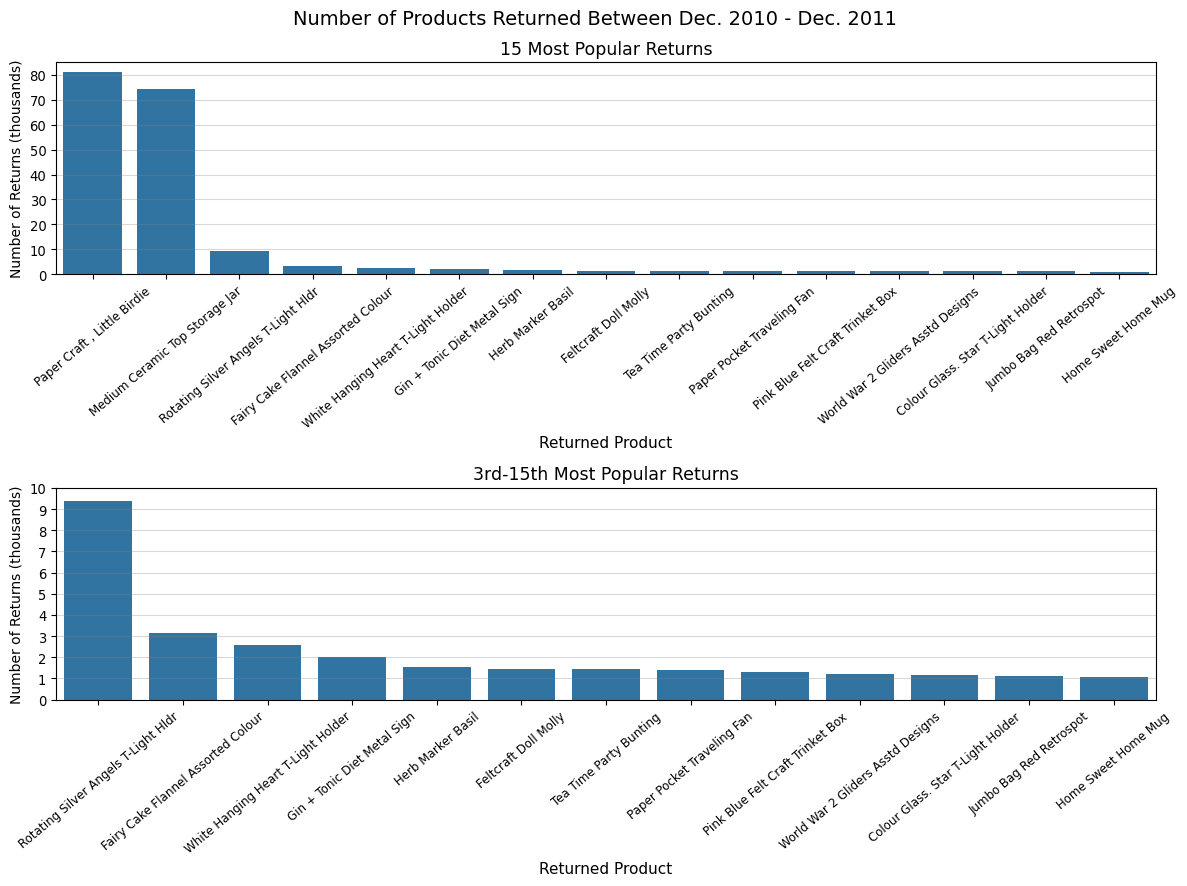

In [14]:
#Make a plot of the products that are returned most often - filter for those with at least 1000 returns
display(returns_products_counts[returns_products_counts['# transactions'] > 999].reset_index(drop=True))

#initialize figure, include 2 plots
fig, axes = plt.subplots(nrows=2, figsize=(12,9))
#include all products
ax1 = sns.barplot(data=returns_products_counts[returns_products_counts['# transactions'] > 999], 
                  x=[*returns_products_counts[returns_products_counts['# transactions'] > 999].reset_index(drop=True).Description.str.title().values],
                  y=(returns_products_counts[returns_products_counts['# transactions'] > 999].reset_index(drop=True)['# transactions']/1000), 
                  ax=axes[0], color=sns.color_palette()[0])
#ignore two most-returned products bc they distort the differences in the following products
ax2 = sns.barplot(data=returns_products_counts[returns_products_counts['# transactions'] > 999][2:], 
                  x=[*returns_products_counts[returns_products_counts['# transactions'] > 999].reset_index(drop=True).Description.str.title().values][2:],
                  y=(returns_products_counts[returns_products_counts['# transactions'] > 999].reset_index(drop=True)['# transactions']/1000)[2:], 
                  ax=axes[1], color=sns.color_palette()[0])

#edit plot details
fig.suptitle('Number of Products Returned Between Dec. 2010 - Dec. 2011', fontsize=14)
for key, v in {'15 Most Popular Returns':[0, 81,10], '3rd-15th Most Popular Returns':[1, 11,1]}.items():
    plt.sca(axes[v[0]])
    plt.title(key, fontsize=12.5)
    plt.xlabel('Returned Product', fontsize=11)
    plt.xticks(rotation=40, fontsize=8.5)
    plt.ylabel('Number of Returns (thousands)')
    plt.yticks(ticks=range(0,v[1],v[2]), fontsize=9.5)
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The two plots above illustrate the products which were returned most often & how often they were returned between December 2010 & December 2011. Note that the vertical axes are in increments of thousands. The 15 products displayed were the only ones which were returned at least 1,000 times. Two plots were made because the number of returns of the two most-returned products was so much greater than that of any other product, making it difficult to visualize the differences in returns of the rest of the products.

The most-returned product, "Paper Craft, Little Birdie," saw nearly 81,000 returns. The second most-returned product, "Medium Ceramic Top Storage Jar," was returned about 75,000 times. The next most-returned product, "Rotating Silver Angles T-Light HLDR (holder?)," was returned less than 10,000 times.

Moreover, the corresponding 'StockCode' values of these 'Description' values can be looked up to determine if there are any 'Description' values that do not specifically describe a product, but rather they seemingly describe the nature of the transaction. Regarding returns, these descriptions can be referenced via the `returns_non_products_counts` variable. As such, the 15 most-returned products, displayed in the plots above, were used to look up all of their corresponding 'StockCode' values. If there were any 'Description's with multiple 'StockCode' values, those multiple 'StockCode's were then used to look up all coresponding 'Description' values to look for any non-product descriptions that may have some relation as to the nature of these products' returns.

In [15]:
#Get corresponding data for 15 most-returned products

#Search "return_data" for products w/multiple associated 'StockCode's
#display(return_data[return_data.Description.isin([*returns_products_counts[returns_products_counts['# transactions'] > 999].Description.values])].groupby(
#    ['StockCode','Description']).size().reset_index().sort_values('Description').reset_index(drop=True))
    #15 rows

#Search "data" for products w/multiple associated 'StockCode's
#display(data[data.Description.isin([*returns_products_counts[returns_products_counts['# transactions'] > 999].Description.values])].groupby(
#    ['StockCode','Description']).size().reset_index().sort_values('Description').reset_index(drop=True))
    #17 rows -- "TEA TIME PARTY BUNTING" & "WHITE HANGING HEART T-LIGHT HOLDER" each have 2 'StockCode's: 
        #['47566b','47566B'] & ['85123A','85123a'] respectively

#Get associated 'StockCode's & all of their corresponding data, filtering for returns.
display(data[(data.StockCode.isin(['47566b','47566B','85123A','85123a'])) & (data.Quantity < 0)].sort_values(
    ['StockCode','InvoiceDate']).reset_index())


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,47471,C540417,47566B,TEA TIME PARTY BUNTING,-50,2011-01-07 10:56:00,3.75,13680.0,United Kingdom
1,116064,C546191,47566B,TEA TIME PARTY BUNTING,-35,2011-03-10 10:57:00,0.70,16422.0,United Kingdom
2,119234,C546535,47566B,TEA TIME PARTY BUNTING,-1,2011-03-14 14:11:00,4.25,15502.0,United Kingdom
3,160142,C550456,47566B,TEA TIME PARTY BUNTING,-1300,2011-04-18 13:08:00,2.55,15749.0,United Kingdom
4,163080,C550533,47566B,TEA TIME PARTY BUNTING,-2,2011-04-19 11:03:00,4.95,17071.0,United Kingdom
5,203752,554551,47566B,reverse previous adjustment,-1300,2011-05-25 09:58:00,0.00,NaN,United Kingdom
6,203761,554553,47566B,incorrectly credited C550456 see 47,-1300,2011-05-25 09:59:00,0.00,NaN,United Kingdom
7,367300,C568879,47566B,TEA TIME PARTY BUNTING,-33,2011-09-29 12:38:00,4.15,14680.0,United Kingdom
8,378235,C569636,47566B,TEA TIME PARTY BUNTING,-3,2011-10-05 12:14:00,4.95,12841.0,United Kingdom
9,14529,C537602,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1,2010-12-07 12:45:00,2.55,17511.0,United Kingdom


Of the 15 most-returned products, only two of them associated with multiple 'StockCode' values; "TEA TIME PARTY BUNTING" & "WHITE HANGING HEART T-LIGHT HOLDER" each have two 'StockCode's. For these two 'Description' values, the corresponding 'StockCode' values & all of their corresponding 'Description' values relating to returns were obtained & are shown above. Note that the transactions with 'Description' values that do not describe a specific product (& aren't formatted in uppercase letters) are the only non-cancellations among these transactions because their 'InvoiceNo' values do not begin with a "C." Other parameters in the dataset can be used to try & determine what transactions may be related to one another if any. For example, similar 'Quantity' values & reasonably adjacent 'InvoiceDate's could provide such clues. The investigation & discussion of these data points are discussed below.

In [16]:
#Investigate non-product 'Description's

#'InvoiceNo' 575722 references 'StockCode' 22804 & has 'Quantity' of -256

#find other products of this 'StockCode'
display(data[data.StockCode == '22804'].groupby(['StockCode','Description']).size().reset_index().rename(columns={0:'# transactions'}))
#find products associated w/the referenced 'StockCode' 85123a(/A)
display(data[data.StockCode.isin(['85123a','85123A'])].groupby(['StockCode','Description']).size().reset_index().rename(
    columns={0:'# transactions'}))
#filter for transaction of interest
    #display(data[(data.StockCode == '22804') & (data.Description != data.Description.str.upper())].reset_index())
#get data of these two related transactions & most adjacent data for context
display(data.loc[456827:456833,:])
#search for original order by specifying 'StockCode' & 'Quantity'
display(data[(data.StockCode == '85123A') & (np.abs(data.Quantity) == 256)].reset_index())
#search dataset for all orders by relevant customer (14646.0)
    #customer placed over 2,000 orders --> filter for relevant 'StockCode's
display(data[(data.CustomerID == 14646.0) & (data.StockCode.isin(['22804','85123A','85123a']))])

,StockCode,Description,# transactions
0,22804,CANDLEHOLDER PINK HANGING HEART,409
1,22804,PINK HANGING HEART T-LIGHT HOLDER,79
2,22804,Wrongly mrked had 85123a in box,1


,StockCode,Description,# transactions
0,85123A,?,1
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,9
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2290
3,85123A,wrongly marked carton 22804,1
4,85123a,WHITE HANGING HEART T-LIGHT HOLDER,67


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
456827,575718,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,24,2011-11-10 18:04:00,3.29,16907.0,United Kingdom
456828,575719,35954,check,24,2011-11-10 18:08:00,0.00,NaN,United Kingdom
456829,575720,21817,check,-8,2011-11-10 18:09:00,0.00,NaN,United Kingdom
456830,575721,22804,Wrongly mrked had 85123a in box,-256,2011-11-10 18:19:00,0.00,NaN,United Kingdom
456831,575722,85123A,wrongly marked carton 22804,-256,2011-11-10 18:20:00,0.00,NaN,United Kingdom
456832,575723,22554,PLASTERS IN TIN WOODLAND ANIMALS,12,2011-11-10 18:33:00,1.65,14748.0,United Kingdom
456833,575723,23480,MINI LIGHTS WOODLAND MUSHROOMS,8,2011-11-10 18:33:00,3.75,14748.0,United Kingdom


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,63450,541570,85123A,WHITE HANGING HEART T-LIGHT HOLDER,256,2011-01-19 12:34:00,2.55,14646.0,Netherlands
1,456831,575722,85123A,wrongly marked carton 22804,-256,2011-11-10 18:20:00,0.00,NaN,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
63450,541570,85123A,WHITE HANGING HEART T-LIGHT HOLDER,256,2011-01-19 12:34:00,2.55,14646.0,Netherlands
492627,578140,85123A,WHITE HANGING HEART T-LIGHT HOLDER,160,2011-11-23 10:58:00,2.55,14646.0,Netherlands


In regards to the 'StockCode' values associated with the **"WHITE HANGING HEART T-LIGHT HOLDER"** 'Description':
- There are 43 associated transactions pertaining to returns of this 'StockCode' (85123A). Only one of these transactions ('InvoiceNo' 575722) has an alternative 'Description' value that does not describe a specific product: "wrongly marked carton 22804."
    - Naturally, this value was looked up in the main dataset, which resulted in 489 data points with the 'StockCode' 22804. Of these data points, there are three unique product 'Description's, including "CANDLEHOLDER PINK HANGING HEART" (409 instances), "PINK HANGING HEART T-LIGHT HOLDER" (79 instances), & one instance of "Wrongly mrked had 85123a in box;" note the similarity in 'Description' between the former two products & "WHITE HANGING HEART T-LIGHT HOLDER." The value referenced in this latter transaction ('InvoiceNo' 575721), 85123a, directly relates to the transaction that spurred this search, with the 'Description' above.
    - Moreover, the 'InvoiceNo's of these two transactions are consecutive, & their 'InvoiceDate's are one minute apart, further suggesting a relationship between them.
    - To find the order(s) associated with these transactions, their 'Quantity' value (-256) was used in combination with the two 'StockCode's that have been referenced. There were no other transactions with the value 22804, but the 'StockCode' 85123A yielded one other transaction with an 'InvoiceNo' of 541570 & 'InvoiceDate' approximately ten months prior to the associated returns. Unfortunately, the 'CustomerID' value of the return is null, & the 'Country' value of both the order & returns are different; however, since the company is based in the UK, this may be the reason as to why the 'Country' value of the return transaction is the "United Kingdom" & not the same as the order, which would relate to the residence of the customer who placed the order. Furthermore, the 'Description' of this other transaction is "WHITE HANGING HEART T-LIGHT HOLDER," which directly relates to the 'Description' of most other transactions with the 'StockCode' 85123A, as seen in the dataset above.
    - Subsequently, the 'CustomerId' of the primary transaction searched to determine if this customer ever placed a similar order. If they did, it would give a further indication as to whether they ever returned their initial order or not. This customer, with 'CustomerID' "14646.0," had placed over 2,000 orders in the dataset. To search for the transactions of interest, the relevant 'StockCodes' were used; 22804, 85123A, 85123a. This returned two transactions of "WHITE HANGING HEART T-LIGHT HOLDER" with 'InvoiceNo's 541570 & 578140. The first order was the primary order mentioned previously. The second order, which ordered 160 of this item, was placed on November 23, 2011, which is about two weeks after the return transactions occurred (November 10, 2011). 
    - Given this information, it is reasonable to assume the following:
        - A customer based in the Netherlands placed an order for 256 "White Hanging Heart T-Light Holder" items in January, 2011. Two returns were filed by the company on November 10, 2011, each for 256 items of the two 'StockCode's 22804 & 85123A. About two weeks later, on November 23, 2011, the same customer placed an order for 160 of the same item.
        - After investigating the data associated with these two 'StockCode's along with the 'Description's provided in these return transactions, the most probable outcome (reason for the return) was that the company misplaced or mislabeled one of either "CANDLEHOLDER PINK HANGING HEART" or "PINK HANGING HEART T-LIGHT HOLDER" with the 'StockCode' 85123A, when in actuality it had the 'StockCode' of 22804.

All of this to say, only one transaction regarding a return of the "WHITE HANGING HEART T-LIGHT HOLDER" 'Description' had accompanying details regarding the return.

In [17]:
#Investigate non-product 'Description's, discussed above

#'IinvoiceNo' 554551: "reverse previous adjustment"
#'InvoiceNo' 554553 references 'InvoiceNo' C550456

#find products associated w/the corresponding 'StockCode' 47566B(/b)
display(data[data.StockCode.isin(['47566B','47566b'])].groupby(['StockCode','Description']).size().reset_index().rename(
    columns={0:'# transactions'}))
#get data of these two relevant transactions & those adjacent
display(data.loc[203749:203763])
#get data of reference 'InvoiceNo' C550456
display(data[data.InvoiceNo == 'C550456'])
#search dataset for all orders by relevant customer (15749.0)
display(data[data.CustomerID == 15749.0])

#search data for TEA TIME TEA TOWELS
display(data[data.Description == 'TEA TIME TEA TOWELS'])
    #display(data[data.StockCode.isin(['47556B','47556b'])])
#search for 'UnitPrice's of TEA TIME PARTY BUNTING
display(data[(data.Description == 'TEA TIME PARTY BUNTING') & (data.UnitPrice == 2.55)])
    #display(data[data.Description == 'TEA TIME PARTY BUNTING'].groupby('UnitPrice').size().reset_index())
#search data for 'Descriptions' relating to "credit"
#display(data[(data.Description.str.contains('credit')) & (~data.Description.isna())])

display('--------------------------------------------------------------------------------')

#get data of relevance, in chronological order
display(data.loc[52770:52772,:], data.loc[160141:160143,:], data.loc[160540:160544,:], data.loc[203750:203762,:])


,StockCode,Description,# transactions
0,47566B,TEA TIME PARTY BUNTING,373
1,47566B,incorrectly credited C550456 see 47,2
2,47566B,reverse previous adjustment,1
3,47566b,TEA TIME PARTY BUNTING,102


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
203749,554549,22606,WOODEN SKITTLES GARDEN SET,1,2011-05-25 09:57:00,15.95,12747.0,United Kingdom
203750,554549,22607,WOODEN ROUNDERS GARDEN SET,2,2011-05-25 09:57:00,9.95,12747.0,United Kingdom
203751,554550,47566B,incorrectly credited C550456 see 47,1300,2011-05-25 09:57:00,0.00,NaN,United Kingdom
203752,554551,47566B,reverse previous adjustment,-1300,2011-05-25 09:58:00,0.00,NaN,United Kingdom
203753,554552,37342,POLKADOT COFFEE CUP & SAUCER PINK,96,2011-05-25 09:58:00,0.79,13694.0,United Kingdom
203754,554552,23202,JUMBO BAG VINTAGE LEAF,200,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203755,554552,23200,JUMBO BAG PEARS,200,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203756,554552,85099F,JUMBO BAG STRAWBERRY,200,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203757,554552,20712,JUMBO BAG WOODLAND ANIMALS,100,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203758,554552,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,100,2011-05-25 09:58:00,1.79,13694.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
160141,C550456,48185,DOORMAT FAIRY CAKE,-670,2011-04-18 13:08:00,6.75,15749.0,United Kingdom
160142,C550456,47566B,TEA TIME PARTY BUNTING,-1300,2011-04-18 13:08:00,2.55,15749.0,United Kingdom
160143,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,2011-04-18 13:08:00,2.55,15749.0,United Kingdom
160144,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,2011-04-18 13:08:00,1.85,15749.0,United Kingdom
160145,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2011-04-18 13:08:00,2.10,15749.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749.0,United Kingdom
52710,540815,21175,GIN + TONIC DIET METAL SIGN,2000,2011-01-11 12:55:00,1.85,15749.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom
52771,540818,47556B,TEA TIME TEA TOWELS,1300,2011-01-11 12:57:00,2.55,15749.0,United Kingdom
52772,540818,48185,DOORMAT FAIRY CAKE,670,2011-01-11 12:57:00,6.75,15749.0,United Kingdom
160141,C550456,48185,DOORMAT FAIRY CAKE,-670,2011-04-18 13:08:00,6.75,15749.0,United Kingdom
160142,C550456,47566B,TEA TIME PARTY BUNTING,-1300,2011-04-18 13:08:00,2.55,15749.0,United Kingdom
160143,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,2011-04-18 13:08:00,2.55,15749.0,United Kingdom
160144,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,2011-04-18 13:08:00,1.85,15749.0,United Kingdom
160145,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2011-04-18 13:08:00,2.10,15749.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
52771,540818,47556B,TEA TIME TEA TOWELS,1300,2011-01-11 12:57:00,2.55,15749.0,United Kingdom
160543,550461,47556B,TEA TIME TEA TOWELS,1300,2011-04-18 13:20:00,2.10,15749.0,United Kingdom


...

'--------------------------------------------------------------------------------'

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
52770,540817,21754,HOME BUILDING BLOCK WORD,3,2011-01-11 12:56:00,5.95,14209.0,United Kingdom
52771,540818,47556B,TEA TIME TEA TOWELS,1300,2011-01-11 12:57:00,2.55,15749.0,United Kingdom
52772,540818,48185,DOORMAT FAIRY CAKE,670,2011-01-11 12:57:00,6.75,15749.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
160141,C550456,48185,DOORMAT FAIRY CAKE,-670,2011-04-18 13:08:00,6.75,15749.0,United Kingdom
160142,C550456,47566B,TEA TIME PARTY BUNTING,-1300,2011-04-18 13:08:00,2.55,15749.0,United Kingdom
160143,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,2011-04-18 13:08:00,2.55,15749.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
160540,550459,79163,BLACK CHAMPAGNE GLASS,12,2011-04-18 13:17:00,0.39,18116.0,United Kingdom
160541,550460,47556B,did a credit and did not tick ret,1300,2011-04-18 13:18:00,0.00,NaN,United Kingdom
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-04-18 13:20:00,2.40,15749.0,United Kingdom
160543,550461,47556B,TEA TIME TEA TOWELS,1300,2011-04-18 13:20:00,2.10,15749.0,United Kingdom
160544,550461,48185,DOORMAT FAIRY CAKE,670,2011-04-18 13:20:00,6.35,15749.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
203750,554549,22607,WOODEN ROUNDERS GARDEN SET,2,2011-05-25 09:57:00,9.95,12747.0,United Kingdom
203751,554550,47566B,incorrectly credited C550456 see 47,1300,2011-05-25 09:57:00,0.00,NaN,United Kingdom
203752,554551,47566B,reverse previous adjustment,-1300,2011-05-25 09:58:00,0.00,NaN,United Kingdom
203753,554552,37342,POLKADOT COFFEE CUP & SAUCER PINK,96,2011-05-25 09:58:00,0.79,13694.0,United Kingdom
203754,554552,23202,JUMBO BAG VINTAGE LEAF,200,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203755,554552,23200,JUMBO BAG PEARS,200,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203756,554552,85099F,JUMBO BAG STRAWBERRY,200,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203757,554552,20712,JUMBO BAG WOODLAND ANIMALS,100,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203758,554552,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,100,2011-05-25 09:58:00,1.79,13694.0,United Kingdom
203759,554552,21929,JUMBO BAG PINK VINTAGE PAISLEY,100,2011-05-25 09:58:00,1.79,13694.0,United Kingdom


In regards to the 'StockCode' values associated with the **"TEA TIME PARTY BUNTING"** 'Description':
- There are nine associated transactions pertaining to returns of this 'StockCode' (47566B). Two of these transactions ('InvoiceNo's 554551, 554553) have an alternative 'Description' value that does not describe a specific product: "reverse previous adjustment" & "incorrectly credited C550456 see 47" respectively.
- Regarding these latter two non-product descriptions, there are several relevant details & transactions that were unpacked.

In total, there are seven data points that are seemingly relevant to this investigation. Keep in mind that the associated 'Description' that drove this investigation is "TEA TIME PARTY BUNTING."
1) First, in mid-January, the customer placed an order for 1300 Tea Time Tea Towels, each priced at 2.55 pounds, in mid-January, which totaled 3,315 pounds ('InvoiceNo' 540818). This product, Tea Time Tea Towels, only appears twice in the entire dataset, both of which pertain to this customer.
2) Three months later (mid-April), the customer returned something that is slightly different (according to the company) in 'StockCode' & 'Description,' but it has the same 'Quantity' (in magnitude, but negative) & 'UnitPrice,' suggesting that this order being returned is possibly the same product as was initially ordered, regardless of whether that was intentional or not ('InvoiceNo' C550456). The product described in this return, Tea Time Party Bunting, appears in 475 instances across the dataset, but this return is the only instance in which the 'UnitPrice' was 2.55 pounds. For more context, the 'UnitPrice' of this item exceeded 2.55 pounds in 473 of these 475 instances, which makes this 'UnitPrice' of 2.55 pounds slightly suspicious.
3) Ten minutes later after this return invoice, the company then files an invoice (550460) with the 'Description' "did a credit and did not tick ret[urn?]," & with the same 'StockCode' as the Tea Time Tea Towels initially ordered by the customer, intentionally or not. It is not immediately interpretable as to what this description means or what this invoice refers to, but the most logical reasoning is that the company went to file the return that the customer placed & accidentally placed/filed an order instead. The "did a credit" could be the company filing the return, & the "did not tick ret"—which presumably is a cut off (or abbreviation) of the word "return"—could be the company accidentally not labeling the invoice as a return. This explains why the 'Quantity' is positive, because a negative 'Quantity' indicates a return. Of course, this invoice would presumably be rectified after the fact, but nothing was officially filed for over a month.
4) Two minutes following this non-product invoice, the customer places another order ('InvoiceNo' 550461) which contains the exact same 'StockCode,' 'Description,' & 'Quantity' values as their original order in mid-January; however, the 'UnitPrice' value is now 2.10 instead of 2.55, which would total 2,730 pounds—585 pounds less than their original order. Recall that this specific product only appears in the dataset twice, but these data points each had two different 'UnitPrice's; 2.55 & 2.10 pounds. Therefore, it is very difficult to discern what the actual 'UnitPrice' of these Tea Time Tea Towels should be. Moreover, given that the Tea Time Party Bunting product—the product specified in the return prior—only had one instance of a 'UnitPrice' of 2.55 pounds, which was in said return, it suggests that the company may have mischarged the customer in their initial order in mid-January. Another possibility for the difference in price is that the company offered the customer a discount on their second order after having messed up their initial one.

In addition, there are three other invoices that seem to be related, but they were filed more than a month later (late May).

5) The 'InvoiceNo' 554550 has the 'StockCode' 47566B (associated with the Tea time Party Bunting item), a 'Quantity' of 1300 (not a return), & a 'Description' of "incorrectly credited C550456 see 47." This statement seems to refer to multiple things, namely the invoice "C550456," which is the return filed by the customer in mid-April, & the "47." On its own, this pair of characters is too vague to be able to relate it to anything in the dataset; there is no 'InvoiceNo' 47. Perhaps it, as was the case with the non-product description which seemingly cut off the word "return," cut off the rest of the inputted description as well, which would lead to 'InvoiceNo's or 'StockCode's beginning with "47"; however, there are no such invoice numbers. Moreover, of the invoices that have been mentioned in this discussion, their 'StockCode's all start with "47," but without more information, there is no way to discern which of the two 'StockCode's this may be referring to.
    - This leaves the 'InvoiceNo' C550456 as the primary clue, which has the corresponding 'StockCode' of 47566B (Party Bunting). By "incorrectly credited C550456," this could mean multiple things, but the most probable may involve the company describing why the customer filed the return & the company's part in it. For example, it could mean that the company incorrectly charged the customer, which would explain the inconsistencies in the 'UnitPrice' variable. Alternatively, it could mean that the company sent the customer the wrong product. Regardless, it is clear that the company made a mistake when filing the return that this customer placed that had to with the specific product and/or the unit price.

6) The immediately subsequent invoice, 554551, which occurred one minute later, seemingly negates the actions of invoice 554550 because the 'Quantity' in 554551, -1300, is the exact opposite of that of 554550, 1300. As such, it suggests that the 'Quantity' in invoice 554550 was supposed to be negative, particularly given that that of 'InvoiceNo' C550456 was negative, indicating a return, but they made it positive perhaps by accident. Furthermore, the aforementioned non-product 'Description' that occurred a month earlier, "did a credit and did not tick ret," may be related because it suggests that the company attempted to do a credit in the form of a return, but a mistake was made & the return/invoice was not filed correctly. The main counterpoint to this theory would regard the 'InvoiceDate' of these invoices. Why would invoices 554550 & 554551 occur over a month after the first four invoices, including the directly referenced C550456? Perhaps, the company did not fully rectify and/or understand the situation until then, or they didn't officially file these invoices until late May. Nonetheless, it further mystifies this investigation.
7) The final data point of relevance, 'InvoiceNo' 554553, which occurred within a couple of minutes of invoices 554550 & 554551, was identical to invoice 554550 except that the 'Quantity' was -1300 instead of 1300, indicating that this invoice was a return. Perhaps this invoice refers to the return the customer filed in mid-April.

In totality, the return regarding an instance of the product "TEA TIME PARTY BUNTING" is speculated as follows. Given the inconsistencies & lack of information in the dataset, it is difficult to ascertain exactly what occurred, but a logical, best conjecture as to what happened is described chronologically below. Ultimately, there is no direct explanation for the return or the inconsistencies across these data points. The corresponding invoice number and stock code for each data points is provided in parentheses.
- A customer places an order in mid-January. ('InvoiceNo' 540818, 'StockCode' 47556B).
- In mid-April, the customer files a return for an order, likely related to their mid-January order, either because the products they received were incorrect and/or they were overcharged. The most probable reason was that they received the incorrect item. ('InvoiceNo' C550456, 'StockCode' 47566B).
- 12 minutes later, the customer places the same mid-January order which is different only in 'UnitPrice' (& therefore total price). A possible explanation for this difference in 'UnitPrice' may be that the customer received a discount from the company after they sent them the wrong product in their mid-January order. Why the customer did not file this return for three months is another question, an unanswerable one with the given data. At this point, the customer had no further involvement in this situation. ('InvoiceNo' 550461, 'StockCode' 47556B).
- Ten minutes after the customer placed the return & two minutes before they filed their second order of Tea Towels, the company made an invoice with the same 'StockCode' as the mid-January order. Described as "did a credit and did not tick ret," this invoice is most likely the company compensating for a return pertaining to this mid-January order, specifically the 'StockCode.' Since the actual return filed had a different 'StockCode,' perhaps the company felt the need to file a similar return for the item that was actually ordered. However, in this invoice, the company seems to have made a mistake. Specifically, Specifically, the company credited the customer for their return, but they made a clerical error in that they did not tick "return" in their system—whether this impacted the customer, or it was kept within the realm of their data system is unknown. This mistake, seemingly, is not noticed/rectified by the company until late May (over a month later), at which point they make three new invoices addressing it, all of which occurred within three minutes of each other. ('InvoiceNo' 550460, 'StockCode' 47556B).
    - The first invoice directly refers to the order filed by the customer by 'InvoiceNo' & indirectly in that they both have the same 'StockCode.' The 'Description' of this invoice suggests that the company made a mistake when crediting the customer for their return filed in mid-April, as similarly noted in the company's own invoice ten minutes after this return. However, the company made another similar mistake in that this invoice was not marked as a return when it should have been. The immediately subsequent invoice was made to correct this. ('InvoiceNo' 554550, 'StockCode' 47566B).
    - The second invoice, as just described, negated the actions of the first invoice by labelling it as a return. As such, the 'Quantity' in this & the previous invoice cancelled out. ('InvoiceNo' 554551, 'StockCode' 47566B).
    - The third invoice seemingly performed the same actions as the first invoice for the same reasons except that it was filed correctly as a return whereas the first invoice failed to do so. ('InvoiceNo' 554553, 'StockCode' 47566B). 
- In total, the 'StockCode' 47556B had a sum 'Quantity' of 2,600, whereas the 'StockCode' 47566B had a sum 'Quantity' of -2,600. Presumably, the way the invoices were made & manipulated in the dataset accounted for the inconsistencies of the relevant customer's orders & why they issued a return in the first place.

All of this to say, only one transaction regarding a return of the "TEA TIME PARTY BUNTING" 'Description' had accompanying details regarding the return.

## Analysis I - Conclusions
This section sought to determine & analyze the products which saw the most returns. Of the 530,000-odd data points in the dataset, about 9,250 of them pertained to returns.

Using this subset of data, there were 2,109 unique different product 'Description's that saw at least one return each in the 12-month span of data. Of these products, there were 15 different product 'Description's which accounted for at least 1,000 returns each. "PAPER CRAFT, LITTLE BIRDIE" saw more than 80,000 returns, & "MEDIUM CERAMIC TOP STORAGE JAR" accounted for about 75,000 returns. No other product was returned more than 10,000 times.

The 'Description' column does not always specify a certain product. In these cases, the parameter most probably describes a reason for a complication with the invoice, such as a mistake processing the order or with the product. These details were used to search the data of these 15 most returned products to find any accompanying data regarding why they may have been returned. A lengthy investigative process found that an order for two of these 15 products, with 'Description's "WHITE HANGING HEART T-LIGHT HOLDER" & "TEA TIME PARTY BUNTING," included such details in at least one invoice each. Unfortunately, these non-product descriptions are not the most informative, & so the more precise details regarding these transactions, & those related, had to be pieced together. These two products were the 5th & 9th most-returned products in the dataset with 2,578 & 1,424 returns each.

Ultimately, this investigation came to the conclusion that, in the case of the White-Hanging-Heart-T-Light-Holder invoice, the company likely mislabelled their products, leading to them shipping the customer a product that they did not order. 
In the case of the Tea-Time-Party-Bunting invoice, the company likely made multiple mistakes. Firstly, they shipped the customer the wrong product. When the company filed the return, they made another error, seemingly a clerical error. 
Although the details of most of the returns are lacking, those that are available still provided valuable insight as to why some products may have been returned.


This data associated with returns could be broken down further in additional explorative analysis. For instance, the 'Country' parameter could be incorporated to determine the country in which customers return products most often. Obviously, since the company is based in the United Kingdom, the data would likely be biased towards customers in the UK. Furthermore, returns could be analyzed over time using the 'InvoiceDate' parameter to check if there was an specific time during the year in which the company saw more or less returns than usual.

# Analysis II
📊 **Visualize**: Create a plot visualizing the profits earned from UK customers weekly, monthly, and quarterly.

Firstly, this dataset does not have a direct parameter that measures total profits. Fortunately, this value is easily calculable, & can be done by multiplying the 'Quantity' & 'UnitPrice' parameters together for each invoice. Then, they can be totaled over the period of time or condition of interest. Furthermore, as seen in **Analysis I**, the 'Quantity' parameter is more dynamic than it might seem to an individual unfamiliar with the dataset. Specifically, some invoices have a negative 'Quantity,' indicating transactions that pertained to returns. Such transactions are not of interest in regards to this prompt & have to be excluded. Since the 'Quantity' column is an integer data type, there is no concern that there are any strange other characters or values (i.e. "?").

With these profits, they can be calculated & plotted over the different periods of time of interest. Other aggregate statistics regarding the profits earned (over time & in general) could be obtained & used as a comparison tool. For example, of the 12 months of data, which months saw a total profit earning above or below the monthly average? Recall that the dataset spans the dates Dec. 1, 2010 to Dec. 9, 2011, so there are technically 13 months of data.

In the cleaned version of the dataset, there are no null values in these relevant columns.

In [18]:
#get data w/positive 'Quantity'
profit_data = data[data.Quantity > 0]

#create 'Profit' column calculating profit made per 'InvoiceNo'
profit_data = profit_data.assign(new_col=lambda x: x.Quantity * x.UnitPrice).rename(columns={'new_col':'Profit (£)'})
#display(profit_data)


Before proceeding with specific time-based calculations, it can be useful to define the exact week number, month, & quarter each 'InvoiceDate' corresponds to. Such data can be used as a reference to determine the exact time & day any specific data point corresponds to.

In [19]:
#Get year, week, month, & quarter for each 'InvoiceDate'
dates_W_M_Q = profit_data.copy()

dates_W_M_Q['Year'] = dates_W_M_Q.InvoiceDate.dt.year
dates_W_M_Q['Week #'] = dates_W_M_Q.InvoiceDate.dt.isocalendar().week
dates_W_M_Q['Month'] = dates_W_M_Q.InvoiceDate.dt.month
dates_W_M_Q['Quarter'] = dates_W_M_Q.InvoiceDate.dt.quarter

#drop unnecessary columns
dates_W_M_Q = dates_W_M_Q.drop(columns=['InvoiceNo','StockCode','Description','Quantity','UnitPrice','CustomerID','Country','Profit (£)'])
display(dates_W_M_Q)


,InvoiceDate,Year,Week #,Month,Quarter
0,2010-12-01 08:26:00,2010,48,12,4
1,2010-12-01 08:26:00,2010,48,12,4
2,2010-12-01 08:26:00,2010,48,12,4
3,2010-12-01 08:26:00,2010,48,12,4
4,2010-12-01 08:26:00,2010,48,12,4
...,...,...,...,...,...
541904,2011-12-09 12:50:00,2011,49,12,4
541905,2011-12-09 12:50:00,2011,49,12,4
541906,2011-12-09 12:50:00,2011,49,12,4
541907,2011-12-09 12:50:00,2011,49,12,4


#### Profits Earned on a Weekly Basis
In this dataset, there 53 distinct weeks worth of data. In any week, there was anywhere between 4,467 (week 51 in 2010) & 20,461 invoices (week 46 in 2011). The mean & median number of weekly invoices is about 9,925 & 8,649 respectively, indicating a positive skew. Given the variety of invoices that were received per week, it could be a potential catalyst for outliers seen in the upcoming plots; however, on a smaller time basis, as is the case here, such outliers are less likely to be present than would be the case for longer time intervals (i.e. months, quarters).

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\1692522634.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(labels=num_inv_W.Week.str[:2])


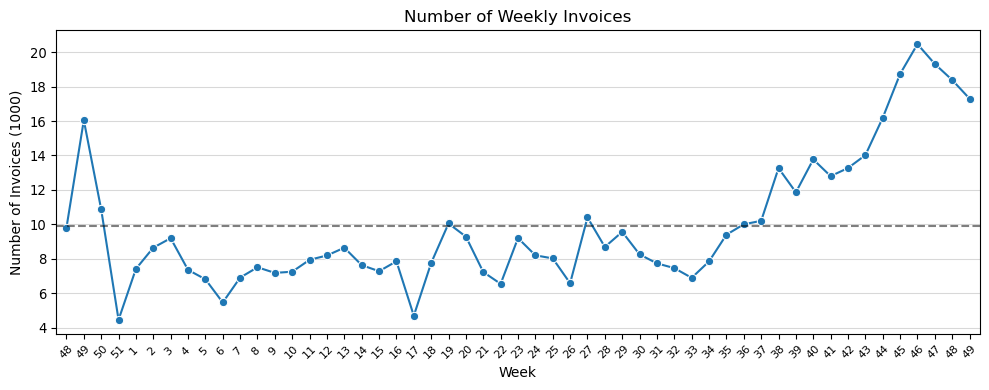

In [20]:
#Get idea of number of invoices per week
num_inv_W = dates_W_M_Q.groupby(['Year','Week #']).InvoiceDate.size().reset_index().rename(
    columns={'InvoiceDate':'# Invoices'})
#display(num_inv_W)

#Have to specify the year for each week
for i in num_inv_W.index:
    if num_inv_W.loc[i,'Year'] == 2010:
        num_inv_W.loc[i,'Week'] = "{} (2010)".format(num_inv_W.loc[i,'Week #'])
    else:
        num_inv_W.loc[i,'Week'] = "{} (2011)".format(num_inv_W.loc[i,'Week #'])

fig = plt.figure(figsize=(10,4))
#Plot # invoices per week
ax1 = sns.lineplot(data=num_inv_W, x='Week', y=num_inv_W['# Invoices']/1000, marker='o')
#plot avg # weekly invoices
ax1.axhline(y=num_inv_W['# Invoices'].mean()/1000, linestyle='--', alpha=0.5, color='black')

plt.title('Number of Weekly Invoices', fontsize=12)
ax1.set(xlim=(-0.6,len(num_inv_W.Week)-0.4))
plt.xticks(fontsize=8, rotation=45)
ax1.set_xticklabels(labels=num_inv_W.Week.str[:2])
plt.yticks(fontsize=9.5)
plt.ylabel('Number of Invoices (1000)')
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


The plot above displays the number of invoices the company received per week. The horizontal, dashed, black line indicates the average number of weekly invoices. 
In the first three weeks, the number of invoices is relatively high, at least above average; however, from the last week in 2010 up until week 36 in 2011 (early September), the number of invoices was considerably low. Over this time (37 weeks), the number of ivoices exceeded the average number of weekly invoices (~ 10,000) twice (~ 5.5%). From week 36 onwards (in 2011), the number of weekly invoices exceeded this average. 
The least number of invoices was in the last week of 2010. The most invoices processed was in week 46 of 2011 (mid-November).

In [21]:
#Calculate profits per week including aggregate statistics. 
    #Separate data by year to differentiate between the Dec 2010 & Dec 2011 data.

#get 2010 data
profits_W_10 = profit_data[profit_data.InvoiceDate.dt.year == 2010].groupby(profit_data.InvoiceDate.dt.isocalendar().week).agg(
    {'Profit (£)':['mean','sum']}).reset_index()

#get rid of MultiIndex, rename columns
profits_W_10 = pd.DataFrame(np.squeeze(profits_W_10.values).T, [x[0] for x in profits_W_10.columns]).T
profits_W_10.columns = ['Week','Avg Profit (£)','Total Profit (£)']

#Want to specify the year for each week
for i in profits_W_10.index:
    profits_W_10.loc[i,'Week'] = "{} (2010)".format(profits_W_10.loc[i,'Week'])

#display(profits_W_10)

#get 2011 data
profits_W_11 = profit_data[profit_data.InvoiceDate.dt.year == 2011].groupby(profit_data.InvoiceDate.dt.isocalendar().week).agg(
    {'Profit (£)':['mean','sum']}).reset_index()

#get rid of MultiIndex, rename columns
profits_W_11 = pd.DataFrame(np.squeeze(profits_W_11.values).T, [x[0] for x in profits_W_11.columns]).T
profits_W_11.columns = ['Week','Avg Profit (£)','Total Profit (£)']

#Want to specify the year for each week
for i in profits_W_11.index:
    profits_W_11.loc[i,'Week'] = "{} (2011)".format(profits_W_11.loc[i,'Week'])

#display(profits_W_11)

#Merge 2010, 2011 data together
profits_wkly = pd.concat([profits_W_10, profits_W_11])
#convert profit columns from objects to floats
profits_wkly[['Avg Profit (£)','Total Profit (£)']] = profits_wkly[['Avg Profit (£)','Total Profit (£)']].astype('float')
#get 'Total Profit' cumulatively
profits_wkly['Cumulative Profit (£)'] = profits_wkly['Total Profit (£)'].cumsum()
#round the profit columns to 2 decimals
profits_wkly[['Avg Profit (£)','Total Profit (£)','Cumulative Profit (£)']] = np.round(profits_wkly[['Avg Profit (£)','Total Profit (£)','Cumulative Profit (£)']], 2)

display(profits_wkly)


,Week,Avg Profit (£),Total Profit (£),Cumulative Profit (£)
0,48 (2010),18.83,184669.47,184669.47
1,49 (2010),20.51,329108.22,513777.69
2,50 (2010),19.81,215357.04,729134.73
3,51 (2010),20.67,92318.00,821452.73
0,1 (2011),17.98,133429.72,954882.45
1,2 (2011),22.31,192991.95,1147874.40
2,3 (2011),23.39,215227.01,1363101.41
3,4 (2011),16.92,124534.22,1487635.63
4,5 (2011),18.46,125847.36,1613482.99
5,6 (2011),19.54,106893.22,1720376.21


In [22]:
#Want to get some aggregate statistics on a weekly basis
display("Average Weekly Profits per Invoice: £ {}".format(np.round(profits_wkly['Avg Profit (£)'].mean(), 3)))
display("Average Total Weekly Profits: £ {}".format(np.round(profits_wkly['Total Profit (£)'].mean(), 3)))
display("Total Profit: £ {}".format(profit_data['Profit (£)'].sum()))


'Average Weekly Profits per Invoice: £ 20.17'

'Average Total Weekly Profits: £ 200377.107'

'Total Profit: £ 10619986.684'

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\495690469.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[v[0]].set_xticklabels(labels=profits_wkly.Week.str[:2])
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\495690469.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


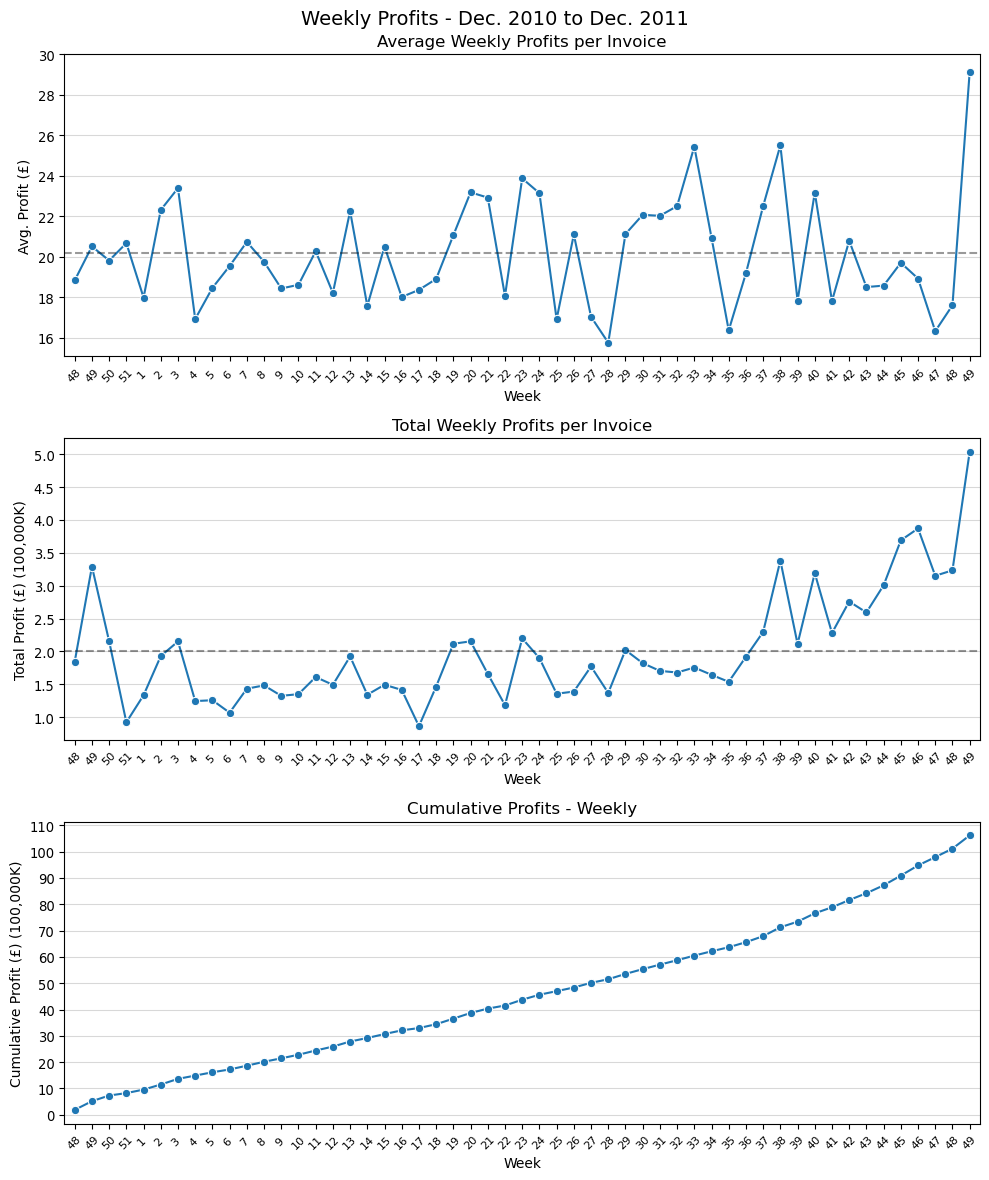

In [23]:
# Plot the weekly profits chronologically
fig, axes = plt.subplots(nrows=3, figsize=(10,12))
#WEEKLY AVERAGE
ax1 = sns.lineplot(data=profits_wkly, x='Week', y='Avg Profit (£)', marker='o', ax=axes[0])
#add average weekly avg
ax1.axhline(y=np.round(profits_wkly[['Avg Profit (£)','Total Profit (£)']].mean(), 3)[0], linestyle='--',alpha=0.4,color='black')
#WEEKLY TOTAL
ax2 = sns.lineplot(data=profits_wkly, x='Week', y=profits_wkly['Total Profit (£)']/100000, marker='o', ax=axes[1])
#add average weekly total
ax2.axhline(y=np.round(profits_wkly[['Avg Profit (£)','Total Profit (£)']].mean(), 3)[1]/100000, linestyle='--',alpha=0.4,color='black')
#CUMULATIVE TOTAL
ax3 = sns.lineplot(data=profits_wkly, x='Week', y=profits_wkly['Cumulative Profit (£)']/100000, marker='o', ax=axes[2])

fig.suptitle('Weekly Profits - Dec. 2010 to Dec. 2011', fontsize=14)
#edit plot details
for key, v in {'Average Weekly Profits per Invoice':[0, 16,31,2, 'Avg. Profit (£)'],
              'Total Weekly Profits per Invoice':[1, 1,5.1,0.5, 'Total Profit (£) (100,000K)'],
              'Cumulative Profits - Weekly':[2, 0,111,10, 'Cumulative Profit (£) (100,000K)']}.items():
    plt.sca(axes[v[0]])
    plt.title(key)
    axes[v[0]].set(xlim=(-0.6,len(profits_wkly.Week)-0.4))
    plt.xticks(fontsize=8, rotation=45)
    axes[v[0]].set_xticklabels(labels=profits_wkly.Week.str[:2])
    plt.yticks(ticks=np.arange(v[1],v[2],v[3]), fontsize=9.5)
    plt.ylabel(v[4])
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The three plots above display a few statistics regarding profits from invoices the company made on a weekly basis. Recall that the data spans December 1, 2010 to December 9, 2011, so there are 53 different weeks worth of data. In the plots, these data points are displayed chronologically over time.

The first plot, titled "Average Weekly Profits per Invoice," calculates the average profit made from invoices across each week. For instance, in the first week of the data, the average profit made from the corresponding invoices was about 19 pounds (£). The horizontal, dashed, black line indicates the average weekly profit of all these weekly values--just over £20. 
The average profit per invoice in the first week was about £1.3 less than the weekly average profit earning per invoice over the whole dataset. On the other hand, this value in the final week was about £9.0 above this weekly average profit earning per invoice. This may suggest that the company's profit-earning strategy had improved a year later, or that their products became more appealing &/or more popular to customers such that they had a greater incentive to purchase from them. 
Across the 53 weeks, the average profit per invoice was above average in 25 weeks (~ 47%). The longest streak of consecutive weeks in which the weekly average profit per invoice was below average is six weeks (weeks 43-48 -- late October to early December, 2011). The longest streak of consecutive weeks in which the weekly average profit per invoice was above average was also six weeks (weeks 29-34 -- mid-July to late August, 2011). 
As time went on, the difference between the average weekly profit per invoice & the total weekly average generally increased.
The largest weekly profit per invoice was in the last week of the dataset (about £29). The smallest weekly profit per invoice was week 28 in 2011--approximately mid-July (slightly less than £16).

The second plot, titled "Total Weekly Profits per Invoice," summed & illustrated the total profit made from invoices across each week. For instance, in the first week of the data, the total profit made from the associated invoices was about £185,000. The horizontal, dashed, black line indicates the average total profit of all these weekly values--about £200,400. Note that the vertical axis of this plot is in increments of £100,000.
The total weekly profit in the first week was slightly less than the average weekly profit over the whole dataset. On the other hand, this value in the final week was about 250% greater than this weekly average profit. 
Across the 53 weeks, the total weekly profit was above average in 20 weeks (~ 38%). Before week 37 in 2011 (mid-September), the total weekly profit exceeded the average only seven times. The longest streak of consecutive weeks in which the total weekly profit was below average was 15 weeks (weeks 4-18 -- late January to early May, 2011). The longest such streak in which the total weeky profit was above average was 13 weeks (weeks 37-49 -- mid-September to early December, 2011). 
The largest total weekly profit was in the last week of the dataset (just over £500,000). The smallest total weekly profit was week 17 in 2011--approximately late April/early May (about £860,000).

The third plot, titled "Cumulative Profits per Week," cumulatively summed the weekly values from the second plot. The total profit increases fairly consistently across most weeks. By the end of the dataset, the company made about £10.6 million in profits. Note that the vertical axis of this plot is in increments of £100,000. 
The two largest jumps in total profit from week to week occurred between the first & second week of the dataset (weeks 48, 49 in 2010) & between the penultimate & last week of the dataset (weeks 48, 49 in 2011). These two weekly increments in cumulative profit were about +£144,000 & +£180,000 respectively.

#### Profits Earned on a Monthly Basis
In this dataset, there are 13 distinct months worth of data. Acoss these months, there was anywhere between 24,857 (December, 2011) & 82,133 invoices (November, 2011). The mean & median number of monthly invoices is about 40,465 & 35,793 respectively, indicating a positive skew. Note that the first 12 months of data span longer time periods than the last month of data, the data of this last month may be more prone to the influence of outliers than the previous 12 months. On the other hand, the approximately 25,000 invoices received in this shortened last month was only a couple thousand less than the next least popular month (February, 2011) in terms of invoices. As such, there is not a huge cause for concern regarding any data points of this final month.

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\1273615750.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(labels=num_inv_M.Month.str[:2])


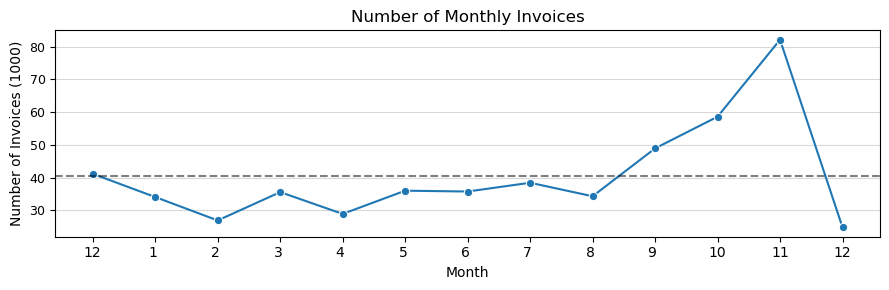

In [24]:
#Get idea of number of invoices per month
num_inv_M = dates_W_M_Q.groupby(['Year','Month']).InvoiceDate.size().reset_index().rename(
    columns={'InvoiceDate':'# Invoices'})
#display(num_inv_M)

#Have to specify the year for each month
for i in num_inv_M.index:
    if num_inv_M.loc[i,'Year'] == 2010:
        num_inv_M.loc[i,'Month'] = "{} (2010)".format(num_inv_M.loc[i,'Month'])
    else:
        num_inv_M.loc[i,'Month'] = "{} (2011)".format(num_inv_M.loc[i,'Month'])

fig = plt.figure(figsize=(9,3))
#Plot # invoices per month
ax1 = sns.lineplot(data=num_inv_M, x='Month', y=num_inv_M['# Invoices']/1000, marker='o')
#plot avg # monthly invoices
ax1.axhline(y=num_inv_M['# Invoices'].mean()/1000, linestyle='--', alpha=0.5, color='black')

plt.title('Number of Monthly Invoices', fontsize=12)
ax1.set_xticklabels(labels=num_inv_M.Month.str[:2])
plt.yticks(fontsize=9)
plt.ylabel('Number of Invoices (1000)')
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


The plot above displays the number of invoices the company received per month. The horizontal, dashed, black line indicates the average number of monthly invoices across all months. 
Similarly to the number of weekly invoices, they are considerably low for the first two-thirds of 2011, but the company experienced a significant upswing in invoices from September through November. From January 2011 up until September 2011, the number of monthly invoices was below the average number of monthly invoices (~ 40,500) across the whole dataset. Additionally, the number of invoices in December (both in 2010 & 2011) is also below the monthly average. 
The least number of invoices was in the last month of the dataset; however, this month was considerably shorter in length than all of the other 12 months, so this data point could be an outlier. The next least popular month in terms of invoices was February, 2011. The most invoices processed was in November, 2011.

In [25]:
#Calculate profits per month including aggregate statistics. 
    #Separate data by year to differentiate between the Dec 2010 & Dec 2011 data.

#get 2010 data
profits_M_10 = profit_data[profit_data.InvoiceDate.dt.year == 2010].groupby(profit_data.InvoiceDate.dt.month).agg(
    {'Profit (£)':['mean','sum']}).reset_index()

#get rid of MultiIndex, rename columns, convert 'Month' to integers to remove ".0" part
profits_M_10 = pd.DataFrame(np.squeeze(profits_M_10.values).T, [x[0] for x in profits_M_10.columns]).T
profits_M_10.columns = ['Month','Avg Profit (£)','Total Profit (£)']
profits_M_10['Month'] = profits_M_10.Month.astype('int')

#Want to specify the year for each month
for i in profits_M_10.index:
    profits_M_10.loc[i,'Month'] = "{} (2010)".format(profits_M_10.loc[i,'Month'])

#display(profits_M_10)

#get 2011 data
profits_M_11 = profit_data[profit_data.InvoiceDate.dt.year == 2011].groupby(profit_data.InvoiceDate.dt.month).agg(
    {'Profit (£)':['mean','sum']}).reset_index()

#get rid of MultiIndex, rename columns, convert 'Month' to integers to remove ".0" part
profits_M_11 = pd.DataFrame(np.squeeze(profits_M_11.values).T, [x[0] for x in profits_M_11.columns]).T
profits_M_11.columns = ['Month','Avg Profit (£)','Total Profit (£)']
profits_M_11['Month'] = profits_M_11.Month.astype('int')

#Want to specify the year for each month
for i in profits_M_11.index:
    profits_M_11.loc[i,'Month'] = "{} (2011)".format(profits_M_11.loc[i,'Month'])

#display(profits_M_11)

#Merge 2010, 2011 data together
profits_M = pd.concat([profits_M_10, profits_M_11])
#convert profit columns from objects to floats
profits_M[['Avg Profit (£)','Total Profit (£)']] = profits_M[['Avg Profit (£)','Total Profit (£)']].astype('float')
#get 'Total Profit' cumulatively
profits_M['Cumulative Profit (£)'] = profits_M['Total Profit (£)'].cumsum()
#round the profit columns to 2 decimals
profits_M[['Avg Profit (£)','Total Profit (£)','Cumulative Profit (£)']] = np.round(profits_M[['Avg Profit (£)','Total Profit (£)','Cumulative Profit (£)']], 2)

display(profits_M)


,Month,Avg Profit (£),Total Profit (£),Cumulative Profit (£)
0,12 (2010),19.94,821452.73,821452.73
0,1 (2011),20.23,689811.61,1511264.34
1,2 (2011),19.38,522545.56,2033809.90
2,3 (2011),20.11,716215.26,2750025.16
3,4 (2011),18.54,536968.49,3286993.65
4,5 (2011),21.34,769296.61,4056290.26
5,6 (2011),21.25,760547.01,4816837.27
6,7 (2011),18.67,718076.12,5534913.39
7,8 (2011),21.42,735717.26,6270630.65
8,9 (2011),21.58,1056435.19,7327065.84


In [26]:
#Want to get some aggregate statistics on a monthly basis
display("Average Monthly Profits per Invoice: £ {}".format(np.round(profits_M['Avg Profit (£)'].mean(), 3)))
display("Average Total Monthly Profits: £ {}".format(np.round(profits_M['Total Profit (£)'].mean(), 3)))
display("Total Profit: £ {}".format(profit_data['Profit (£)'].sum()))


'Average Monthly Profits per Invoice: £ 20.467'

'Average Total Monthly Profits: £ 816922.052'

'Total Profit: £ 10619986.684'

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\4195835917.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[v[0]].set_xticklabels(labels=profits_M.Month.str[:2])
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\4195835917.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


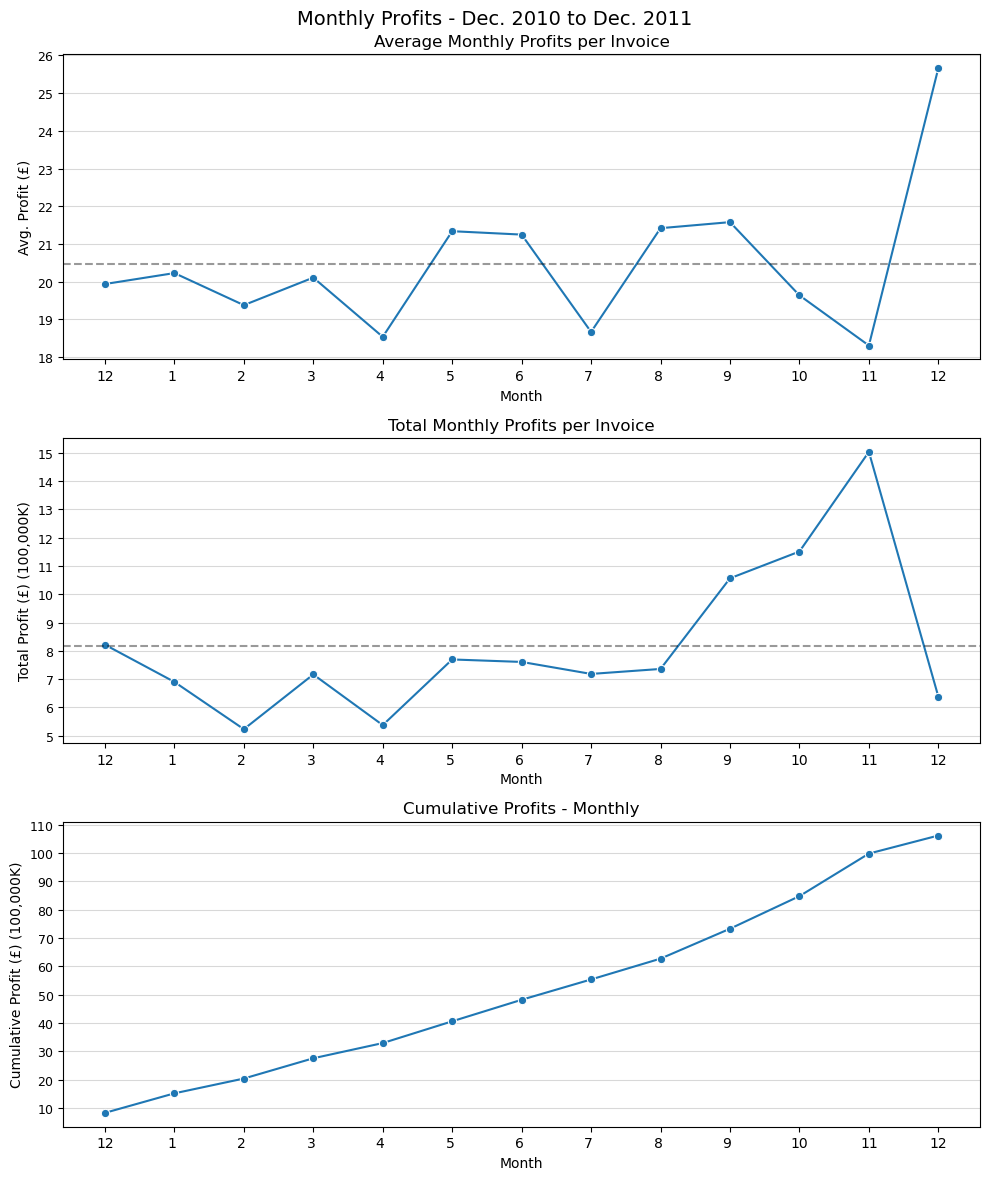

In [27]:
#Plot the monthly profits chronologically
fig, axes = plt.subplots(nrows=3, figsize=(10,12))
#MONHTLY AVERAGE
ax1 = sns.lineplot(data=profits_M, x='Month', y='Avg Profit (£)', marker='o', ax=axes[0])
#add average monthly avg
ax1.axhline(y=np.round(profits_M[['Avg Profit (£)','Total Profit (£)']].mean(), 3)[0], linestyle='--',alpha=0.4,color='black')
#MONTHLY TOTAL
ax2 = sns.lineplot(data=profits_M, x='Month', y=profits_M['Total Profit (£)']/100000, marker='o', ax=axes[1])
#add average monthly total
ax2.axhline(y=np.round(profits_M[['Avg Profit (£)','Total Profit (£)']].mean(), 3)[1]/100000, linestyle='--',alpha=0.4,color='black')
#CUMULATIVE TOTAL
ax3 = sns.lineplot(data=profits_M, x='Month', y=profits_M['Cumulative Profit (£)']/100000, marker='o', ax=axes[2])

fig.suptitle('Monthly Profits - Dec. 2010 to Dec. 2011', fontsize=14)
#edit plot details
for key, v in {'Average Monthly Profits per Invoice':[0, 18,27,1, 'Avg. Profit (£)'],
              'Total Monthly Profits per Invoice':[1, 5,16,1, 'Total Profit (£) (100,000K)'],
              'Cumulative Profits - Monthly':[2, 10,111,10, 'Cumulative Profit (£) (100,000K)']}.items():
    plt.sca(axes[v[0]])
    plt.title(key)
    axes[v[0]].set_xticklabels(labels=profits_M.Month.str[:2])
    plt.yticks(ticks=np.arange(v[1],v[2],v[3]), fontsize=9)
    plt.ylabel(v[4])
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The three plots above display a few statistics regarding profits from invoices the company made on a monthly basis. Recall that the data spans December 1, 2010 to December 9, 2011, so there are 13 different months worth of data. In the plots, these data points are displayed chronologically over time.

The first plot, titled "Average Monthly Profits per Invoice," calculates the average profit made from invoices across each month. For instance, in the first month of the data, the average profit made from the associated invoices was just under £20. The horizontal, dashed, black line indicates the average monthly profit of all these monthly values--about £20.5. 
The average profit per invoice in the first month was about £0.5 less than the monthly average profit per invoice over the whole dataset. On the other hand, this value in the final month was about £5.2 greater than this monthly average profit per invoice. This finding is similar to that in the previous section, which analyzed the data on a weekly basis. 
Across the 13 months, the average profit per invoice was above average in five months (~ 38%). The longest streak of consecutive months in which the monthly average profit per invoice was above average is two months -- there were two such streaks, both in the middle of 2011. The longest streak of consecutive months in which the monthly average profit per invoice was below average is five months (Dec., 2010 through April, 2011). 
Generally, the difference between the average monthly profit per invoice & the total monthly average increased as time went on. The largest monthly profit per invoice was in the last month of data, December, 2010 (about £26); however, this month did not cover the same time span as the other 12 months did & as such, accounted for fewer invoices. Therefore, this value is not quite as representative as those of the other 12 months. The smallest monthly profit per invoice was in the month prior: November, 2011 (about £18).

The second plot, titled "Total Monthly Profits per Invoice," summed & illustrated the total profits made from invoices across each month. For instance, in the first month of the data, the total profit made from the associated invoices was about £820,000. The horizontal, dashed, black line indicates the average total profit of all these monthly values--about £817,000. Note that the vertical axis of this plot is in increments of £100,000. 
The total monthly profit in the first month was slightly greater than the average monthly profit over the whole dataset. On the other hand, this value in the final month was about 30% less than this monthly average profit. 
Across the 13 months, the total monthly profit was above average in four months (~ 31%). Before September, 2011, the total weekly profit exceeded the monthly average only once. The longest streak of consecutive weeks in which the total monthly profit was below average was eight months (Jan., 2011 through Aug., 2011). The longest such streak in which the total monthly profit was above average was three months (Sept., 2011 through Nov., 2011). 
The largest total monthly profit was in November, 2011, the penultimate & last complete month in the dataset (just over £1.5 million). The smallest total monthly profit was in February, 2011 (about £520,000).

The third plot, titled "Cumulative Profits per Week," cumulatively summed the monthly values from the second plot. The total profit increased fairly consistently across most months. By the end of the dataset, the company made about £10.6 million in profits. Note that the vertical axis of this plot is in increments of £100,000. 
The largest jump in total profit from month to month occurred between October & November in 2011, which were the final two complete months in the dataset. This increment in cumulative profit was about +£350,000.

#### Profits Earned on a Quarterly Basis
In this dataset, five distinct quarters worth of data. Across these quarters, there was anywhere between 41,192 (quarter 4, 2010) & 165,619 invoices (quarter 4, 2011). The mean & median number of quarterly invoices is about 105,210 & 100,794 respectively, indicating a positive skew. Note that the four quarters of data in 2011 span consistent time spans, but the fourth & only quarter in 2010, spans less than these time spans, which may explain why this quarter has less than half the number of invoices than any of other four quarters. As such, the data of this quarter may be more subject to influence by potential outliers than the other four quarters in 2011, making resulting results & findings less representative. This factor is important to keep in mind regarding differences across the five quarters that may show up in this section.

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\3447577607.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(labels=num_inv_Q.Quarter.str[:2])


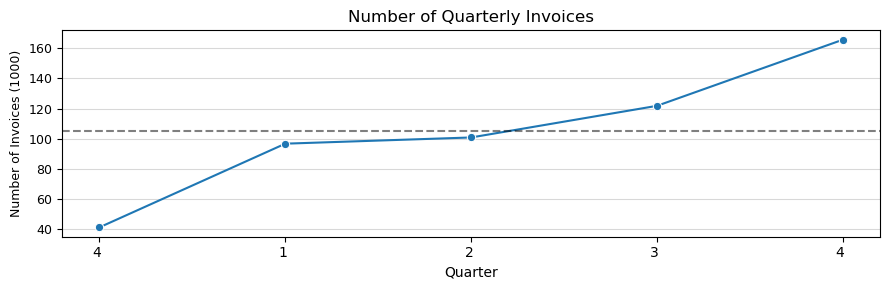

In [28]:
#Get idea of number of invoices per quarter
num_inv_Q = dates_W_M_Q.groupby(['Year','Quarter']).InvoiceDate.size().reset_index().rename(
    columns={'InvoiceDate':'# Invoices'})
#display(num_inv_Q)

#Have to specify the year for each quarter
for i in num_inv_Q.index:
    if num_inv_Q.loc[i,'Year'] == 2010:
        num_inv_Q.loc[i,'Quarter'] = "{} (2010)".format(num_inv_Q.loc[i,'Quarter'])
    else:
        num_inv_Q.loc[i,'Quarter'] = "{} (2011)".format(num_inv_Q.loc[i,'Quarter'])

fig = plt.figure(figsize=(9,3))
#Plot # invoices per quarter
ax1 = sns.lineplot(data=num_inv_Q, x='Quarter', y=num_inv_Q['# Invoices']/1000, marker='o')
#plot avg # quarterly invoices
ax1.axhline(y=num_inv_Q['# Invoices'].mean()/1000, linestyle='--', alpha=0.5, color='black')

plt.title('Number of Quarterly Invoices', fontsize=12)
ax1.set_xticklabels(labels=num_inv_Q.Quarter.str[:2])
plt.yticks(fontsize=9)
plt.ylabel('Number of Invoices (1000)', fontsize=9)
plt.grid(axis='y',alpha=0.3,color='gray')
plt.tight_layout();


The plot above displays the number of invoices the company received per quarter. The horizontal, dashed, black line indicates the average number of quarterly invoices. Recall the time intervals that these quarters span.
- Dec. 1, 2010 - Dec. 23, 2010,
- Jan. 1, 2011 - March 31, 2011,
- April 1, 2011 - June 30, 2011,
- July 1, 2011 - Sept. 30, 2011,
- Oct. 2, 2011 - Dec. 9, 2023.

In the middle three quarters, the number of invoices was fairly average. In the first & last quarter, this number was far from the average. Over the five quarters, the number of invoices increased in each. This could perhaps indicate a rise in popularity, affordability, or some other factor regarding this company & its customers. Note that the first quarter, quarter four in 2010, accounts for a much less time span than either of the four quarters in 2011. As such, this data point could potentially be an outlier. 
The least number of invoices was in quarter four in 2010. The most invoices processed was in quarter four in 2011.

In [29]:
#Calculate profits per quarter including aggregate statistics. 
    #Separate data by year to differentiate between the Dec 2010 & Dec 2011 data.

#get 2010 data
profits_Q_10 = profit_data[profit_data.InvoiceDate.dt.year == 2010].groupby(profit_data.InvoiceDate.dt.quarter).agg(
    {'Profit (£)':['mean','sum']}).reset_index()

#get rid of MultiIndex, rename columns, convert 'Quarter' to integers to remove ".0" part
profits_Q_10 = pd.DataFrame(np.squeeze(profits_Q_10.values).T, [x[0] for x in profits_Q_10.columns]).T
profits_Q_10.columns = ['Quarter','Avg Profit (£)','Total Profit (£)']
profits_Q_10['Quarter'] = profits_Q_10.Quarter.astype('int')

#Want to specify the year for each quarter
for i in profits_Q_10.index:
    profits_Q_10.loc[i,'Quarter'] = "{} (2010)".format(profits_Q_10.loc[i,'Quarter'])

#display(profits_Q_10)

#get 2011 data
profits_Q_11 = profit_data[profit_data.InvoiceDate.dt.year == 2011].groupby(profit_data.InvoiceDate.dt.quarter).agg(
    {'Profit (£)':['mean','sum']}).reset_index()

#get rid of MultiIndex, rename columns, convert 'Quarter' to integers to remove ".0" part
profits_Q_11 = pd.DataFrame(np.squeeze(profits_Q_11.values).T, [x[0] for x in profits_Q_11.columns]).T
profits_Q_11.columns = ['Quarter','Avg Profit (£)','Total Profit (£)']
profits_Q_11['Quarter'] = profits_Q_11.Quarter.astype('int')

#Want to specify the year for each quarter
for i in profits_Q_11.index:
    profits_Q_11.loc[i,'Quarter'] = "{} (2011)".format(profits_Q_11.loc[i,'Quarter'])

#display(profits_Q_11)

#Merge 2010, 2011 data together
profits_Q = pd.concat([profits_Q_10, profits_Q_11])
#convert profit columns from objects to floats
profits_Q[['Avg Profit (£)','Total Profit (£)']] = profits_Q[['Avg Profit (£)','Total Profit (£)']].astype('float')
#get 'Total Profit' cumulatively
profits_Q['Cumulative Profit (£)'] = profits_Q['Total Profit (£)'].cumsum()
#round the profit columns to 2 decimals
profits_Q[['Avg Profit (£)','Total Profit (£)','Cumulative Profit (£)']] = np.round(profits_Q[['Avg Profit (£)','Total Profit (£)','Cumulative Profit (£)']], 2)

display(profits_Q)


,Quarter,Avg Profit (£),Total Profit (£),Cumulative Profit (£)
0,4 (2010),19.94,821452.73,821452.73
0,1 (2011),19.95,1928572.43,2750025.16
1,2 (2011),20.51,2066812.11,4816837.27
2,3 (2011),20.61,2510228.57,7327065.84
3,4 (2011),19.88,3292920.84,10619986.68


In [30]:
#Want to get some aggregate statistics on a quarterly basis
display("Average Quarterly Profits per Invoice: £ {}".format(np.round(profits_Q['Avg Profit (£)'].mean(), 3)))
display("Average Total Quarterly Profits: £ {}".format(np.round(profits_Q['Total Profit (£)'].mean(), 3)))
display("Total Profit: £ {}".format(profit_data['Profit (£)'].sum()))


'Average Quarterly Profits per Invoice: £ 20.178'

'Average Total Quarterly Profits: £ 2123997.336'

'Total Profit: £ 10619986.684'

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\640633859.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[v[0]].set_xticklabels(labels=profits_Q.Quarter.str[:2])
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\640633859.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


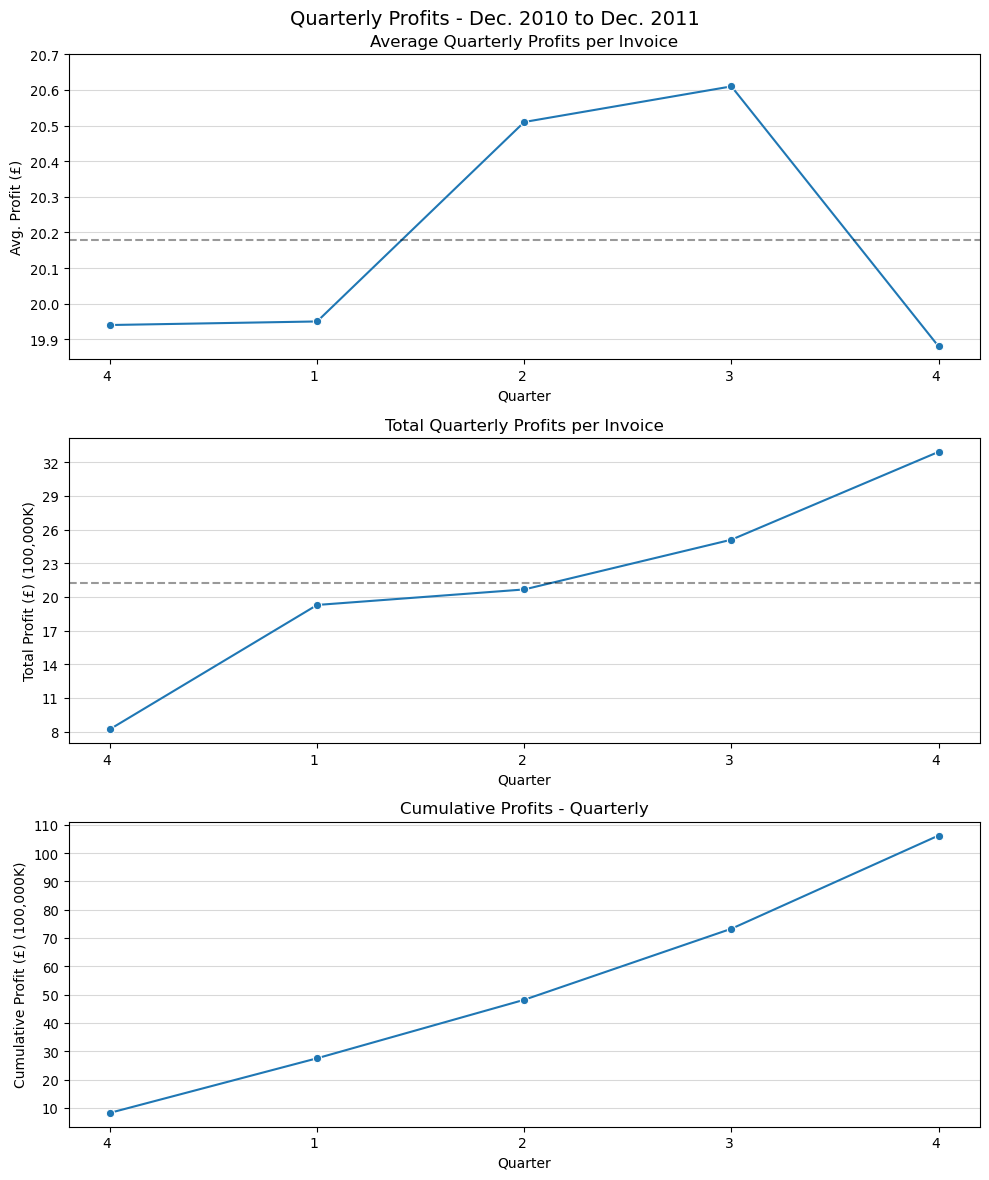

In [31]:
#Plot the quarterly profits chronologically
fig, axes = plt.subplots(nrows=3, figsize=(10,12))
#QUARTERLY AVERAGE
ax1 = sns.lineplot(data=profits_Q, x='Quarter', y='Avg Profit (£)', marker='o', ax=axes[0])
#add average quarterly avg
ax1.axhline(y=np.round(profits_Q[['Avg Profit (£)','Total Profit (£)']].mean(), 3)[0], linestyle='--',alpha=0.4,color='black')
#QUARTERLY TOTAL
ax2 = sns.lineplot(data=profits_Q, x='Quarter', y=profits_Q['Total Profit (£)']/100000, marker='o', ax=axes[1])
#add average quarterly total
ax2.axhline(y=np.round(profits_Q[['Avg Profit (£)','Total Profit (£)']].mean(), 3)[1]/100000, linestyle='--',alpha=0.4,color='black')
#CUMULATIVE TOTAL
ax3 = sns.lineplot(data=profits_Q, x='Quarter', y=profits_Q['Cumulative Profit (£)']/100000, marker='o', ax=axes[2])

fig.suptitle('Quarterly Profits - Dec. 2010 to Dec. 2011', fontsize=14)
#edit plot details
for key, v in {'Average Quarterly Profits per Invoice':[0, 19.9,20.7,0.1, 'Avg. Profit (£)'],
              'Total Quarterly Profits per Invoice':[1, 8,33,3, 'Total Profit (£) (100,000K)'],
              'Cumulative Profits - Quarterly':[2, 10,111,10, 'Cumulative Profit (£) (100,000K)']}.items():
    plt.sca(axes[v[0]])
    plt.title(key)
    axes[v[0]].set_xticklabels(labels=profits_Q.Quarter.str[:2])
    plt.yticks(ticks=np.arange(v[1],v[2],v[3]), fontsize=9.5)
    plt.ylabel(v[4])
    plt.grid(axis='y',alpha=0.3,color='gray')
    plt.tight_layout();


The three plots above display a few statistics regarding profits from invoices the company made on a quarterly basis. These four quarters span the following intervals. Note that these do not span equal lengths of time.
- Dec. 1, 2010 - Dec. 23, 2010,
- Jan. 1, 2011 - March 31, 2011,
- April 1, 2011 - June 30, 2011,
- July 1, 2011 - Sept. 30, 2011,
- Oct. 2, 2011 - Dec. 9, 2023.

In the plots, these data points are displayed chronologically over time.

The first plot, titled "Average Quarterl Profits per Invoice," calculates the average profit made from invoices across each quarter. For instances, in the first quarter of the data, the average profit made from the associated invoices was just under £20. The horizontal, dashed, black line indicates the average quarterly profit of all these quarterly values--about £20.2. 
The average profit per invoice in the first quarter was about £0.2 less than the quarterly average profit per invoice over the whole dataset. Moreover, this value in the final quarter was about £0.3 less than this quarterly average profit per invoice. 
Across the five quarters, the average profit per invoice was above average in two of them (40%), both of which occurred towards the middle of 2011. 
Generally, the difference between the average quarterly profit per invoice & the total quarterly average increased as time went on. 
The largest quarterly profit per invoice was in the third quarter of 2011 (about £20.6). The smallest quarterly profit per invoice was in the following quarter--the fourth quarter in 2011 (about £19.9).

The second plot, titled "Total Quarterly Profits per Invoice," summed & illustrated the total profits made from invoices across each quarter. For instances, in the first quarter of the data, the total profit made from the associated invoices was about £820,000. The horizontal, dashed, black line indicates the average total profit of all these quarterly values--about £2.1 million. Note that the vertical axis of this plot is in increments of £100,000. 
The total quarterly profit in the first quarter was less than 40% of the average quarterly profit over the whole dataset. On the other hand, this value in the final quarer was about 155% greater than this quarterly average profit. 
Across the five quarters, the total quarterly profit was above average only in the last two quarters (40%). 
The largest total quarterly profit was in the final quarter (about £3.3 million). The smallest total quarterly profit was in the first quarter (about £820,000).

The third plot, titled "Cumulative Profits per Week," cumulatively summed the quarerly values from the second plot. The total profit increased fairly consistenly across most quarters. By the end of the dataset, the company made about £10.6 million in profits. Note that the vertical axis of this plot is in increments of £100,000. 
The largest jump in total profit from quarter to quarter occurred between the first two quarters in the dataset--quarter four in 2010 & quarter one in 2011. This increment in cumulative profit was about +£1.1 million. Note that the span of time covered in the first quarter (in 2010) was significantly smaller than that of the other four quarters (in 2011). Therefore, the less time would imply that the company had less opportunities for more transactions than the other four quarters, which could explain why so much less profit was made in this first quarter relative to the other four. As such, this maximum quartly increment in cumulative profit could be a result of this detail.

## Analysis II - Conclusions
This section explored the profits made by the company over various intervals of time, including a weekly, monthly, & quarterly basis. The dataset spanned invoices from Dec. 1, 2010 to Dec. 9, 2011, which corresponds to 53 weeks, 13 months, & five quarters. As such, these distinct time periods did not all span equal periods of time; however, they all still accounted for enough invoices such that their data points were sufficiently representative.

Generally, there was a considerable number of invoices in the first month of the dataset (Dec. 2010), but this value decreased considerably until about September, 2011, from which point the number of invoices increased substantially. Given how the company's profit generally increased later on in the dataset, this could suggest that whatever business decisions were made at the end of the UK summer (~ late August into September) were very beneficial. Perhaps the company made their products cheaper, found ways to access more customers & improve their exposure, or made their website more accessible. Nonetheless, their popularity & sales clearly & significantly improved in the last third of the time period in which the dataset spanned.

On a **weekly** basis, the company received the most invoices & amassed the most profits at the end of the time span which the dataset spanned (week 49 -- early December, 2011). The least profitable week was week 17 -- late April. 
On a **monthly** basis, the company made the most profit was made in November, 2011--the last complete month in the dataset. The let profitable month was February, 2011. 
On a **quarterly** basis, the company saw increasing profit earnings quarter by quarter. The most profitable quarter--quarter four in 2011--which spanned from October 2, 2011 through December 9, 2011, raised the company's total profit earning to approximately £10.6 million.


With the parameters in this dataset, this prompt could be explored further in some other aspects. For example, the 'Country' parameter could be used to analyze how customers for different countries contributed to the company's profit earnings across the three time intervals used previously. Of course, since the company is based in the United Kingdom, they are very likely to have made sales from customers in the UK, but such analysis could help point the company to other countries & peoples & how attracted they are to their products. Such insights could help provide the company with information that could help drive future business decisions regarding how they sell & advertise their products. If such analysis were to reveal that their profits are increasing & decreasing for customers in different countries, it could encourage the company to experiment with different tactics as to how they sell & advertise themselves to these customers.

# Analysis III
🔎 **Analyze**: Are order sizes from countries outside the United Kingdom significantly larger than orders from inside the United Kingdom?

This prompt seeks to analyze the 'Quantity' parameter with respect to certain values of the 'Country' parameter. By calculating the average 'Quantity'--number of items per item per transaction ('InvoiceNo')--for customers from the United Kingdom & for customers from other countries, the average number of items purchased by customers from the UK & other countries can be compared. This can be done for every other country aside from the UK as a whole, & it can be done for each country aside from the UK. 
Since the company is based in the UK, most of the orders in the dataset likely have the value "United Kingdom" for the 'Country' parameter, & so some countries may not have a sufficient number of data points to form representative conclusions from. It could be useful to check how many invoices & total items there are in the dataset with respect to each unique 'Country.'

Furthermore, this analysis could be done over certain intervals of time, such as monthly &/or quarterly, as seen in **Analysis II**. For instance, on a monthly basis, a useful metric would be to determine what percentage of the total 'Quantity' was accounted for in orders from customers per 'Country.' 
Such analysis could reveal the most popular times in which customers from certain countries placed orders from this company, which could help provide insights as to how successful any advertising & promotional techniques implemented by the company were (or were not) at specific times.

Obviously, this analysis should exclude transactions pertaining to returns--a negative 'Quantity' value.

### Analysis without respect to time
Firstly, the data was evaluated over the entire course of the dataset. 
This section evaluates the dataset using two approaches:
1) The order size of all data points per country, &
2) The order size of unique invoices per country.

Approach 1) simply compiles all data points per 'Country' & calculates aggregate statistics over all of them. For example, the average 'Quantity' (order size) for 'Country' X was determined by dividing the total 'Quantity' across all invoices for said country by the total number of (non-unique) invoices (or data points) for said country. Since each 'InvoiceNo' doesn't necessarily correspond to a single unique order, this average doesn't necessarily calculate the average order size of each individual item purchased per invoice depending on if multiple items were purchased for an 'InvoiceNo.' Instead, this value provides a more generic average order size per country.

Approach 2) goes a bit further in calculating these statistics in that it groups the data both by 'Country' & 'InvoiceNo.' Therefore, this method finds more specific averages of 'Quantity' per 'InvoiceNo' per 'Country' than approach 1) does. 
For the purposes of this analysis, approach 2) is more ideal & representative than approach 1), but both were explored in this initial section.

##### Approach 1)

In [32]:
#Get some data per 'Country': total (& unique) invoices, total/min/max 'Quantity,' avg 'Quantity' per invoice, earliest & latest 'InvoiceDate', ...
    # # unique 'CustomerID'

anIII_country_stats = profit_data.groupby('Country').agg({'InvoiceNo':['count','nunique'], 'Quantity':['sum','min','max'], 'InvoiceDate':['min','max'], 
                                           'CustomerID':'nunique'}).reset_index()

#get rid of MultiIndex, rename columns
anIII_country_stats = pd.DataFrame(np.squeeze(anIII_country_stats.values).T, [x[0] for x in anIII_country_stats.columns]).T
anIII_country_stats.columns = ['Country','# Total Invoices','# Unique Invoices','Total Quantity','Min Quantity','Max Quantity',
                               'Earliest Invoice','Latest Invoice','# Unique Customers']

#calculate avg 'Quantity' per invoice per 'Country' -- round down to nearest integer bc cannot have part of an item
for i in anIII_country_stats.index:
    anIII_country_stats.loc[i,'Avg Quantity per Invoice'] = math.floor((anIII_country_stats.loc[i,'Total Quantity'] / anIII_country_stats.loc[i,'# Total Invoices']))

#reorganize columns, change data type of 'Avg Quantity per Invoice' to integer
anIII_country_stats = anIII_country_stats[['Country','# Total Invoices','# Unique Invoices','Total Quantity','Min Quantity',
                        'Max Quantity','Avg Quantity per Invoice','Earliest Invoice','Latest Invoice','# Unique Customers']]
anIII_country_stats['Avg Quantity per Invoice'] = anIII_country_stats['Avg Quantity per Invoice'].astype('int')

display(anIII_country_stats)
#display(anIII_country_stats['# Unique Invoices'].sum())


,Country,# Total Invoices,# Unique Invoices,Total Quantity,Min Quantity,Max Quantity,Avg Quantity per Invoice,Earliest Invoice,Latest Invoice,# Unique Customers
0,Australia,1184,57,84199,1,1152,71,2010-12-01 10:03:00,2011-11-24 12:30:00,9
1,Austria,398,17,4881,1,288,12,2010-12-17 09:38:00,2011-12-08 10:26:00,11
2,Bahrain,18,3,314,2,96,17,2010-12-20 11:02:00,2011-05-19 17:47:00,2
3,Belgium,2031,98,23237,1,272,11,2010-12-03 16:35:00,2011-12-09 10:10:00,25
4,Brazil,32,1,356,2,24,11,2011-04-15 10:25:00,2011-04-15 10:25:00,1
5,Canada,151,6,2763,1,504,18,2011-03-14 13:53:00,2011-08-25 11:27:00,4
6,Channel Islands,747,26,9485,1,407,12,2010-12-09 11:48:00,2011-12-05 10:19:00,9
7,Cyprus,603,16,6340,1,288,10,2010-12-14 12:58:00,2011-11-18 12:07:00,8
8,Czech Republic,25,2,671,1,72,26,2011-02-28 08:43:00,2011-10-07 10:37:00,1
9,Denmark,380,18,8235,1,256,21,2010-12-09 12:05:00,2011-12-05 16:48:00,9


The dataset set above contains several statistics regarding invoices per 'Country.' Note that the column '# Total Invoices,' counts each occurrence of every 'InvoiceNo,' whereas the column '# Unique Invoices' only counts the number of unique 'InvoiceNo's. In incorporating the 'Avg Quantity per Invoice' column, this measures the average number of items purchased by customers across every 'InvoiceNo' data point & not across each unique 'InvoiceNo.'

The most popular country, the United Kingdom, accounts for about 481,000 total invoices (data points), which is more than 90% of all invoices pertaining to orders. The next three most popular countries, Germany, France, & EIRE (most probably Ireland), have 9,027, 8,393, & 7,883 total invoices respectively. No other country had more than 2,500 total invoices. Of the 38 different 'Country' values, some of which don't indicate a specific country, nine of them have less than 100 total invoices each; six had less than 50. If the data corresponding to orders of customers from the United Kingdom were ignored, which accounts for about 45,000 data points, a representative number of total invoices (data points) would ideally be around 300.

Regarding unique invoices, only the four aformentioned countries have more than 100 invoices. 16 countries had less than 10 such invoices, 12 of which had five invoices or less. 
The diversity in the number of data points per country, as described previously, raises the concern of some countries having less-than-representative data points, or outliers, for this analysis. If the data corresponding to orders of customers from the UK were ignored, which accounts for 1,942 data points, a representative number of unique invoices would ideally be around 20. For now, no data points need to be dropped from this dataset.

'Averages with UK:'

Avg Quantity per Invoice       20.131579
# Total Invoices            13843.526316
# Unique Invoices             545.473684
dtype: object

,Country,# Total Invoices,# Unique Invoices,Total Quantity,Min Quantity,Max Quantity,Avg Quantity per Invoice,Earliest Invoice,Latest Invoice,# Unique Customers
0,Netherlands,2363,95,200937,1,2400,85,2010-12-01 11:27:00,2011-12-08 12:12:00,9
1,Japan,321,19,26016,1,2040,81,2010-12-05 15:46:00,2011-11-29 15:52:00,8
2,Sweden,450,36,36078,1,768,80,2010-12-14 13:28:00,2011-12-05 16:26:00,8
3,Australia,1184,57,84199,1,1152,71,2010-12-01 10:03:00,2011-11-24 12:30:00,9
4,Czech Republic,25,2,671,1,72,26,2011-02-28 08:43:00,2011-10-07 10:37:00,1
5,Singapore,222,7,5241,1,288,23,2011-01-25 13:26:00,2011-10-19 11:18:00,1
6,Denmark,380,18,8235,1,256,21,2010-12-09 12:05:00,2011-12-05 16:48:00,9
7,Canada,151,6,2763,1,504,18,2011-03-14 13:53:00,2011-08-25 11:27:00,4
8,Lithuania,35,4,652,6,48,18,2010-12-05 12:00:00,2010-12-08 14:43:00,1
9,EIRE,7883,288,147281,1,1440,18,2010-12-01 14:05:00,2011-12-08 15:54:00,3


'Averages without UK:'

Avg Quantity per Invoice      20.432432
# Total Invoices            1213.810811
# Unique Invoices             52.486486
dtype: object

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\2989704349.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


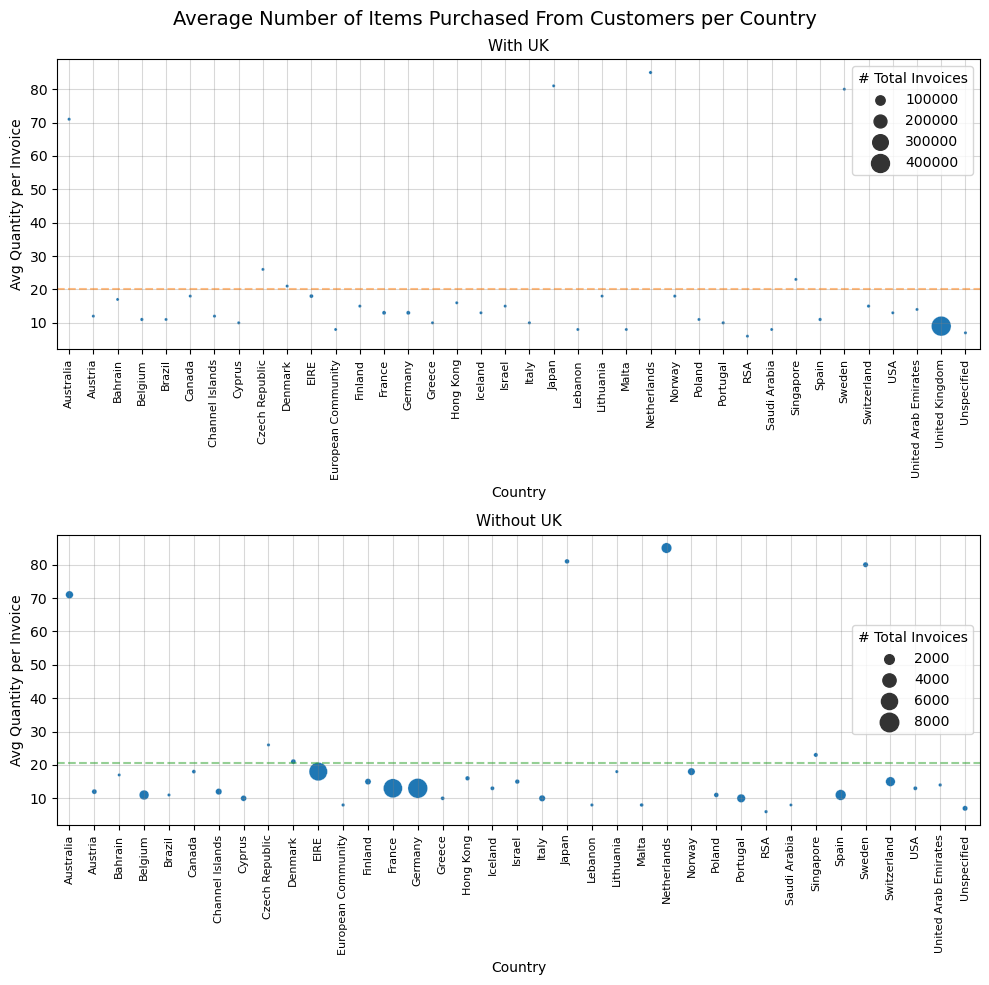

In [33]:
#Make a plot indicating 'Avg Quantity per Invoice' per country w/respect to '# Total Invoices'; 
    #make separate plot with/without UK bc it distorts the other data points so much.

#WITH UNITED KINGDOM:
#include some relevant statistics & data points
display('Averages with UK:')
display(anIII_country_stats[['Avg Quantity per Invoice','# Total Invoices','# Unique Invoices']].mean())
display(anIII_country_stats.sort_values('Avg Quantity per Invoice',ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(nrows=2, figsize=(10,10))
ax1 = sns.scatterplot(data=anIII_country_stats, x='Country', y='Avg Quantity per Invoice', size='# Total Invoices', 
                      sizes=(5,200), ax=axes[0])
#add mean of the vertical axis INCLUDING UK
ax1.axhline(y=anIII_country_stats['Avg Quantity per Invoice'].mean(), linestyle='--',alpha=0.5,color=sns.color_palette()[1])

#WITHOUT UNITED KINGDOM:
display('Averages without UK:')
display(anIII_country_stats[anIII_country_stats.Country != 'United Kingdom'][['Avg Quantity per Invoice','# Total Invoices','# Unique Invoices']].mean())

ax2 = sns.scatterplot(data=anIII_country_stats[anIII_country_stats.Country != 'United Kingdom'], 
                      x='Country', y='Avg Quantity per Invoice', size='# Total Invoices', sizes=(5,200), ax=axes[1])
#add mean of the vertical axis EXCLUDING UK
ax2.axhline(y=anIII_country_stats[anIII_country_stats.Country != 'United Kingdom']['Avg Quantity per Invoice'].mean(), 
           linestyle='--',alpha=0.5,color=sns.color_palette()[2])

#edit plot details
fig.suptitle('Average Number of Items Purchased From Customers per Country', fontsize=14)
for key, v in {'With UK':[0, 0.4], 'Without UK':[1, 1.4]}.items():
    plt.sca(axes[v[0]])
    plt.title(key, fontsize=11)
    axes[v[0]].set(xlim=(-0.5, len(anIII_country_stats.Country)-v[1]))
    plt.xticks(fontsize=8, rotation=90)
    plt.grid(axis='both',alpha=0.3,color='gray')
    plt.tight_layout();

The figures above illustrate the average number of items (a.k.a. order size) per product that are ordered by customers from different countries. The first plot includes the United Kingdom (UK) & the second does not. The horizontal, dashed lines indicate the mean values of the vertical axis--average order size--with & without the UK (the UK being included brings this average down just slightly). The size of the data points on these plots indicate the number of total invoices--the number of total occurrences of each 'InvoiceNo'--that each country amassed. Effectively, the larger the point, the more orders that customers from a country have ordered, & therefore the more representative the country's data is.

Note that two plots were made because the UK accounted for such a significant majority of the dataset that it makes the rest of the data points essentially illegible, as seen in the first plot. The UK' 'Avg Quantity per Invoice' values is about nine, making it the seventh smallest value of the 38 'Country's. 
Additionally, it should be the noted that the values of the parameter plotted along the vertical axis were rounded down to integers.

Only four countries have an average quantity-per-invoice of more than 26 items--the Netherlands, Japan, Sweden, & Australia. Two of these countries are in a different continent than where the company is based (Europe). The average order size of customers from these countries is significantly greater than the average order size across all countries. In regards to the number of invoices these countries accounted for, the Netherlands & Australia both exceed the average '# Total Invoices' & '# Unique Invoices' (excluding the UK), so their data points are definitely representative. Regarding Sweden & Japan, they lie in the middle third of the 37 countries (excluding UK) when it comes to both the '# Total Invoices' & '# Unique Invoices' values. As such, their data points, though not the most abundant, are still sufficiently representative.

Aside from these four countries, Denmark is the only other country with an above average mean order size (~ 21) & a sufficient number of invoices (380 total, 18 unique). Of the countries with the most invoices--Germany, France, EIRE--only EIRE has a relatively large average order size, but it is slightly below the average across all countries (excluding the UK).

As mentioned previously, the UK has seventh smallest average order size per item per invoice, which indicates that customers from the UK usually order products in bulk much less often than customers from other countries. Customers from the Netherlands, Japan, Sweden, & Australia order products in much greater bulk than any other country. 
Moving forward, similar analyses could be done for unique invoices instead of each distinct data point.

##### Approach 2)

In [34]:
#Do similar calculations but for each unique 'InvoiceNo' instead of all invoices per 'Country'
anIII_country_uniq_inv_stats = profit_data.groupby(['Country','InvoiceNo']).agg({'InvoiceNo':'count', 
                'Quantity':['sum','min','max','mean']}).rename(columns={'InvoiceNo':'# Products'}).reset_index().dropna()

#get rid of MultiIndex, rename columns, round some columns/convert to int's
anIII_country_uniq_inv_stats = pd.DataFrame(np.squeeze(anIII_country_uniq_inv_stats.values).T, [x[0] for x in anIII_country_uniq_inv_stats.columns]).T
anIII_country_uniq_inv_stats.columns = ['Country','InvoiceNo','# Products','Total Quantity','Min Quantity','Max Quantity','Mean Quantity']
anIII_country_uniq_inv_stats[['Min Quantity','Max Quantity','Mean Quantity']] = anIII_country_uniq_inv_stats[['Min Quantity','Max Quantity','Mean Quantity']].astype('int')

display(anIII_country_uniq_inv_stats)

,Country,InvoiceNo,# Products,Total Quantity,Min Quantity,Max Quantity,Mean Quantity
0,Australia,536389,14,107,2,24,7
1,Australia,537676,8,214,4,120,26
2,Australia,539419,9,136,4,50,15
3,Australia,540267,46,4662,6,576,101
4,Australia,540280,2,140,60,80,70
...,...,...,...,...,...,...,...
20723,Unspecified,563947,7,126,6,36,18
20724,Unspecified,564051,16,59,1,12,3
20725,Unspecified,565303,65,257,1,48,3
20726,Unspecified,576646,19,188,4,24,9


In [35]:
#Use this data to get aggregate stats per 'Country'
condensed_anIII_country_uniq_inv_stats = anIII_country_uniq_inv_stats.groupby('Country').agg({'# Products':['sum','mean'], 
                    'Total Quantity':['sum','mean'], 'Mean Quantity':'mean'}).reset_index()

#get rid of MultiIndex, rename columns, round some columns/convert to int's
condensed_anIII_country_uniq_inv_stats = pd.DataFrame(np.squeeze(condensed_anIII_country_uniq_inv_stats.values).T, [x[0] for x in condensed_anIII_country_uniq_inv_stats.columns]).T
condensed_anIII_country_uniq_inv_stats.columns = ['Country','Total # Products','Mean # Products per Invoice', 'Total Quantity',
                                                 'Mean Total Quantity per Invoice', 'Mean Quantity per Invoice']
condensed_anIII_country_uniq_inv_stats[['Mean # Products per Invoice','Mean Total Quantity per Invoice','Mean Quantity per Invoice']] = condensed_anIII_country_uniq_inv_stats[['Mean # Products per Invoice','Mean Total Quantity per Invoice','Mean Quantity per Invoice']].astype('int')

display(condensed_anIII_country_uniq_inv_stats)


,Country,Total # Products,Mean # Products per Invoice,Total Quantity,Mean Total Quantity per Invoice,Mean Quantity per Invoice
0,Australia,1184,20,84199,1477,61
1,Austria,398,23,4881,287,14
2,Bahrain,18,6,314,104,25
3,Belgium,2031,20,23237,237,11
4,Brazil,32,32,356,356,11
5,Canada,151,25,2763,460,92
6,Channel Islands,747,28,9485,364,22
7,Cyprus,603,37,6340,396,12
8,Czech Republic,25,12,671,335,27
9,Denmark,380,21,8235,457,25


,index,Country,Total # Products,Mean # Products per Invoice,Total Quantity,Mean Total Quantity per Invoice,Mean Quantity per Invoice
0,20,Japan,321,16,26016,1369,305
1,24,Netherlands,2363,24,200937,2115,123
2,5,Canada,151,25,2763,460,92
3,32,Sweden,450,12,36078,1002,72
4,0,Australia,1184,20,84199,1477,61
5,36,United Kingdom,481143,25,4718329,251,36
6,8,Czech Republic,25,12,671,335,27
7,2,Bahrain,18,6,314,104,25
8,9,Denmark,380,21,8235,457,25
9,10,EIRE,7883,27,147281,511,23


'With UK:'

Total # Products                   13843.526316
Mean # Products per Invoice           24.526316
Mean Total Quantity per Invoice      457.473684
Mean Quantity per Invoice             29.868421
dtype: object

'Wthout UK:'

Total # Products                   1213.810811
Mean # Products per Invoice          24.513514
Mean Total Quantity per Invoice     463.054054
Mean Quantity per Invoice            29.702703
dtype: object

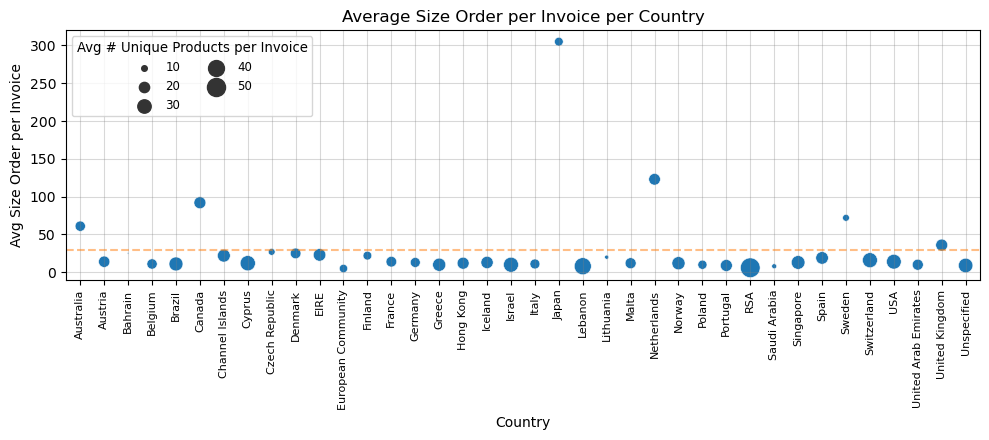

In [36]:
#Plot the data for each unique invoice instead of all invoices per country

#include some aggregate stats
display(condensed_anIII_country_uniq_inv_stats.sort_values('Mean Quantity per Invoice',ascending=False).reset_index())
display("With UK:")
display(condensed_anIII_country_uniq_inv_stats[['Total # Products','Mean # Products per Invoice','Mean Total Quantity per Invoice',
                                                'Mean Quantity per Invoice']].mean())
#WITHOUT UK
display("Wthout UK:")
display(condensed_anIII_country_uniq_inv_stats[condensed_anIII_country_uniq_inv_stats.Country != 'United Kingdom'][['Total # Products',
                'Mean # Products per Invoice','Mean Total Quantity per Invoice','Mean Quantity per Invoice']].mean())

fig = plt.figure(figsize=(10,4.5))
ax1 = sns.scatterplot(data=condensed_anIII_country_uniq_inv_stats, x='Country',y='Mean Quantity per Invoice', 
                     size='Mean # Products per Invoice', sizes=(1,200))
#denote average 'Mean Quantity' across all countries
ax1.axhline(y=condensed_anIII_country_uniq_inv_stats['Mean Quantity per Invoice'].mean(), linestyle='--', 
            color=sns.color_palette()[1], alpha=0.5)

#edit plot details
plt.title('Average Size Order per Invoice per Country', fontsize=12)
ax1.set(xlim=(-0.6, len(condensed_anIII_country_uniq_inv_stats.Country)-0.4))
plt.xticks(fontsize=8, rotation=90)
plt.ylabel('Avg Size Order per Invoice')
plt.legend(loc='upper left',ncols=2, title='Avg # Unique Products per Invoice', title_fontsize=9.5, fontsize=8.5)
plt.grid(axis='both',alpha=0.3,color='gray')
plt.tight_layout();


The figure above illustrates the average size order per invoice across the 38 different 'Country's. This average size order was calculated over a few steps:
1) Each unique 'InvoiceNo' & 'Country' were grouped together. With these pairs, the average of all of their 'Quantity' values was calculated, effectively finding the average 'Quantity' per invoice per country. Recall that the 'Quantity' parameter describes the number of items ordered per product for a certain invoice. An invoice can have multiple data points, which usually indicates the purchase of multiple different products in said invoice.
2) Using these average quantities, or size orders, the mean value was then found for each country. These values are displayed in the plot above.

Additionally, the horizontal, dashed line indicates the average size order per invoice across every 'Country' (~ 30). The size of each data point describes the average number of different products per invoice per country. The bigger the dot, the more unique products that were purchased in an invoice.

For starters, only six of the 38 countries have an above average mean size order per invoice--Japan, the Netherlands, Canada, Sweden, Australia, & the United Kingdom, three of which are in a different continent than where the company is based. Recall that four of these countries were amongst the most popular countries in the previous plots, which analyzed all invoices (data points) per country. On the other hand, the two other countries, Canada & the UK, had much smaller values in those plots & data. 
Moreover, the average number of unique products purchased per invoice for these countries was at or slightly below average across all the 38 'Country's. The only country of these six with a relatively small number of total products purchased (or invoices) was Canada, but they still only had the 12th fewest value of all the countries. Suffice to say that the data points of these six countries are considerably representative.

In this data, only five other countries had a greater average size order per invoice than the United Kingdom. Japan significantly outpaced every other country in this category, but the UK was closer to the following countries than the five ahead of them; however, the UK still saw a greater value than 22 other 'Country's. As such, when it comes to a country's average size order per unique invoice, customers based in the UK order in greater quantities than customers from most other countries.

#### Recap Findings of Analyses So Far
So far, this section has analyzed the data in two facets:
1) The order size of all data points per country, &
2) The order size of unique invoices per country.

The difference in these two lies in the fact that a single invoice can account for multiple purchases. For example, 'InvoiceNo' 123 may involve an order of 12 towels, 2 candles, 2,000 dog treats, etc. Approach 1) analyzed the 'Quantity' parameter per 'Country' for all associated 'InvoiceNo's, whereas the approach 2) analyzed 'Quantity' by 'InvoiceNo' & 'Country' to get a closer look at each 'Country' on an invoice-by-invoice basis. For some countries, the results were similar (i.e. the Netherlands, Japan, Sweden, Australia), but for others, they differed quite considerably (i.e. United Kingdom, Canada).

Given that the company in which the dataset is from is based in the United Kingdom, a main objective was to determine if customers outside of the UK bought items in greater quantities than customers in the UK. Overall, both approaches found that most countries have a relatively small average order size. There were only a handful of countries that had a value which was above average in these categories, as outlined for each approach.

In the first approach, as listed above, four countries had an average order size that was significantly greater than any other country--the Netherlands, Japan, Sweden, & Australia. The UK had the seventh smallest average order size of the 38 countries, which was about 11 less than the average value across all the other 37 countries.
The second approach saw one country significantly outpace all the others in terms of order size per invoice--Japan. As opposed to the first approach, however, the UK had the sixth largest average order size per invoice, which was about six greater than the average across the 38 countries. This difference is essentially the same when compared to the average value across the other 37 countries.

The main reason for this change for the UK may be because of how many total invoices & data points customers from there account for--more than 90%. Since the first approach measured average order size over all of a country's invoices, this calculation was done over all of the UK's invoices. For the second, these averages were first calculated by invoice then averaged out, so the denominator in the first approach for the UK was much greater than in the second approach. 
Ultimately, both approaches have valuable insights, but the the latter may be the most appropriate & representative approach. As such, it can be said that the order size per invoice of orders placed by customers in the UK is greater than that of most other countries, & is slightly above the average order size value across all countries. On the other hand, this value is significantly outpaced by a handful of other countries in other continents including Japan, the Netherlands, Sweden, Canada, & Australia. 

In the next parts of the analysis, which examine similar statisics & data but over time, will use the second approach.

### Analysis over time -- Quarterly
Initially, this process was performed on a monthly basis, but when it came to plotting the data, most countries did not have very much consistency in the number of invoices & order sizes that they had. Moreover, it was challenging to make comparable plots that were legible yet avoided splitting the data too much. As such, the data was only analyzed across quarters with the idea that the data & plots may be more consistent than the monthly data because there are (eight) less distinct quarters than there are distinct months.

Recall that there are five quarters worth of data, but they do not all span equal lengths of time. Most notably, the first quarter, quarter four in 2010, spans less than a month, whereas the following four quarters (in 2011) all span multiple months. As such, this quarter has less than half the number of invoices than the next least popular quarter (in terms of invoices). Specifically, the dates associated with each quarter are:
- Dec. 1, 2010 - Dec. 23, 2010,
- Jan. 1, 2011 - March 31, 2011,
- April 1, 2011 - June 30, 2011,
- July 1, 2011 - Sept. 30, 2011,
- Oct. 2, 2011 - Dec. 9, 2023.

As mentioned previously, this analysis will use a more representative approach (the previously described Approach 2)) when calculating order sizes per country. Specifically, statistics will first be calculated for each unique invoice per country, then more overarching, aggregate averages & other statistics will be calculated.

As opposed to before, this section will measure such statistics over certain time intervals, specifically a quarterly basis. To do so, the dataset (with only non-returns) will be grouped by 'Country,' quarter, & 'InvoiceNo.'

In [37]:
#Get statistics regarding 'Quantity' for each unique 'InvoiceNo' per 'Country' & quarter
    #REMEMBER, also need to differentiate between years bc there are Dec. 2010 & Dec. 2011 dates -- can do this by performing...
        # groupby() functions for 2010/2011 separately, then merge two years together after the fact

#2010:
#there are 61,902 possible combinations, only 1,629 have existing data points (drop null values)
anIII_Q_10 = profit_data[profit_data.InvoiceDate.dt.year == 2010].groupby(['Country',profit_data.InvoiceDate.dt.quarter,
                                                                          'InvoiceNo']).agg(
                {'InvoiceNo':'count', 'Quantity':['sum','min','max','mean']}).rename(
    columns={'InvoiceNo':'# Different Items'}).reset_index().dropna()
#add year column
anIII_Q_10['Year'] = [2010 for i in range(0,anIII_Q_10.shape[0],1)]

#get rid of MultiIndex, rename & reorganize columns
anIII_Q_10 = pd.DataFrame(np.squeeze(anIII_Q_10.values).T, [x[0] for x in anIII_Q_10.columns]).T
anIII_Q_10.columns = ['Country','Quarter','InvoiceNo','# Different Items','Total Quantity','Min Quantity','Max Quantity',
                     'Mean Quantity (Order Size)','Year']
anIII_Q_10 = anIII_Q_10[['Country','Year','Quarter','InvoiceNo','# Different Items','Total Quantity','Min Quantity','Max Quantity',
                     'Mean Quantity (Order Size)']]

display(anIII_Q_10)


,Country,Year,Quarter,InvoiceNo,# Different Items,Total Quantity,Min Quantity,Max Quantity,Mean Quantity (Order Size)
0,Australia,2010,4,536389,14,107,2.0,24.0,7.642857
1,Australia,2010,4,537676,8,214,4.0,120.0,26.75
2,Australia,2010,4,539419,9,136,4.0,50.0,15.111111
3,Austria,2010,4,539330,8,51,3.0,12.0,6.375
4,Bahrain,2010,4,539500,1,54,54.0,54.0,54.0
...,...,...,...,...,...,...,...,...,...
1624,United Kingdom,2010,4,539988,88,176,1.0,18.0,2.0
1625,United Kingdom,2010,4,539989,1,1,1.0,1.0,1.0
1626,United Kingdom,2010,4,539990,11,17,1.0,5.0,1.545455
1627,United Kingdom,2010,4,539991,13,18,1.0,4.0,1.384615


In [38]:
#2011: -- this cell takes a minute
#are 2,903,048 possible combinations, only 19,099 have existing data points
anIII_Q_11 = profit_data[profit_data.InvoiceDate.dt.year == 2011].groupby(['Country',profit_data.InvoiceDate.dt.quarter,
                                                                          'InvoiceNo']).agg(
                {'InvoiceNo':'count', 'Quantity':['sum','min','max','mean']}).rename(
    columns={'InvoiceNo':'# Different Items'}).reset_index().dropna()
#add year column
anIII_Q_11['Year'] = [2011 for i in range(0,anIII_Q_11.shape[0],1)]

#get rid of MultiIndex, rename & reorganize columns
anIII_Q_11 = pd.DataFrame(np.squeeze(anIII_Q_11.values).T, [x[0] for x in anIII_Q_11.columns]).T
anIII_Q_11.columns = ['Country','Quarter','InvoiceNo','# Different Items','Total Quantity','Min Quantity','Max Quantity',
                     'Mean Quantity (Order Size)','Year']
anIII_Q_11 = anIII_Q_11[['Country','Year','Quarter','InvoiceNo','# Different Items','Total Quantity','Min Quantity','Max Quantity',
                     'Mean Quantity (Order Size)']]

#display(anIII_Q_11)


In [39]:
#Merge the two years worth of data together, reset index -- 20,728 rows
anIII_Q_quan_stats = pd.concat([anIII_Q_10,anIII_Q_11]).reset_index(drop=True)
display(anIII_Q_quan_stats)


,Country,Year,Quarter,InvoiceNo,# Different Items,Total Quantity,Min Quantity,Max Quantity,Mean Quantity (Order Size)
0,Australia,2010,4,536389,14,107,2.0,24.0,7.642857
1,Australia,2010,4,537676,8,214,4.0,120.0,26.75
2,Australia,2010,4,539419,9,136,4.0,50.0,15.111111
3,Austria,2010,4,539330,8,51,3.0,12.0,6.375
4,Bahrain,2010,4,539500,1,54,54.0,54.0,54.0
...,...,...,...,...,...,...,...,...,...
20723,Unspecified,2011,3,563947,7,126,6.0,36.0,18.0
20724,Unspecified,2011,3,564051,16,59,1.0,12.0,3.6875
20725,Unspecified,2011,3,565303,65,257,1.0,48.0,3.953846
20726,Unspecified,2011,4,576646,19,188,4.0,24.0,9.894737


The dataset above, defined as the variable "anIII_Q_quan_stats," has 20,728 data points detailing some aggregate statistics per 'Country,' quarter, & 'InvoiceNo.' The column '# Different Items' quantifies how many unique products ('Description's/'StockCode's) were associated with each country-quarter-invoice combination. The column 'Total Quantity' indicates the total number of items ordered in the corresponding country-quarter-invoice combination. The columns 'Min Quantity' & 'Max Quantity' indicate the smallest & largest number of any specific item ordered in this country-quarter-invoice combination respectively. The 'Mean Quantity (Order Size)' column quantifies the average order size across all products for each country-quarter-invoice combination.

To make this data more plottable, aggregate statistics need to be obtained for each country & quarter (& year). This is done in the following cell, the main statistics of which are assigned to the variable "condensed_anIII_Q_quan_stats." 
Note that non-integer values (floats) in some columns were rounded down to the nearest integer because it is not possible for a customer to order part of an item. They were all rounded down for sake of consistency & because customers ordered at least this many items in their order but not more.

In [40]:
#Use this data to get aggregate stats per 'Country' & quarter (need to include year too)
condensed_anIII_Q_quan_stats = anIII_Q_quan_stats.groupby(['Country','Year','Quarter']).agg({
    '# Different Items':['sum','mean'], 'Total Quantity':['sum','mean'], 'Mean Quantity (Order Size)':['mean']}).reset_index()

#get rid of MultiIndex, rename columns, round some columns/convert to int's
condensed_anIII_Q_quan_stats = pd.DataFrame(np.squeeze(condensed_anIII_Q_quan_stats.values).T, [x[0] for x in condensed_anIII_Q_quan_stats.columns]).T
condensed_anIII_Q_quan_stats.columns = ['Country','Year','Quarter','Total # Items','Mean # Items','Total Quantity',
                                        'Mean Total Quantity (Order Size)', 'Mean Quantity (Order Size)']
condensed_anIII_Q_quan_stats[['Mean # Items','Mean Total Quantity (Order Size)','Mean Quantity (Order Size)']] = condensed_anIII_Q_quan_stats[['Mean # Items',
                    'Mean Total Quantity (Order Size)','Mean Quantity (Order Size)']].astype('int')

#need to merge year & quarter together into a new column to be able to plot correctly, otherwise, Q4 2010 & Q4 2011 will be together
for i in condensed_anIII_Q_quan_stats.index:
    condensed_anIII_Q_quan_stats.loc[i,'Quarter (Year)'] = "{} ({})".format(condensed_anIII_Q_quan_stats.loc[i,'Quarter'], 
                                                                         condensed_anIII_Q_quan_stats.loc[i,'Year'])

display(condensed_anIII_Q_quan_stats)

#Get some more aggregate statistics regarding avg quarterly order size per country to help determine how to split countries...
    #into multiple plots
display(condensed_anIII_Q_quan_stats.groupby('Country')['Mean Quantity (Order Size)'].describe().reset_index().sort_values(
    ['count','mean']).reset_index(drop=True))


,Country,Year,Quarter,Total # Items,Mean # Items,Total Quantity,Mean Total Quantity (Order Size),Mean Quantity (Order Size),Quarter (Year)
0,Australia,2010,4,31,10,457,152,16,4 (2010)
1,Australia,2011,1,324,19,24763,1456,37,1 (2011)
2,Australia,2011,2,304,30,25285,2528,60,2 (2011)
3,Australia,2011,3,368,21,21967,1292,62,3 (2011)
4,Australia,2011,4,157,15,11727,1172,119,4 (2011)
...,...,...,...,...,...,...,...,...,...
140,United Kingdom,2011,3,109739,25,1155055,264,28,3 (2011)
141,United Kingdom,2011,4,152284,28,1464889,277,44,4 (2011)
142,Unspecified,2011,2,83,20,1163,290,13,2 (2011)
143,Unspecified,2011,3,306,43,1491,213,7,3 (2011)


,Country,count,mean,std,min,25%,50%,75%,max
0,RSA,1.0,6.000000,NaN,6.0,6.00,6.0,6.00,6.0
1,Lebanon,1.0,8.000000,NaN,8.0,8.00,8.0,8.00,8.0
2,Saudi Arabia,1.0,8.000000,NaN,8.0,8.00,8.0,8.00,8.0
3,Brazil,1.0,11.000000,NaN,11.0,11.00,11.0,11.00,11.0
4,Lithuania,1.0,20.000000,NaN,20.0,20.00,20.0,20.00,20.0
5,European Community,2.0,7.500000,4.949747,4.0,5.75,7.5,9.25,11.0
6,USA,2.0,11.500000,7.778175,6.0,8.75,11.5,14.25,17.0
7,United Arab Emirates,2.0,11.500000,6.363961,7.0,9.25,11.5,13.75,16.0
8,Czech Republic,2.0,27.500000,6.363961,23.0,25.25,27.5,29.75,32.0
9,Bahrain,2.0,32.500000,30.405592,11.0,21.75,32.5,43.25,54.0


To help get a better idea of what these numbers mean, plots were made. With time now incorporated, they cannot be made in the same way as was done previously. Ideally, the data would be plotted over time with the horizontal axis denoting each quarter & the vertical axis would quantify the average order size per country. 
To differentiate between countries, the `hue` parameter could be used; however, with 38 unique 'Country' values, such a plot could get messy quickly. At the same time, if some average quarterly order size of some country is vastly greater than that of other countries, it could make the data of these other countries illegible. As such, an optimal approach would be to group subsets of countries together that have similar average order sizes so that they will not distort the plots of other countries.

Eight plots were constructed, & the general guidelines of how the 'Country's were grouped together are as follows.
- The first plot included countries which only had data points in one quarter, which accounted for five countries. The second plot included countries which had data points in two or three quarters, excluding Canada--due to the much greater average quarterly order size. This plot accounted for seven countries.
- The next five plots accounted for countries with data points in at least four quarters. These countries were partitioned across five plots based on their average quarterly order size.
    - Plot three accounted for five countries with an average quarterly order size between 8.0-12.1. Plot four accounted for six countries with an average quarterly order size between 12.1-13.5. Plot five accounted for five countries with an average quarterly order size between 13.5-19.0. Plot six accounted for five countries with an average quarterly order size between 19-36. Plot seven accounted for four countries with an average quarterly order size between 58-110.
- The last plot only contained the average quarterly order size for Japan because the maximum order sizes from this country significantly outpaced that of any other country, & including other countries with Japan would've made them illegible.

Note that the quarterly averages for the United Kingdom are in the sixth plot.

C:\Users\elija\AppData\Local\Temp\ipykernel_24112\3847671721.py:8: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax1 = sns.swarmplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax1_Cs_Q)], x='Quarter (Year)',
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\3847671721.py:12: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  ax2 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax2_Cs_Q)], x='Quarter (Year)',
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\3847671721.py:16: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax3 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax3_Cs_Q)], x='Quarter (Year)',
C:\Users\elija\AppData\Local\Temp\ipykernel_24112\3847671721.py:20: UserWarning: The palette list has more values (10) than 

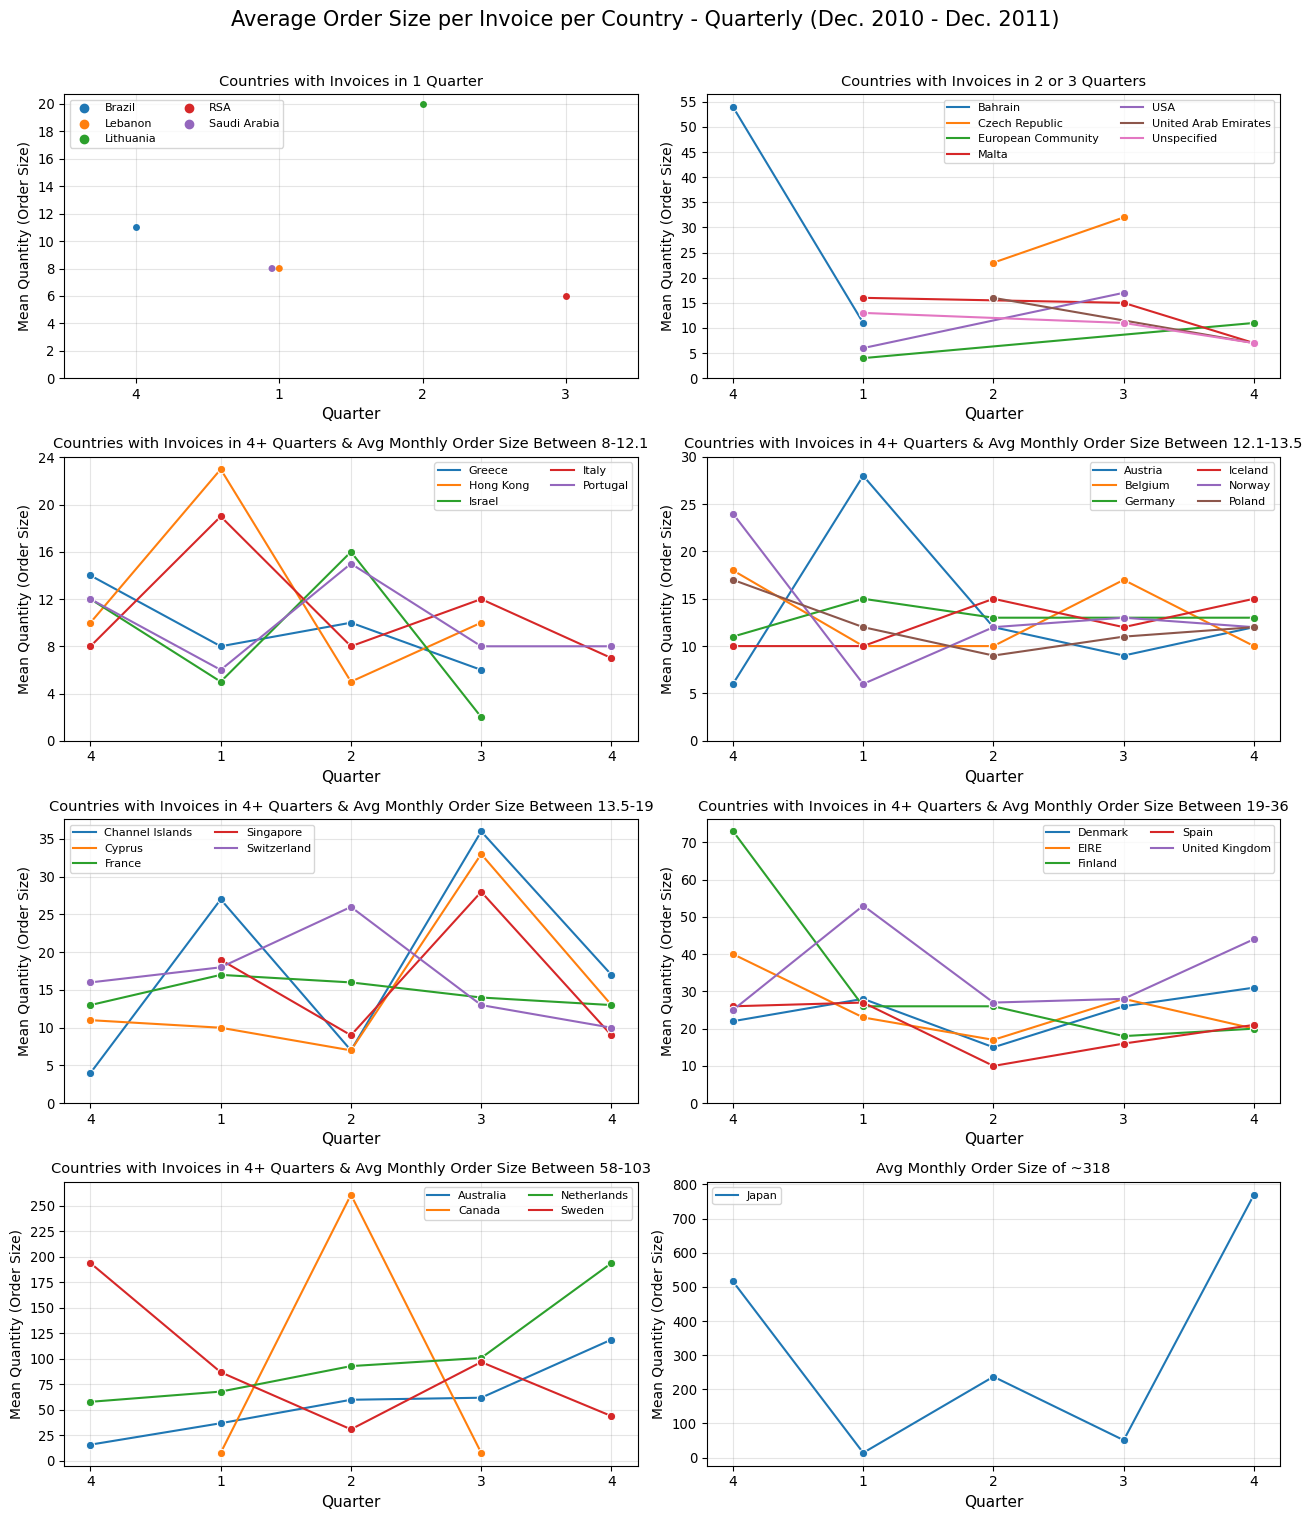

In [41]:
#Make plots illustrating avg order size per invoice, per country, per month
    #split into 8 plots based on avg/min/max Order Size, & # Unique Months each country has data for

fig, axes = plt.subplots(ncols=2, nrows=4, figsize=(13,15))

#PLOT 1 -- Countries with invoices in 1 quarter (5)
ax1_Cs_Q = sorted(['Brazil','Lebanon','Lithuania','RSA','Saudi Arabia'])
ax1 = sns.swarmplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax1_Cs_Q)], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', palette=sns.color_palette(), ax=axes[0,0])
#PLOT 2 -- Countries with invoices in 2/3 quarters (5+2, excluding Canada)
ax2_Cs_Q = sorted(['Bahrain','Czech Republic','European Community','USA','United Arab Emirates','Malta','Unspecified'])
ax2 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax2_Cs_Q)], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', marker='o', palette=sns.color_palette(), ax=axes[0,1])
#PLOT 3 -- Countries with invoices in 4+ quarters, avg monthly order size between 8-12.1 (5)
ax3_Cs_Q = sorted(['Israel','Greece','Hong Kong','Portugal','Italy'])
ax3 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax3_Cs_Q)], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', marker='o', palette=sns.color_palette(), ax=axes[1,0])
#PLOT 4 -- Countries with invoices in 4+ quarters, avg monthly order size between 12.1-13.5 (6)
ax4_Cs_Q = sorted(['Poland','Iceland','Belgium','Germany','Austria','Norway'])
ax4 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax4_Cs_Q)], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', marker='o', palette=sns.color_palette(), ax=axes[1,1])
#PLOT 5 -- Countries with invoices in 4+ quarters, avg monthly order size between 13.5-19 (5)
ax5_Cs_Q = sorted(['Singapore','France','Cyprus','Switzerland','Channel Islands'])
ax5 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax5_Cs_Q)], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', marker='o', palette=sns.color_palette(), ax=axes[2,0])
#PLOT 6 -- Countries with invoices in 4+ quarters, avg monthly order size between 19-36 (5)
ax6_Cs_Q = sorted(['Spain','Denmark','EIRE','Finland','United Kingdom'])
ax6 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax6_Cs_Q)], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', marker='o', palette=sns.color_palette(), ax=axes[2,1])
#PLOT 7 -- Countries with invoices in 4+ quarters, avg monthly order size of 58-103 (4)
ax7_Cs_Q = sorted(['Canada','Australia','Sweden','Netherlands'])
ax7 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country.isin(ax7_Cs_Q)], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', marker='o', palette=sns.color_palette(), ax=axes[3,0])
#PLOT 8 -- Countries with avg. monthly order size of 110+ (Japan)
ax8 = sns.lineplot(data=condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country == 'Japan'], x='Quarter (Year)',
                  y='Mean Quantity (Order Size)', hue='Country', marker='o', palette=sns.color_palette(), ax=axes[3,1])

#edit plot details
fig.suptitle('Average Order Size per Invoice per Country - Quarterly (Dec. 2010 - Dec. 2011)', fontsize=15, y=1.01)
for key, v in {'Countries with Invoices in 1 Quarter':[0,0, 21,2, 2,'upper left'],
              'Countries with Invoices in 2 or 3 Quarters':[0,1, 56,5, 2,'upper right'],
              'Countries with Invoices in 4+ Quarters & Avg Monthly Order Size Between 8-12.1':[1,0, 25,4, 2,'upper right'],
              'Countries with Invoices in 4+ Quarters & Avg Monthly Order Size Between 12.1-13.5':[1,1, 31,5, 2,'upper right'],
              'Countries with Invoices in 4+ Quarters & Avg Monthly Order Size Between 13.5-19':[2,0, 36,5, 2,'upper left'],
              'Countries with Invoices in 4+ Quarters & Avg Monthly Order Size Between 19-36':[2,1, 71,10, 2,'upper right'],
              'Countries with Invoices in 4+ Quarters & Avg Monthly Order Size Between 58-103':[3,0, 251,25, 2,'upper right'],
              'Avg Monthly Order Size of ~318':[3,1, 801,100, 1,'upper left']}.items():
    plt.sca(axes[v[0],v[1]])
    plt.title(key, fontsize=10.5)
    axes[v[0],v[1]].set_xticklabels(labels=condensed_anIII_Q_quan_stats['Quarter (Year)'].str[:1])
    plt.xlabel('Quarter', fontsize=11)
    plt.yticks(ticks=range(0,v[2],v[3]), fontsize=9.5)
    plt.legend(ncols=v[4],fontsize=8, loc=v[5], borderpad=0.3)
    plt.grid(axis='both',alpha=0.2,color='gray')
    plt.tight_layout();


The eight plots above illustrate 38 distinct countries average quarterly order size. In other words, what is the average quantity of items (quantified by the 'Quantity' parameter) purchased by customers from various countries (indicated by the 'Country' parameter) on a quarterly basis. These plots account for data from December 2010 through December 2011, resulting in five distinct quarters of data. 
Eight plots were made to optimize the legibility of each country's data points. Multiple data points play a factor in this process including how many unique quarters each country had associated data points for & the range of average quarterly order sizes per country. For instance, if all 38 countries were imposed onto a single plot, it would be essentially impossible to decipher any distinct data points apart from a couple belong to Japan, because the average quarterly order sizes of Japan significantly outpace that of any other country. 
Recall that the countries "EIRE" & "RSA" most probably correspond to Ireland & the Republic of South Africa.

Recall the motivation in constructing these plots: 
>"Are order sizes from countries outside the United Kingdom significantly larger than orders from inside the United Kingdom?"

For easier reference, the quarterly data points associated with the UK are in the sixth plot in the figure above. Overall, the average quarterly order size of customers from the UK increased over time, but it wasn't a perfectly consistent trend across all five quarters. On the other hand, the number of invoices from customers in the UK did increase across each quarter--UK customers placed more than 110,000 more orders from this company in December 2011 than in December 2010; however, it should be noted that quarter four in 2010 only spanned three weeks whereas the other four quarters spanned multiple months.
The smallest average quarterly order size of customers from the UK was about 25 items per invoice, whereas the maximum average of customers from the UK was more than twice this value: about 53 items per invoice. Interestingly, these values were consecutive & in the first two quarters. Across these five quarters, the average order size of customers from the UK was about 35 items.

These quarterly data points suggest that customers from the UK ordered more often from this company as time went on, but their average order size includes two different trends. It peaked at the start of 2011 despite it being 50% less in the adjacent two quarters. On the other hand, from quarters two through four in 2011, the average order size continuously increased & ended on a positive trajectory heading into 2012. Perhaps the company had some unique sale in the first quarter of 2011 that caused UK customers to order in greater quantities, but whatever marketing strategies the company employed at the end of 2011 clearly had a positive impact on UK customers regarding their order sizes.

In relation to the other countries, the average order size of customers from the UK was in the upper quartile across all five quarters. On the other hand, these average quarterly order sizes of customers from the UK was below the average of all the other 37 countries in three of five quarters.
- In **quarter four in 2010**, the UK had the **eighth** largest average order size of the 38 countries with a value of ~ 25 items per invoice. The average across all the other 37 countries in this quarter was about 53 items. Only five countries had an average order size that exceeded this value in this quarter. The largest average order size in this quarter was from customers in Japan, who ordered about 516 items on average across 65 total invoices.
- In **quarter one**, the UK had the **third** largest average order size with a value of ~ 53 items per invoice. The average across all the other countries in this quarter was about 21 items. Only 11 countries had an average order size that exceeded this value in this quarter. The largest average order size in this quarter was from customers in Sweden, who ordered about 87 items on average across 81 total invoices.
- In **quarter two**, the UK had the **sixth** largest average order size with a value of ~ 27 items per invoice. The average across all the other countries in this quarter was about 33 items. Only four countries had an average order size that exceeded this value in this quarter. The largest average order size in this quarter was from customers in Canada, who ordered about 261 items on average across 58 total invoices.
- In **quarter three**, the UK had the **seventh** largest average order size with a value of ~ 28 items per invoice. The average across all the other countries in this quarter was about 24 items. Only ten countries had an average order size that exceeded this value in this quarter. The largest average order size in this quarter was from customers in the Netherlands, who ordered about 101 items on average across 532 total invoices.
- In **quarter four in 2011**, the UK had the **fifth** largest average order size with a value of ~ 44 items per invoice. The average across all the other countries in this quarter was about 51 items. Only three countries had an average order size that exceeded this value in this quarter. The largest average order size in this quarter was from customers in Japan, who ordered about 770 items on average across 48 total invoices.

Given this data, the average order size between UK customers & the rest of the world seemingly followed opposite trends over the first four quarters of the dataset. The UK's average order size in quarters four (2010) & two were below the average of customers from other countries, but it was above the average in quarters one & three. Interestingly, customers from Japan really enjoyed ordering from this company at the end of the year. 
Since the majority of countries had an average order size below the total average (excluding the UK) in most quarters, it suggests that some countries had some extremely large average order sizes. This can be seen in quarters four with Japan, in particular, & therefore, data from quarters one, two, & three may be more representative. 

If the data from Japan is also excluded (as well as the UK), then the quarterly averages change as follows:
- **Quarter 4 (2010):** ~ 52.9 ---> 30.8 items per invoice on average. UK's average is 25.
- **Quarter 1 (2010):** ~ 20.7 ---> 21.0 items per invoice on average. UK's average is 53.
- **Quarter 2 (2010):** ~ 32.5 ---> 25.7 items per invoice on average. UK's average is 27.
- **Quarter 3 (2010):** ~ 23.9 ---> 22.9 items per invoice on average. UK's average is 28.
- **Quarter 4 (2011):** ~ 50.8 ---> 25.1 items per invoice on average. UK's average is 44.

Clearly, orders from Japan have a significant influence on this quantity in quarter four. Moreover, the average size order of the UK exceeds these aggregate averages in each of the last four quarters as opposed to only two quarters with Japan's data included.

As such, these findings provide enough information to assert that UK customers typically order items in larger quantities on a quarterly basis from this company than customers from most other countries do. The few countries in which customers do usually order in greater quantities on a quarterly basis than those from the UK include Japan, Sweden, the Netherlands, & Australia.

In [42]:
#Compare UK's order-size averages to those of the rest of world
#QUARTER 4 (2010)
display("Quarter 4 (2010):")
display(condensed_anIII_Q_quan_stats[(condensed_anIII_Q_quan_stats.Year == 2010) & (condensed_anIII_Q_quan_stats.Quarter == 4)].sort_values(
    'Mean Quantity (Order Size)',ascending=False).reset_index(drop=True).head(8))
#QUARTER 1
display("Quarter 1:")
display(condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Quarter == 1].sort_values('Mean Quantity (Order Size)',
                                                                        ascending=False).reset_index(drop=True).head(12))
#QUARTER 2
display("Quarter 2:")
display(condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Quarter == 2].sort_values('Mean Quantity (Order Size)',
                                                                        ascending=False).reset_index(drop=True).head(7))
#QUARTER 3
display("Quarter 3:")
display(condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Quarter == 3].sort_values('Mean Quantity (Order Size)',
                                                                        ascending=False).reset_index(drop=True).head(11))
#QUARTER 4 (2011)
display("Quarter 4 (2011):")
display(condensed_anIII_Q_quan_stats[(condensed_anIII_Q_quan_stats.Year == 2011) & (condensed_anIII_Q_quan_stats.Quarter == 4)].sort_values(
    'Mean Quantity (Order Size)',ascending=False).reset_index(drop=True).head(6))

#country quarterly order size avg, excluding UK
display(condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country == 'United Kingdom'])
display("Without UK:")
display(condensed_anIII_Q_quan_stats[condensed_anIII_Q_quan_stats.Country != 'United Kingdom'].groupby(
    ['Year','Quarter'])['Mean Quantity (Order Size)'].mean().reset_index())
#country quarterly order size avg, excluding UK & Japan
display("Without UK & Japan:")
display(condensed_anIII_Q_quan_stats[~condensed_anIII_Q_quan_stats.Country.isin(['United Kingdom','Japan'])].groupby(
    ['Year','Quarter'])['Mean Quantity (Order Size)'].mean().reset_index())


'Quarter 4 (2010):'

,Country,Year,Quarter,Total # Items,Mean # Items,Total Quantity,Mean Total Quantity (Order Size),Mean Quantity (Order Size),Quarter (Year)
0,Japan,2010,4,65,21,4093,1364,516,4 (2010)
1,Sweden,2010,4,26,13,3954,1977,194,4 (2010)
2,Finland,2010,4,17,17,1254,1254,73,4 (2010)
3,Netherlands,2010,4,72,24,6811,2270,58,4 (2010)
4,Bahrain,2010,4,1,1,54,54,54,4 (2010)
5,EIRE,2010,4,374,22,5780,340,40,4 (2010)
6,Spain,2010,4,75,18,867,216,26,4 (2010)
7,United Kingdom,2010,4,38937,25,316027,208,25,4 (2010)


'Quarter 1:'

,Country,Year,Quarter,Total # Items,Mean # Items,Total Quantity,Mean Total Quantity (Order Size),Mean Quantity (Order Size),Quarter (Year)
0,Sweden,2011,1,81,13,8754,1459,87,1 (2011)
1,Netherlands,2011,1,607,33,51632,2868,68,1 (2011)
2,United Kingdom,2011,1,88095,25,869361,254,53,1 (2011)
3,Australia,2011,1,324,19,24763,1456,37,1 (2011)
4,Denmark,2011,1,39,19,1103,551,28,1 (2011)
5,Austria,2011,1,39,9,1324,331,28,1 (2011)
6,Channel Islands,2011,1,222,44,3298,659,27,1 (2011)
7,Spain,2011,1,679,33,7260,363,27,1 (2011)
8,Finland,2011,1,237,29,3442,430,26,1 (2011)
9,Czech Republic,2011,1,15,15,346,346,23,1 (2011)


'Quarter 2:'

...

,Country,Year,Quarter,Total # Items,Mean # Items,Total Quantity,Mean Total Quantity (Order Size),Mean Quantity (Order Size),Quarter (Year)
137,United Kingdom,2010,4,38937,25,316027,208,25,4 (2010)
138,United Kingdom,2011,1,88095,25,869361,254,53,1 (2011)
139,United Kingdom,2011,2,92088,21,912997,216,27,2 (2011)
140,United Kingdom,2011,3,109739,25,1155055,264,28,3 (2011)
141,United Kingdom,2011,4,152284,28,1464889,277,44,4 (2011)


'Without UK:'

,Year,Quarter,Mean Quantity (Order Size)
0,2010,4,52.909091
1,2011,1,20.724138
2,2011,2,32.516129
3,2011,3,23.862069
4,2011,4,50.827586


'Without UK & Japan:'

,Year,Quarter,Mean Quantity (Order Size)
0,2010,4,30.857143
1,2011,1,20.964286
2,2011,2,25.700000
3,2011,3,22.892857
4,2011,4,25.142857


## Analysis III - Conclusions
This section sought to compare the quantities in which customers ordered items from this company based on the country they reside in, specifically in relation to those from & not from the United Kingdom (UK). Multiple parameters were used in the dataset including most prominently 'Quantity,' the number of items purchased per item & 'Country,' the country in which the customer resides. Other parameters used included 'InvoiceNo' & 'InvoiceDate.' 
With the dataset, several statistics were able to be calculated per country including how many total invoices there were, how many items were ordered per invoice, & multiple averages pertaining to these quantities. Moreover, these statistics were also analyzed over time, specifically a quarterly basis, to evaluate these quantities with a stronger lens.

Firstly, the data was analyzed in its entirety irrespective of time. Two approaches were utilized, the main difference of which revolved around whether each individual invoice ('InvoiceNo') was analyzed per country or not. These approaches, previously labeled Approaches 1) & 2), saw similar results for some countries (i.e. the Netherlands, Japan, Sweden, Australia) & more inconsistent results for others (i.e. United Kingdom, Canada). Overall, both approaches found that most countries have a relatively small average order size. Also, there were only a handful of countries that had a value which was above average across all countries.

**Approach 1):** 
Analysis using Approach 1 found that in totaling the number of data points per country & their associated 'Quantity' values, the UK had the seventh smallest average order size (quantity per invoice/order) of the 38 distinct 'Country' values. This approach was less comprehensive because it did not calculate such averages & statistics for each invoice, but instead summed the 'Quantity' parameter & number of data points (counted the number of 'InvoiceNo' values) for each country, then found each country's average. 
The results of this approach found that four countries had an average order size that was significantly greater than that of any other country--the Netherlands, Japan, Sweden, & Australia. The UK had the seventh smallest average order size of the 38 countries, which was about 11 less than the average value across all the other 37 countries. Additionally, the total average order size across all countries was slightly greater without the UK (by about 0.3 items). 

This first approach was deemed less effective because, in not first calculating such statistics by each 'InvoiceNo' value, it did not account in any way for the difference in the number of data points per country. The fact that the company was based in the UK resulted in over 90% of the data points in the dataset pertaining to customers from the UK. Therefore, the UK's average order size was oversaturated in comparison to most other countries. In other words, the large 'Quantity' values (outliers) in orders placed by customers from the UK were diluted to a much more significant effect than those of orders placed by customers in other countries.

**Approach 2):** 
Analysis using Approach 2 was, in theory, more practical & representative than Approach 1 because it evaluated the 'Quantity' parameter per 'InvoiceNo' before aggregate statistics were calculated for each country. Therefore, the number of data points pertaining to each 'Country' value did not have such a great effect on the calculations & results of the analysis using this approach. 
This second approach saw one country significantly outpace all the others in terms of order size per invoice--Japan. As opposed to the first approach, however, the UK had the sixth largest average order size per invoice, which was about six items greater than the average across the 38 countries. This difference is essentially the same when compared to the average value across the other 37 countries, excluding the UK.

As such, it can be said that the order size per invoice of orders placed by customers in the UK is greater than that of most other countries, & is slightly above the average order size value across all countries. On the other hand, this value is significantly outpaced by a handful of other countries in other continents including Japan, the Netherlands, Sweden, Canada, & Australia.


**Incorporating Time:** 
Next, the analysis turned to a time-based method, whilst still following the method of Approach 2. Recall that there are five quarters worth of data, but they do not all span equal lengths of time. Most notably, the first quarter, quarter four in 2010, spans less than a month, whereas the following four quarters (in 2011) all span multiple months. As such, this quarter has less than half the number of invoices than any other quarter.

On a quarterly basis, the smallest average quarterly order size of customers from the UK was about 25 items per invoice (Q4 2010), whereas the maximum average of customers from the UK was more than twice this value: about 53 items per invoice (Q1 2011). Across the five quarters, the average order size of customers from the UK was about 35 items. Overall, the average quarterly order size of customers from the UK increased over time, but it wasn't a perfectly consistent trend across all five quarters. On the other hand, the number of invoices from customers in the UK did increase across each quarter--UK customers placed more than 110,000 more orders from this company in December 2011 than in December 2010.

In relation to the other countries (individually), the average order size of customers from the UK was in the upper quartile across all five quarters. On the other hand, these average quarterly order sizes of customers from the UK was below the average of all the other 37 countries in three of five quarters. 
The average order size between UK customers & the rest of the world (as a whole) seemingly followed opposite trends over the first four quarters of the dataset. The UK's average order size in quarters four (2010) & two were below the average of customers from other countries, but it was above the average in quarters one & three.

Since the majority of countries had an average order size below the total average (excluding the UK) in most quarters, it suggested that some countries had some extremely large average order sizes. In particular, this can be seen in both fourth quarters with Japan, which implied that data from quarters one, two, & three may be more representative. 
Moreover, Japan's & the UK's quarterly averages were removed to see how the UK's quarterly averages would compare to those of the other 36 countries. Instead of two above-average quarterly order sizes, with Japan's quarterly averages included, the UK had four with Japan's data excluded. 
Clearly, transactions of customers from Japan have a significant influence on this quantity in quarter four.

In summary, the findings of these analyses provide enough information to assert that UK customers typically order items in larger quantities on a quarterly basis from this company than customers from most other countries do. The few countries in which customers do usually order in greater quantities on a quarterly basis than those from the UK include Japan, Sweden, the Netherlands, & Australia. There are certainly some customers, particularly from these aforementioned countries, that like to order from this company in extremely large quantities, but they do not necessarily account for the majority of transactions or customers from their respective country.


The idea of analyzing the data on a monthly basis was trialed, but when it came to plotting the data, most countries did not have very much consistency in the number of invoices & order sizes that they had across the 13 distinct months. Moreover, it was challenging to make comparable plots that were legible yet avoided splitting the data too much. As such, the data was only analyzed across quarters with the idea that the data & plots may be more consistent than the monthly data because there are (eight) less distinct quarters than there are distinct months.

Perhaps this analysis could use the 'CustomerID' parameter more thoroughly to determine how customers in different countries account for their country's average order size per invoice. Such inquiries may be more effective in finding outliers, thus making the analysis more representative.

# Analysis IV
**Scenarios are broader questions to help you develop an end-to-end project for your portfolio:**

You are working for an online retailer. Currently, the retailer sells over 4,000 unique products. To take inventory of the items, your manager has asked you whether you can group the products into a small number of categories. The categories should be similar in terms of price and quantity sold and any other characteristics you can extract from the data.

Prepare a report that is accessible to a broad audience. It should outline your motivation, steps, findings, and conclusions.

With the dataset provided, the best way to differentiate between unique products is by using the 'StockCode' & 'Description' parameters; however, as seen in previous sections of this report, there are some 'Description' values that do not describe a specific product. It was hypothesized that these values describe reasons for which an invoice was returned, cancelled, or some other abnormal procedure/transaction. These values are likely not of interest to the manager in the context of this analysis. As such, they can either be dropped beforehand or they can be filtered out of any results following any analyses.

Other parameters that could be of use for this analysis could include 'StockCode,' 'Description,' 'Quantity,' & 'UnitPrice.' 'InvoiceDate,' 'CustomerID,' & 'Country' are more related to the order & customer rather than the product, but they could be explored in future analyses. By comparing how similar data points are in their values across the 'Description,' 'Quantity,' & 'UnitPrice' columns, it could be useful in determining how to categorize the different products.

For this dataset, with half a million data points & more than 4,000 unique products, it is neither realistic nor efficient to go through each of them by hand & determine an optimal category for them all. Fortunately, the manager has requested that the products be grouped into "a small number of categories." The less categories there are, the more generic they will have to be if they are to representatively encompass over 4,000 unique products. Furthermore, categories have to be made that appropriately differentiate the products. Without a knowledgeable understanding of what products this dataset contains, it is difficult to determine what these categories should be named or what products they should/could refer to. As such, it would be helpful to briefly review the products in the dataset in order to brainstorm some categories that best fit & encompass the many products.

With about 530,000 data points in the dataset, it is very likely that a significant number of the ~4,000 unique products have a diverse range of values across all of the parameters. With so many data points, it can make categorizing these products difficult. Instead of trying to classify 4,000 data points based on several parameters, a simpler solution, or at least part of a solution, could be to analyze the dataset via a couple of parameters at a time. The following analyses specifically explored the 'Quantity,' 'UnitPrice,' & 'Description' parameters.

In regards to the 'Quantity' & 'UnitPrice' parameters, which have numerical data, they could be used to categorize the products by splitting them into quantiles. For each 'Description,' the most popular 'Quantity' & 'UnitPrice' values can be obtained which could then be used to classify the products into different categories based on which 'Quantity' &/or 'UnitPrice' quantile they fall within. The number of quantiles would be based on what an ideal & appropriate number of categories would be for classifying the 4,000-plus products.

The 'Description' parameter contains strings of text including letters, numbers, & other characters, resulting in different approaches having to be utilized than those used for the 'Quantity' & 'UnitPrice' variables. With so many unique values, a more ideal & realistic approach would involve using some sort of natural language processing technique or machine learning application that could evaluate the 'Description's values, assess the diversity of the physical items in these values, & conceive some categories that could logically encompass them. Unfortunately, my limited understanding & experience with such techniques makes implementing them challenging & potentially ineffective. Of course, some researching online could be done, but such time is not always available, & so I decided to find other suitable approaches, even though they are probably more time consuming, tedious, & less realistic.

Such approaches involved sifting through the many 'Description' values to find individual words or terms within them in order to determine the actual physical item that the product 'Description' alluded to. With these items, they can be used to brainstorm potential categories that best encompass & differentiate the 4,000-plus distinct 'Description's. With these categories, the products can be classified & put into that which is the best fit. Obviously, without the help of some natural language processing technique or machine learning application, this would be an extremely lengthy & tedious process, & it would be easy for a human to make a mistake or inconsistently categorize the many products.

Furthermore, the concept of string matching was used to quantify relationships between 'Description' values. By comparing different product descriptions linguistically, a similarity score can be calculated where a higher value implies that the two strings are more similar. Of course, this doesn't necessarily imply that pairs of 'Description's with high similarity scores will pertain to the same product. This aspect of string matching doesn't make it the most suitable tool for the purposes of this analysis because a high similarity score typically results from the pieces of text having common words or phrases. Nonetheless, it can still produce valuable results. By searching for pairs of 'Description's that have large similarity scores & reviewing them to check if they pertain to the same product or not, it can become easier to determine whether they belong in the same category. 
The specific method used in this section is called "fuzzy" (or "approximate") string matching, which relates two strings based on their linguistic patterns.

Before proceeding, some potential categories were hypothesized & brainstormed to keep in mind as different 'Description' values were presented & analyzed throughout this section. These categories are listed below. With more time & resources, subsets of these categories can also be constructed. Ideally, these would be based off of other inherent details pertaining to the products such as size, color, price ('UnitPrice'), if they are seasonal items, etc.
- Accessories, Appliances, Arts & Crafts, Clothing, Decorative, Fashion, Furniture, Games, Gifts, Handheld, Holiday, Kitchen, Living Space/Homey, Office Supplies, Personal, Storage, Tech/Electronics, Toys, Vouchers, Non-products, Other, ...

In [43]:
#briefly review & explore products first to determine appropriate & representative categories
anIV_exp_data = data.groupby(['Description','StockCode','UnitPrice','Quantity']).size().reset_index().rename(columns={0:'#'})

#display(anIV_exp_data)
display(anIV_exp_data[anIV_exp_data.UnitPrice != 0.00].sort_values('UnitPrice').reset_index(drop=True).loc[:50])
#display(anIV_exp_data[anIV_exp_data.UnitPrice == 0.00])


,Description,StockCode,UnitPrice,Quantity,#
0,Adjust bad debt,B,-11062.060,1,2
1,PADS TO MATCH ALL CUSHIONS,PADS,0.001,1,3
2,Bank Charges,BANK CHARGES,0.001,1,1
3,Discount,D,0.010,-720,1
4,Discount,D,0.030,-240,1
5,Manual,M,0.030,-120,1
6,ROTATING SILVER ANGELS T-LIGHT HLDR,84347,0.030,-9360,1
7,POPART WOODEN PENCILS ASST,16045,0.040,500,2
8,POPART WOODEN PENCILS ASST,16045,0.040,200,4
9,POPART WOODEN PENCILS ASST,16045,0.040,100,59


### By 'Quantity', 'UnitPrice' parameters
Compare different products by their value in the 'Quantity' & 'UnitPrice' parameters separately & together.

With about 530,000 data points in the dataset, it is very likely that a significant number of the 4,000 unique products have a diverse range of values across all of the parameters. With so many inconsistent data points, it can make categorizing these products difficult. Instead of trying to classify 4,000 data points based on several parameters, a simpler solution, or at least part of a solution, could be to analyze the dataset a couple of parameters at a time. 
In this case, the 'Quantity' & 'UnitPrice' variables were first analyzed. Before considering how to group the products based on these parameters, it can be helpful to have some knowledge of the values of these two parameters. This can be done by exploring their ranges & distributions, & how often a 'Quantity' &/or 'UnitPrice' value shows up per product ('Description.')

In [44]:
#count # data points per 'UnitPrice', 'Quantity' for "PARTY BUNTING" product
data[data.Description == 'PARTY BUNTING'].groupby(['UnitPrice','Quantity']).size().reset_index().rename(columns={0:'#'})
data[data.Description == 'PARTY BUNTING'].groupby(['UnitPrice','Quantity']).size().reset_index().rename(columns={0:'#'}).sort_values(
    '#',ascending=False)


,UnitPrice,Quantity,#
38,4.95,4,454
42,4.95,8,183
36,4.95,2,131
35,4.95,1,119
46,4.95,12,94
...,...,...,...
62,4.96,26,1
61,4.96,18,1
60,4.96,16,1
59,4.96,14,1


In [45]:
#Check unique & total # values in 'Quantity' parameter
neg_Quan_counts = data[data.Quantity < 0].Quantity.value_counts(dropna=False).reset_index()
pos_Quan_counts = data[data.Quantity > 0].Quantity.value_counts(dropna=False).reset_index()
display(pos_Quan_counts.sort_values('Quantity').reset_index(drop=True))
#722 total unique 'Quantity' values, 393 positive values & 329 negative values; they span +/-1 through +/-80995

#Check unique & # values in 'UnitPrice' parameter
UP_counts = data.UnitPrice.value_counts(dropna=False).reset_index().sort_values('UnitPrice').reset_index(drop=True)
display(UP_counts.loc[:40])
display(UP_counts)
    #1,630 total unique values; they span -11062.06 (only negative value) through 38970.00

,Quantity,count
0,1,144495
1,2,81245
2,3,36990
3,4,38393
4,5,11707
...,...,...
388,4800,1
389,5568,1
390,12540,1
391,74215,1


,UnitPrice,count
0,-11062.060,2
1,0.000,2510
2,0.001,4
3,0.010,1
4,0.030,3
5,0.040,66
6,0.060,117
7,0.070,9
8,0.080,53
9,0.090,2


,UnitPrice,count
0,-11062.060,2
1,0.000,2510
2,0.001,4
3,0.010,1
4,0.030,3
...,...,...
1625,13541.330,3
1626,16453.710,1
1627,16888.020,1
1628,17836.460,1


In [46]:
#Count # data points per 'Quantity' & 'UnitPrice'
Quan_UP_pairs = data.groupby(['UnitPrice','Quantity']).size().reset_index().rename(columns={0:'#'}).sort_values('#',ascending=False).reset_index(drop=True)
display(Quan_UP_pairs)
    #8,394 total unique combinations of quantity & unit price
    #most popular combo: £1.25, 12 items, 13,976 data points


,UnitPrice,Quantity,#
0,1.25,12,13976
1,2.46,1,9268
2,2.95,6,9232
3,1.25,1,9065
4,4.13,1,8810
...,...,...,...
8389,0.99,24,1
8390,0.99,18,1
8391,0.98,36,1
8392,0.97,48,1


With more knowledge of these parameters, a process of determining how to split the data points across the values of these two parameters can be undertaken more effectively. Given the immense range of values that these two parameters span & how many unique values there are for each of them, a useful statistical tool that can be used to split these values into groups involves quantiles. Quantiles can split a range of numerical values based on where they are in the distribution. Their ability to split such data in a representative fashion is useful when dealing with the values seen in the 'Quantity' & 'UnitPrice' parameters, which span wide margins & do not have a normal, bell-curve-like distribution.

These quantiles can help in categorizing the 4,000-odd unique products. For each 'Description,' the most common 'Quantity' & 'UnitPrice' values can be obtained. Based on what quantiles these values are in would then dictate the category in which the associated product would fall within. Note that the manager has requested that the 4,000 products be grouped into a small number of categories. Though vague, an ideal number of categories that classify this many products may be anywhere between 10-30. This range should guide how many quantiles are used in splitting the 'Quantity' & 'UnitPrice' values. 
To start, 50 categories were trialed, which corresponded to five & ten quantiles for 'Quantity' & 'UnitPrice' respectively.

In [47]:
#Split the 'Quantity' & 'UnitPrice' values into quantiles -- 10 for 'UnitPrice,' 5 for 'Quantity' --> 50 total categories
#check & evaluate the values of the quantiles
display("Quantiles of 'Quantity' in fifths:")
display([i for i in np.quantile(data.Quantity, [0,.2,.4,.6,.8,1])])
display("Quantiles of 'UnitPrice' in tenths:")
display([i for i in np.quantile(data.UnitPrice, [0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1])])

#Make new columns indicating the quantile of 'Quantity' & 'UnitPrice,' but do this in a new dataframe so as to not modify the original
UP_Quan_quantiles_data = data.copy()
UP_Quan_quantiles_data['Quantity Quantile'] = pd.cut(data.Quantity, bins=[i for i in np.quantile(data.Quantity, [0,.2,.4,.6,.8,1])], 
                     labels=['Q1','Q2','Q3','Q4','Q5'])
UP_Quan_quantiles_data['UP Quantile'] = pd.cut(data.UnitPrice, bins=[i for i in np.quantile(data.UnitPrice, [0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1])], 
                     labels=['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10'])
#verify the new columns
display(UP_Quan_quantiles_data.sample(10))


"Quantiles of 'Quantity' in fifths:"

[-80995.0, 1.0, 2.0, 5.0, 12.0, 80995.0]

"Quantiles of 'UnitPrice' in tenths:"

[-11062.06, 0.64, 0.85, 1.25, 1.65, 2.08, 2.55, 3.75, 4.95, 7.95, 38970.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity Quantile,UP Quantile
426602,573361,20723,STRAWBERRY CHARLOTTE BAG,5,2011-10-30 12:53:00,0.85,14456.0,United Kingdom,Q3,Q2
285404,561903,22030,SWALLOWS GREETING CARD,12,2011-07-31 16:04:00,0.42,17162.0,United Kingdom,Q4,Q1
260746,559816,22481,BLACK TEA TOWEL CLASSIC DESIGN,7,2011-07-12 16:11:00,0.83,NaN,United Kingdom,Q4,Q2
207935,555025,22607,WOODEN ROUNDERS GARDEN SET,2,2011-05-31 11:21:00,9.95,17648.0,United Kingdom,Q2,Q10
11995,537354,22733,3D TRADITIONAL CHRISTMAS STICKERS,3,2010-12-06 12:23:00,1.25,12748.0,United Kingdom,Q3,Q3
261682,C559880,71038,WHITE HANGING BEADS CANDLE HOLDER,-4,2011-07-13 11:32:00,5.45,15493.0,United Kingdom,Q1,Q9
533795,581114,23394,POSTE FRANCE CUSHION COVER,1,2011-12-07 12:19:00,3.75,14527.0,United Kingdom,Q1,Q7
247862,558777,21408,SPOTTY PINK DUCK DOORSTOP,1,2011-07-04 10:23:00,8.29,NaN,United Kingdom,Q1,Q10
66213,541784,22469,HEART OF WICKER SMALL,4,2011-01-21 12:37:00,1.65,17277.0,United Kingdom,Q3,Q4
68869,541878,85099C,JUMBO BAG BAROQUE BLACK WHITE,3,2011-01-24 10:28:00,4.13,NaN,United Kingdom,Q3,Q8


In [48]:
#Group data by 'Quantity' & 'UnitPrice' quantiles to ge total # data points for each pair
    #with 5 quantity quantiles & 10 unitprice quantiles, should be 50 total possible pairs -- each does have 1+ data point
UP_Quan_quantiles_data.groupby(['Quantity Quantile','UP Quantile']).size().reset_index().rename(columns={0:'# data points'})
    #least popular pair--Q5 'Quantity' & Q10 'UnitPrice'-- had 1,019
    #most popular pair--Q1 'Quantity' & Q10 'UnitPrice'-- had 26,055


,Quantity Quantile,UP Quantile,# data points
0,Q1,Q1,7529
1,Q1,Q2,12509
2,Q1,Q3,10482
3,Q1,Q4,15067
4,Q1,Q5,7107
5,Q1,Q6,17689
6,Q1,Q7,20439
7,Q1,Q8,19352
8,Q1,Q9,18850
9,Q1,Q10,26055


With these quantiles across these two parameters, the data can be grouped into different categories based on 'Quantity' &/or 'UnitPrice.' On the other hand, all of these quantiles--five for 'Quantity' & ten for 'UnitPrice,' totaling 50 quantile categories--may amount to too many categories than what the manager desires. A more appropriate number of categories, for approximately 4,000 unique products, may be between 10-20 categories. To accomplish this, the number of quantiles across 'Quantity' & 'UnitPrice' was lessened from five & ten to four & five respectively, which would amass 20 total categories instead of 50.

In [49]:
#Select new quantiles across 'Quantity' & 'UnitPrice'
display("Quantiles of 'Quantity' in quarters:")
display([i for i in np.quantile(data.Quantity, [0,.25,.50,.75,1])])
display("Quantiles of 'UnitPrice' in fifths:")
display([i for i in np.quantile(data.UnitPrice, [0,.2,.4,.6,.8,1])])

#Drop previously made columns which assigned quantiles to each data point for 'Quantity' & 'UnitPrice'
UP_Quan_quantiles_data = UP_Quan_quantiles_data.drop(columns=['Quantity Quantile','UP Quantile'])
#Make new columns indicating the quantile of 'Quantity' & 'UnitPrice'
UP_Quan_quantiles_data['Quantity Quantile'] = pd.cut(data.Quantity, bins=[i for i in np.quantile(data.Quantity, [0,.25,.50,.75,1])], 
                     labels=['Q1','Q2','Q3','Q4'])
UP_Quan_quantiles_data['UP Quantile'] = pd.cut(data.UnitPrice, bins=[i for i in np.quantile(data.UnitPrice, [0,.2,.4,.6,.8,1])], 
                     labels=['Q1','Q2','Q3','Q4','Q5'])
#verify the previous code
display(UP_Quan_quantiles_data.sample(10))


"Quantiles of 'Quantity' in quarters:"

[-80995.0, 1.0, 3.0, 10.0, 80995.0]

"Quantiles of 'UnitPrice' in fifths:"

[-11062.06, 0.85, 1.65, 2.55, 4.95, 38970.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity Quantile,UP Quantile
239745,558066,DOT,DOTCOM POSTAGE,1,2011-06-24 15:45:00,150.77,NaN,United Kingdom,Q1,Q5
191930,553388,22028,PENNY FARTHING BIRTHDAY CARD,12,2011-05-16 16:36:00,0.42,15910.0,United Kingdom,Q4,Q1
467014,576339,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2011-11-14 15:27:00,7.46,14096.0,United Kingdom,Q1,Q5
151209,549546,21936,RED RETROSPOT PICNIC BAG,4,2011-04-10 11:24:00,2.95,16889.0,United Kingdom,Q3,Q4
434182,574034,21528,DAIRY MAID TRADITIONAL TEAPOT,1,2011-11-02 12:45:00,6.95,17841.0,United Kingdom,Q1,Q5
420420,572896,22744,MAKE YOUR OWN MONSOON CARD KIT,6,2011-10-26 14:41:00,2.95,12456.0,Switzerland,Q3,Q4
29486,538799,22064,PINK DOUGHNUT TRINKET POT,6,2010-12-14 11:48:00,1.65,15039.0,United Kingdom,Q3,Q2
80710,543055,22781,GUMBALL MAGAZINE RACK,2,2011-02-03 10:41:00,7.65,12502.0,Spain,Q2,Q5
264061,560053,85025C,PINK HEART SHAPE PHOTO FRAME,12,2011-07-14 15:44:00,1.65,17612.0,United Kingdom,Q4,Q2
13618,537434,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,1,2010-12-06 16:57:00,1.66,NaN,United Kingdom,Q1,Q3


In [50]:
#Group data by 'Quantity' & 'UnitPrice' quantiles to get total # data points for each pair
    #with 4 quantity quantiles & 5 unitprice quantiles, should be 20 total possible pairs -- each does have 1+ data point
UP_Quan_quantiles_data.groupby(['Quantity Quantile','UP Quantile']).size().reset_index().rename(columns={0:'# data points'})
    #least popular pair--Q4 'Quantity' & Q5 'UnitPrice'-- had 3,790
    #most popular pair--Q4 'Quantity' & Q1 'UnitPrice'-- had 55,117


,Quantity Quantile,UP Quantile,# data points
0,Q1,Q1,20038
1,Q1,Q2,25549
2,Q1,Q3,24796
3,Q1,Q4,39791
4,Q1,Q5,44905
5,Q2,Q1,16518
6,Q2,Q2,22801
7,Q2,Q3,18715
8,Q2,Q4,28915
9,Q2,Q5,31286


Using these 20 'Quantity' & 'UnitPrice' quantile pairs, the 4,000-odd unique products can be classified based on each 'Description's associated 'Quantity' & 'UnitPrice' values.

In [51]:
#Want to obtain products associated with each pair of 'Quantity'-'UnitPrice' quantiles

#calculate # unique 'Description's that fall within each 'Quantity'-'UnitPrice' quantile pair
display(UP_Quan_quantiles_data.groupby(['Quantity Quantile','UP Quantile']).Description.nunique().reset_index().rename(
    columns={'Description':'# Unique Products'}))

#get some data regarding how many quantile pairs each 'Description' has data for
num_descs_per_Q_UP_quan = UP_Quan_quantiles_data.groupby(['Description','Quantity Quantile','UP Quantile']).size().reset_index().rename(
    columns={0:'# instances'}).sort_values('# instances',ascending=False)
display(num_descs_per_Q_UP_quan)
    #84,220 total data points; 84,220 / 20 quantile pairs = 4,211 unique 'Descriptions' per quantile pair

#check to see how many quantile pairs each 'Description' associates with
    #display(num_descs_per_Q_UP_quan.groupby('Description').size().reset_index().rename(columns={0:'#'}).sort_values('#'))
    #each 'Description' corresponds to 20 quantile pairs, but this doesn't necessarily imply that each 'Description' has...
        #data points for each quantile pair

#get data points where 'Description' occurs in quantile pair at least once
    #display(num_descs_per_Q_UP_quan[num_descs_per_Q_UP_quan['# instances'] != 0])
    #23,272 total data points, which sum to 535,184 total 'Description's (data points)


,Quantity Quantile,UP Quantile,# Unique Products
0,Q1,Q1,1311
1,Q1,Q2,1307
2,Q1,Q3,1441
3,Q1,Q4,1619
4,Q1,Q5,1563
5,Q2,Q1,1038
6,Q2,Q2,1203
7,Q2,Q3,1210
8,Q2,Q4,1430
9,Q2,Q5,1227


,Description,Quantity Quantile,UP Quantile,# instances
37112,JUMBO BAG RED RETROSPOT,Q3,Q3,839
78153,WHITE HANGING HEART T-LIGHT HOLDER,Q3,Q4,836
49233,PARTY BUNTING,Q3,Q4,790
58084,REGENCY CAKESTAND 3 TIER,Q1,Q5,775
40871,LUNCH BAG RED RETROSPOT,Q3,Q2,726
...,...,...,...,...
32230,GREY ACRYLIC FACETED BANGLE,Q3,Q1,0
32231,GREY ACRYLIC FACETED BANGLE,Q3,Q2,0
32232,GREY ACRYLIC FACETED BANGLE,Q3,Q3,0
32233,GREY ACRYLIC FACETED BANGLE,Q3,Q4,0


There are at least 432 unique 'Description' values for each of the 20 'Quantity'-'UnitPrice' quantile pairs.

In [52]:
#Want to assign each 'Description' to a certain 'Quantity'-'UnitPrice' pair. For each 'Description':
    #sum # data points per 'Quantity' & 'UnitPrice' quantiles
    #get number of 'Quantity'-'UnitPrice' pairs that each 'Description' has at least 1 corresponding data point
    #get 'Quantity'-'UnitPrice' pair that is most popular (or ~3-5 most popular),

display(num_descs_per_Q_UP_quan[num_descs_per_Q_UP_quan.Description == 'JUMBO BAG RED RETROSPOT'].reset_index(drop=True))

#Calculate the total number of data points each 'Description' has per 'Quantity,' 'UnitPrice' quantiles
desc_per_quantiles = pd.pivot_table(num_descs_per_Q_UP_quan, index='Description', values='# instances', columns=['Quantity Quantile','UP Quantile'], 
               aggfunc='sum').reset_index()
display(desc_per_quantiles)


,Description,Quantity Quantile,UP Quantile,# instances
0,JUMBO BAG RED RETROSPOT,Q3,Q3,839
1,JUMBO BAG RED RETROSPOT,Q4,Q3,433
2,JUMBO BAG RED RETROSPOT,Q2,Q3,184
3,JUMBO BAG RED RETROSPOT,Q2,Q4,164
4,JUMBO BAG RED RETROSPOT,Q1,Q3,155
5,JUMBO BAG RED RETROSPOT,Q1,Q4,145
6,JUMBO BAG RED RETROSPOT,Q3,Q4,127
7,JUMBO BAG RED RETROSPOT,Q4,Q2,65
8,JUMBO BAG RED RETROSPOT,Q4,Q4,34
9,JUMBO BAG RED RETROSPOT,Q1,Q2,7


Quantity Quantile                   Description  Q1                Q2         \
UP Quantile                                      Q1  Q2 Q3  Q4 Q5  Q1  Q2 Q3   
0                         *Boombox Ipod Classic   0   0  0   0  1   0   0  0   
1                       *USB Office Mirror Ball   0   0  0   0  2   0   0  0   
2                        10 COLOUR SPACEBOY PEN  17  31  9   0  0   6  22  8   
3                    12 COLOURED PARTY BALLOONS  12  12  0   0  0  17   3  0   
4                     12 DAISY PEGS IN WOOD BOX   0  21  0  12  0   0  23  0   
...                                         ...  ..  .. ..  .. ..  ..  .. ..   
4206                wrongly marked carton 22804   1   0  0   0  0   0   0  0   
4207               wrongly marked. 23343 in box   1   0  0   0  0   0   0  0   
4208               wrongly sold (22719) barcode   0   0  0   0  0   0   0  0   
4209                       wrongly sold as sets   1   0  0   0  0   0   0  0   
4210                          wrongly sold sets   1   0  0   0  0   0   0  0   

Quantity Quantile     ...  Q3               Q4               
UP Quantile       Q4  ...  Q1 Q2 Q3 Q4 Q5   Q1  Q2 Q3 Q4 Q5  
0                  0  ...   0  0  0  0  0    0   0  0  0  0  
1                  0  ...   0  0  0  0  0    0   0  0  0  0  
2                  0  ...   5  1  1  0  0  226   1  0  0  0  
3                  0  ...  58  0  0  0  0   65   0  0  0  0  
4                  1  ...   0  7  0  0  0    0  17  0  0  0  
...               ..  ...  .. .. .. .. ..  ...  .. .. .. ..  
4206               0  ...   0  0  0  0  0    0   0  0  0  0  
4207               0  ...   0  0  0  0  0    0   0  0  0  0  
4208               0  ...   0  0  0  0  0    1   0  0  0  0  
4209               0  ...   0  0  0  0  0    0   0  0  0  0  
4210               0  ...   0  0  0  0  0    0   0  0  0  0  

[4211 rows x 21 columns]

The variable `desc_per_quantiles`, as seen above, counts the total number of data points in which certain values of 'Quantity' & 'UnitPrice' per 'Description' fall into certain 'Quantity' & 'UnitPrice' quantile pairs. There are 4,211 unique products, but some do not specifically describe an actual product (e.g. "wrongly sold as sets"). If the values of each 'Description' were summed row-wise (horizontally), it would total the number of data points per 'Description.' If the values were summed column-wise (vertically), they would total the number of data points per 'Quantity'-'UnitPrice' quantile pair.

In [53]:
#Calculate the number of 'Quantity'-'UnitPrice' pairs that each 'Description' has 1+ data point for
num_quan_per_desc = num_descs_per_Q_UP_quan[num_descs_per_Q_UP_quan['# instances'] > 0].groupby('Description').size().reset_index().rename(
    columns={0:'# Unique Q-UP Quantile Pairs w/Data Points'})
display(num_quan_per_desc)


,Description,# Unique Q-UP Quantile Pairs w/Data Points
0,*Boombox Ipod Classic,1
1,*USB Office Mirror Ball,1
2,10 COLOUR SPACEBOY PEN,11
3,12 COLOURED PARTY BALLOONS,6
4,12 DAISY PEGS IN WOOD BOX,6
...,...,...
4206,wrongly marked carton 22804,1
4207,wrongly marked. 23343 in box,1
4208,wrongly sold (22719) barcode,1
4209,wrongly sold as sets,1


The variable `num_quan_per_desc`, as seen above, indicates the total number of unique 'Quantity'-'UnitPrice' quantile pairs for which each 'Description' has at least one data point for. For example, the product "Boombox Ipod Classic" accounts for data points that only span one 'Quantity'-'UnitPrice' quantile pair, whereas the product "10 COLOUR SPACEBOY PEN" accounts for data points that span 11 different pairs.

In [54]:
#Get five most popular 'Quantity'-'UnitPrice' quantile pairs for each 'Description' based on how many data points there are per pair
    #need to consider dropping 0 values for 'Description's that didn't have data points in multiple quantiles, but wait to...
        #do so until after top five of each 'Description' are selected
desc_top5_quans = num_descs_per_Q_UP_quan.groupby('Description').head(5).sort_values(['Description','# instances'], 
                                        ascending=[True,False]).reset_index(drop=True)
    #21,055 data points
#display(num_descs_per_Q_UP_quan[num_descs_per_Q_UP_quan.Description == 'PARTY BUNTING'].reset_index(drop=True).head(7))
#display(desc_top5_quans[desc_top5_quans.Description == 'wrongly sold sets'])
    #WORKS CORRECTLY

#Want to label/rank each five values per 'Description' based on their popularity
desc_top5_quans['Product Quantile-Pair Popularity Rank (of 5)'] = [i for i in range(0,int(desc_top5_quans.shape[0]/5),1) for i in ['1st','2nd','3rd','4th','5th']]
display(desc_top5_quans)


,Description,Quantity Quantile,UP Quantile,# instances,Product Quantile-Pair Popularity Rank (of 5)
0,*Boombox Ipod Classic,Q1,Q5,1,1st
1,*Boombox Ipod Classic,Q1,Q1,0,2nd
2,*Boombox Ipod Classic,Q4,Q3,0,3rd
3,*Boombox Ipod Classic,Q1,Q3,0,4th
4,*Boombox Ipod Classic,Q1,Q4,0,5th
...,...,...,...,...,...
21050,wrongly sold sets,Q1,Q1,1,1st
21051,wrongly sold sets,Q1,Q3,0,2nd
21052,wrongly sold sets,Q2,Q3,0,3rd
21053,wrongly sold sets,Q2,Q2,0,4th


The variable `desc_top5_quans`, as seen above, identifies the five 'Quantity'-'UnitPrice' quantile pairs in which most of the data points of each 'Description' are accounted for. The five most popular quantile pairs were incorporated to help get an idea of how data points, specifically 'Quantity' & 'UnitPrice' values, were distributed for each 'Description.' Even though the most popular quantile pair accounts for a significant majority of data points for some 'Description's, the opposite could also be true. If some 'Description's have data points that are spread evenly across multiple quantiles, it implies that such products could potentially be included in multiple categories. 
Additionally, there are several 'Description's that do not have enough data points to span five different quantile pairs--indicated by a zero value in the column '# instances.' Even though different ranks may be seen in such instances, these inconsistencies can be disregarded. 
Furthermore, it is possible that the two most popular quantile pairs for some 'Description'(s) account for an equivalent number of data points, thus conceiving the question of what category such products should be put into.

In [55]:
display("Quantiles of 'Quantity' in quarters:")
display([int(i) for i in np.quantile(data.Quantity, [0,.25,.50,.75,1])])
display("Quantiles of 'UnitPrice' in fifths:")
display([i for i in np.quantile(data.UnitPrice, [0,.2,.4,.6,.8,1])])

"Quantiles of 'Quantity' in quarters:"

[-80995, 1, 3, 10, 80995]

"Quantiles of 'UnitPrice' in fifths:"

[-11062.06, 0.85, 1.65, 2.55, 4.95, 38970.0]

In [56]:
#Subset for most popular quantile pair for each description, determine how many products each quantile pair accounts for. This...
    #will set the tone for the number of products across the 20 different categories based on 'Quantity' & 'UnitPrice.'
num_prod_per_categ_20 = desc_top5_quans[desc_top5_quans['Product Quantile-Pair Popularity Rank (of 5)'] == '1st'].groupby(
    ['Quantity Quantile','UP Quantile']).size().reset_index().rename(columns={0:'# Unique Products'})
    #the '# Unique Products' sums to 4,211 -- GOOD

#Want to include range of 'Quantity,' 'UnitPrice' values that fall within each quantile pair
#recall 'Quantity,' 'UnitPrice' quantile values
Q_quantiles_4 = [int(i) for i in np.quantile(data.Quantity, [0,.25,.50,.75,1])]
UP_quantiles_5 = [i for i in np.quantile(data.UnitPrice, [0,.2,.4,.6,.8,1])]

#assign corresponding 'Quantity' quantile range for each 'Quantity Quantile'
    #e.g. for Q1, format as: [-80995, 1]; for Q2: (1, 3], ...   ---> have to format differently for Q1
for i in num_prod_per_categ_20.index:
    #Q1 quantile
    if num_prod_per_categ_20.loc[i,'Quantity Quantile'] == 'Q1':
        num_prod_per_categ_20.loc[i,'Quantity Range (items)'] = "[{}, {}]".format(Q_quantiles_4[0], Q_quantiles_4[1])
    #Q2 quantile
    elif num_prod_per_categ_20.loc[i,'Quantity Quantile'] == 'Q2':
        num_prod_per_categ_20.loc[i,'Quantity Range (items)'] = "({}, {}]".format(Q_quantiles_4[1], Q_quantiles_4[2])
    #Q3 quantile
    elif num_prod_per_categ_20.loc[i,'Quantity Quantile'] == 'Q3':
        num_prod_per_categ_20.loc[i,'Quantity Range (items)'] = "({}, {}]".format(Q_quantiles_4[2], Q_quantiles_4[3])
    #Q4 quantile
    else:
        num_prod_per_categ_20.loc[i,'Quantity Range (items)'] = "({}, {}]".format(Q_quantiles_4[3], Q_quantiles_4[4])

#assign corresponding 'UnitPice' quantile range for each 'UnitPrice Quantile'
    #format similarly as to Quantity
for i in num_prod_per_categ_20.index:
    #Q1 quantile
    if num_prod_per_categ_20.loc[i,'UP Quantile'] == 'Q1':
        num_prod_per_categ_20.loc[i,'UP Range (£)'] = "[{}, {}]".format(UP_quantiles_5[0], UP_quantiles_5[1])
    #Q2 quantile
    elif num_prod_per_categ_20.loc[i,'UP Quantile'] == 'Q2':
        num_prod_per_categ_20.loc[i,'UP Range (£)'] = "({}, {}]".format(UP_quantiles_5[1], UP_quantiles_5[2])
    #Q3 quantile
    elif num_prod_per_categ_20.loc[i,'UP Quantile'] == 'Q3':
        num_prod_per_categ_20.loc[i,'UP Range (£)'] = "({}, {}]".format(UP_quantiles_5[2], UP_quantiles_5[3])
    #Q4 quantile
    elif num_prod_per_categ_20.loc[i,'UP Quantile'] == 'Q4':
        num_prod_per_categ_20.loc[i,'UP Range (£)'] = "({}, {}]".format(UP_quantiles_5[3], UP_quantiles_5[4])
    #Q5 quantile
    else:
        num_prod_per_categ_20.loc[i,'UP Range (£)'] = "({}, {}]".format(UP_quantiles_5[4], UP_quantiles_5[5])

display(num_prod_per_categ_20)


,Quantity Quantile,UP Quantile,# Unique Products,Quantity Range (items),UP Range (£)
0,Q1,Q1,274,"[-80995, 1]","[-11062.06, 0.85]"
1,Q1,Q2,137,"[-80995, 1]","(0.85, 1.65]"
2,Q1,Q3,269,"[-80995, 1]","(1.65, 2.55]"
3,Q1,Q4,401,"[-80995, 1]","(2.55, 4.95]"
4,Q1,Q5,545,"[-80995, 1]","(4.95, 38970.0]"
5,Q2,Q1,67,"(1, 3]","[-11062.06, 0.85]"
6,Q2,Q2,60,"(1, 3]","(0.85, 1.65]"
7,Q2,Q3,48,"(1, 3]","(1.65, 2.55]"
8,Q2,Q4,109,"(1, 3]","(2.55, 4.95]"
9,Q2,Q5,219,"(1, 3]","(4.95, 38970.0]"


The variable `num_prod_per_categ_20`, as seen above, lays out the 20 different categories as defined by quantiles of the 'Quantity' & 'UnitPrice' parameters. The column '# Unique Products' quantifies how many unique products ('Description's) fall within each category. The 'Quantity Range' & 'UP Range' columns directly define the ranges of values for each 'Quantity' & 'UnitPrice' quantile.

Since these categories are defined by products' most popular 'Quantity' & 'UnitPrice' quantiles, they should be named based on these variables. For example, the category concerning products that fall within the quantiles Q1 for 'Quantity' & Q2 for 'UnitPrice' could be named in a cruder fashion in directly stating the range of 'Quantity' & 'UnitPrice' for these quantiles. On the other hand, this category could be labeled using a simpler name, such as something along the lines of "Lowest Quantity, 2nd Lowest UnitPrice."

Furthermore, the products ('Description's) within each of these 20 categories could be evaluated to see what similarities & differences there are between all of the products; however, given the size of some of these categories (the largest accounts for 694 unique products), this is not necessarily realistic without using some natural language processing method that could relate similar &/or similarly named products.

To access the five most popular categories of some product, use the following code:
> `desc_top5_quans[desc_top5_quans.Description == '{enter product description here}']`

To get the most popular category for some product--the category in which the 'Quantity' & 'UnitPrice' of some product most often falls within--add a second condition, as shown below:
> `desc_top5_quans[(desc_top5_quans.Description == '{enter product description here}') & 
        (desc_top5_quans['Product Quantile-Pair Popularity Rank (of 5)'] == '1st')]`

In [57]:
#EXAMPLE:
desc_top5_quans[(desc_top5_quans.Description == '10 COLOUR SPACEBOY PEN')]
#to get associated quantile values, can perform a merge
desc_top5_quans[(desc_top5_quans.Description == '10 COLOUR SPACEBOY PEN')].merge(
    num_prod_per_categ_20, on=['Quantity Quantile','UP Quantile']).drop(columns=['# Unique Products'])


,Description,Quantity Quantile,UP Quantile,# instances,Product Quantile-Pair Popularity Rank (of 5),Quantity Range (items),UP Range (£)
0,10 COLOUR SPACEBOY PEN,Q4,Q1,226,1st,"(10, 80995]","[-11062.06, 0.85]"
1,10 COLOUR SPACEBOY PEN,Q1,Q2,31,2nd,"[-80995, 1]","(0.85, 1.65]"
2,10 COLOUR SPACEBOY PEN,Q2,Q2,22,3rd,"(1, 3]","(0.85, 1.65]"
3,10 COLOUR SPACEBOY PEN,Q1,Q1,17,4th,"[-80995, 1]","[-11062.06, 0.85]"
4,10 COLOUR SPACEBOY PEN,Q1,Q3,9,5th,"[-80995, 1]","(1.65, 2.55]"


In the example above, which analyzes the most popular 'Quantity'-'UnitPrice' categories for the product "10 COLOUR SPACEBOY PEN," this item clearly belongs in the highest ranked category since the significant majority of data points associated with this item correspond to this category. As such, this item, "10 COLOUR SPACEBOY PEN," would be classified into the category with the second largest 'Quantity' quantile & the smallest 'UnitPrice' quantile.

The next section explores & attempts to categorize the 4,000-odd products based on their 'Description' values.

### By 'Description'
Compare values by their 'Description' value. As opposed to the analysis of the 'Quantity' & 'UnitPrice' parameters, which contained numerical values, this parameter contains strings & objects that describe names of products. As such, a different approach will have to be taken.

When dealing with text values, a more efficient approach may be to utilize natural language processing techniques, such as text classification, named entity recognition (tagging), parts-of-speech tagging, &/or information retrieval just to name a few. Unfortunately, I am not proficient enough in such areas of analysis to properly utilize them here in this report, leaving more elementary & time-consuming techniques as better options. With more than 530,000 data points & 4,000+ unique products ('Description' values), such techniques that do not utilize machine learning & similar applications are likely to be unrealistically time consuming. Even if useful solutions are found, which in this case concerns categorizing these products, they aren't likely to be as representative & accurate as what a more efficient process may end up with.

A good relevant example that was found online is linked [here](https://www.kaggle.com/code/fabiendaniel/customer-segmentation). This example, which is described well & in an organized manner, contains concepts & techniques that would be useful for analyses of the 'Description' parameter in regards to this section, but a considerable portion of the steps go over my head. It would not be appropriate for me to simply copy & paste the work from this link into my notebook when I do not understand most of the concepts & functions which are being used. Moreover, it would be easy for me, with my lack of knowledge regarding natural language processing techniques, to make a mistake when importing &/or adapting such code for my purposes.

Nevertheless, one idea that was used in this section was to get a head count of each individual word across all of the 'Description' values in the dataset. In doing so, this would reveal which words are most popular among the 4,000-odd unique products. With these popular words, it could provide some guidance as to how categories could be named & formed. 
It should be noted that the code searches for individual words by splitting each 'Description' value by whitespaces; however, this may not always equate to complete words & instead should be described as finding each group of characters. For example, the 'Description' "FOLK ART GREETING CARD,pack/12" would be split into four different "words," though the last one, "CARD,pack/12," can hardly be referred to as one word. There are several other 'Description's that have values split by other random delimiters including commas, slashes, hyphens, & other characters; however, they, in all likelihood, probably don't show up in most of the product 'Description's.

Furthermore, most words in these product 'Description's do not specify an actual product but instead are adjectives, prepositions, or other non-nouns. For example, of the product "WHITE HANGING HEART T-LIGHT HOLDER," the actual item is the T-light holder, whereas the first three words serve to describe the product. Words like these do not necessarily help when trying to determine how to categorize the 4,000 unique products in the dataset. If anything, they would be useful in creating subcategories like the color of an item, for instance.

Ideally, in finding the most popular words across the unique products, it would provide guidance as to what the majority of items are in the dataset, which would then help provide more insight as to what the different categories may be. After categories are created, it would require going through each unique 'Description' & determining the most appropriate category for which each product would fit. Obviously, without the help of some natural language processing (or other) technique, this would be an extremely lengthy & tedious process, & it would be easy for a human to make a mistake or inconsistently categorize the products.

As discussed multiple times previously, there are values in the 'Description' column that do not describe or include a specific product/item. Once again, these values are not necessarily relevant to this analysis (e.g. "wrongly sold sets"); however, they could simply be grouped into their own category which contains such "products" & their corresponding data points. Given these inconsistencies in the 'Description' parameter, the best way of finding actual products was to search for values which were formatted entirely in uppercase letters. Then, the remaining 'Description's which do not fit this description, which constitutes about 201 unique values, can be sifted through to find any other values that may actually describe a specific product.

In [58]:
#First group 'Description's between those that describe a specific product & those that do not
    #recall that most values that are not entirely uppercase don't describe a product, but some do
#display(data.Description.value_counts(dropna=False).reset_index())

#check for non-products using uppercase formatting in the dataset
    #display(data[data.Description != data.Description.str.upper()])
    #display(data[data.Description != data.Description.str.upper()].Description.value_counts(dropna=False).reset_index()[50:100])
        #201 unique values
#check for products using uppercase formatting in the dataset -- 4,011 unique values
display(data[data.Description == data.Description.str.upper()].Description.value_counts(dropna=False).reset_index())


,Description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2357
1,REGENCY CAKESTAND 3 TIER,2189
2,JUMBO BAG RED RETROSPOT,2156
3,PARTY BUNTING,1720
4,LUNCH BAG RED RETROSPOT,1625
...,...,...
4006,LARGE BLACK DIAMANTE HAIRSLIDE,1
4007,ENAMEL MUG PANTRY,1
4008,WATERING CAN SINGLE HOOK PISTACHIO,1
4009,COUNTRY COTTAGE DOORSTOP GREEN,1


There are 27 'Description's that are not formatted in all uppercase letters that do describe a specific product (or something along the lines of a product):
- BAG 125g SWIRLY MARBLES, BAG 250g SWIRLY MARBLES, BAG 500g SWIRLY MARBLES
- 3 TRADITIONAl BISCUIT CUTTERS SET
- POLYESTER FILLER PAD 40x40cm, POLYESTER FILLER PAD 45x45cm, POLYESTER FILLER PAD 45x30cm, POLYESTER FILLER PAD 30CMx30CM, POLYESTER FILLER PAD 65CMx65CM, POLYESTER FILLER PAD 60CMx40CM
- FRENCH BLUE METAL DOOR SIGN No
- NUMBER TILE COTTAGE GARDEN No, NUMBER TILE VINTAGE FONT No
- ESSENTIAL BALM 3.5g TIN IN ENVELOPE
- FOLK ART GREETING CARD,pack/12
- Dotcomgiftshop Gift Voucher £20.00, Dotcomgiftshop Gift Voucher £10.00, Dotcomgiftshop Gift Voucher £30.00, Dotcomgiftshop Gift Voucher £50.00, Dotcomgiftshop Gift Voucher £40.00, Dotcomgiftshop Gift Voucher £100.00
- THE KING GIFT BAG 25x24x12cm
- FLOWERS HANDAG blue and orange
- Dad's Cab Electronic Meter
- Dr. Jam's Arouzer Stress Ball
- *USB Office Mirror Ball, *Boombox Ipod Classic

These need to be included in the data accounting for actual products.

In [59]:
#Filter for data of interest -- 4,035 'Description's
actual_products_data = data[(data.Description == data.Description.str.upper()) | (data.Description.isin(
    ['BAG 125g SWIRLY MARBLES','BAG 250g SWIRLY MARBLES','BAG 500g SWIRLY MARBLES','3 TRADITIONAl BISCUIT CUTTERS SET',
    'POLYESTER FILLER PAD 40x40cm','POLYESTER FILLER PAD 45x45cm','POLYESTER FILLER PAD 45x30cm','POLYESTER FILLER PAD 30CMx30CM',
    'POLYESTER FILLER PAD 65CMx65CM','POLYESTER FILLER PAD 60CMx40CM','FRENCH BLUE METAL DOOR SIGN No',
    'NUMBER TILE COTTAGE GARDEN No','NUMBER TILE VINTAGE FONT No','ESSENTIAL BALM 3.5g TIN IN ENVELOPE','FOLK ART GREETING CARD,pack/12',
    'Dotcomgiftshop Gift Voucher £20.00','Dotcomgiftshop Gift Voucher £10.00','Dotcomgiftshop Gift Voucher £30.00',
    'Dotcomgiftshop Gift Voucher £50.00','Dotcomgiftshop Gift Voucher £40.00','Dotcomgiftshop Gift Voucher £100.00',
    'THE KING GIFT BAG 25x24x12cm','FLOWERS HANDAG blue and orange',"Dad's Cab Electronic Meter","Dr. Jam's Arouzer Stress Ball",
    '*USB Office Mirror Ball','*Boombox Ipod Classic']))]
#display(actual_products_data.Description.value_counts(dropna=False).reset_index())

#remove extra whitespaces from 'Description' parameter
actual_products_data['Description'] = actual_products_data.Description.str.strip()

#retrieve actual products without their corresponding data
actual_products_descs = actual_products_data.Description.value_counts(dropna=False).reset_index().Description.to_list()
display(actual_products_descs[:5])
display(len(actual_products_descs))


C:\Users\elija\AppData\Local\Temp\ipykernel_24112\3882270730.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_products_data['Description'] = actual_products_data.Description.str.strip()


['WHITE HANGING HEART T-LIGHT HOLDER',
 'REGENCY CAKESTAND 3 TIER',
 'JUMBO BAG RED RETROSPOT',
 'PARTY BUNTING',
 'LUNCH BAG RED RETROSPOT']

4035

In [60]:
#Extract each word (group of characters) per 'Description' & count how many times each word occurs
    #may need to figure out/deal with some strange characters & inconsistencies between words
#do so by using the list of unique 'Description's (4,035 data points) -- this cell takes about 10-15 sec.

#create empty list to append dataframes per 'Description' to
desc_word_counts_dfs = []
#loop through each 'Description'
for item in actual_products_descs:
    #first need to get list of words per 'Description'
    desc_words = item.split(' ')
    #make dictionary counting # instances of each word
    desc_word_counts = {i:desc_words.count(i) for i in desc_words}
    #create dataframe for each 'Description' with a column indicating the word, another column indicating the # instances of word
    df_desc_word_counts = pd.DataFrame.from_dict(data=desc_word_counts, orient='index').reset_index().rename(
        columns={'index':'word', 0:'#'})
    df_desc_word_counts['Description'] = item
    #display(df_desc_word_counts)
    #want to merge all dataframes per 'Description' into a single dataframe. need to put them all into a list to retrieve ...
        #them all outside of this for loop
    desc_word_counts_dfs.append(df_desc_word_counts)

#merge all dataframes per 'Description' into a single dataframe
all_desc_word_counts = pd.concat([df for df in desc_word_counts_dfs], axis=0)


In [61]:
display(all_desc_word_counts)
#totals 17,778 data points -- # of unique words (group of characters) across each 'Description'
#check for duplicates -- NONE
    #display(all_desc_word_counts[all_desc_word_counts.duplicated()])

,word,#,Description
0,WHITE,1,WHITE HANGING HEART T-LIGHT HOLDER
1,HANGING,1,WHITE HANGING HEART T-LIGHT HOLDER
2,HEART,1,WHITE HANGING HEART T-LIGHT HOLDER
3,T-LIGHT,1,WHITE HANGING HEART T-LIGHT HOLDER
4,HOLDER,1,WHITE HANGING HEART T-LIGHT HOLDER
...,...,...,...
1,HOUSE,1,HEN HOUSE W CHICK IN NEST
2,W,1,HEN HOUSE W CHICK IN NEST
3,CHICK,1,HEN HOUSE W CHICK IN NEST
4,IN,1,HEN HOUSE W CHICK IN NEST


In [62]:
#make new dataframe totaling # instances of each word across all 'Description's
desc_word_count_totals = all_desc_word_counts.groupby('word')['#'].sum().reset_index().sort_values(
    ['#','word'],ascending=False).reset_index(drop=True)
display(desc_word_count_totals[desc_word_count_totals['#'] == 1])
    #there are 174 instances of the 'word' "", but using str.strip() on actual_products_data doesn't help
    #there are 2,370 unique "words" (groups of characters)
        #23 words in 100+ unique 'Description's, 64 in 50+ unique 'Description's, 89 in 40+, 121 in 30+, 187 in 20+, 374 in 10+
#display(desc_word_count_totals[desc_word_count_totals['#'] >= 10])

,word,#
1365,£50.00,1
1366,£40.00,1
1367,£30.00,1
1368,£20.00,1
1369,£100.00,1
...,...,...
2365,"""E""",1
2366,"""D""",1
2367,"""C""",1
2368,"""B""",1


C:\Users\elija\AppData\Local\Temp\ipykernel_24112\291058733.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


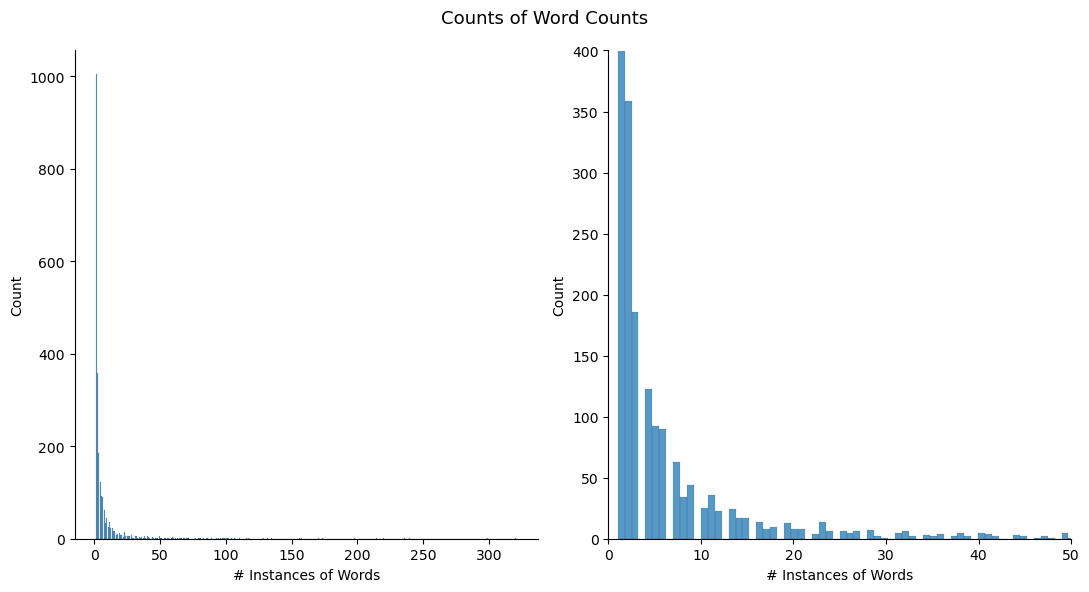

In [63]:
#Make a distribution plot of '#' parameter to evaluate the distribution of word counts across the 'Description's
    #make two to zoom in on most of the data points better
fig, axes = plt.subplots(ncols=2, figsize=(11,6))
ax1 = sns.histplot(data=desc_word_count_totals, x='#', ax=axes[0])
ax2 = sns.histplot(data=desc_word_count_totals, x='#', ax=axes[1])
#adjust range of 2nd plot to better discern the data points
ax2.set(xlim=(0,50), ylim=(0,400))
#edit plot details
fig.suptitle('Counts of Word Counts', fontsize=13)
for i in [0,1]:
    plt.sca(axes[i])
    sns.despine()
    plt.xlabel('# Instances of Words')
    plt.tight_layout();


The figure above displays the distribution of word counts contained in the 4,000-odd distinct 'Description' values. The first (left-hand side) plot displays all of the data whereas the second (right-hand side) only shows a snapshot of this larger figure. Specifically, this second figure only shows words that showed up 50 times or less across all of the unique product 'Description's.

The distribution of this data is very reminiscent of a normal distribution, illustrated by the well-known "bell curve." For most words, they only occur once or a couple of times. As the word count increases, there are significantly less words. Beyond a word count of about 20, the nature of this data changes to a more inconsistent, oscillatory behavior all the way up until a word count of approximately 100-120. 
The most popular word, "SET," occurs 321 times across the 4,000-plus unique 'Description' values. On the other hand, there are 1,005 distinct words (or phrases, numbers, strings of text, etc.) that only occur once.

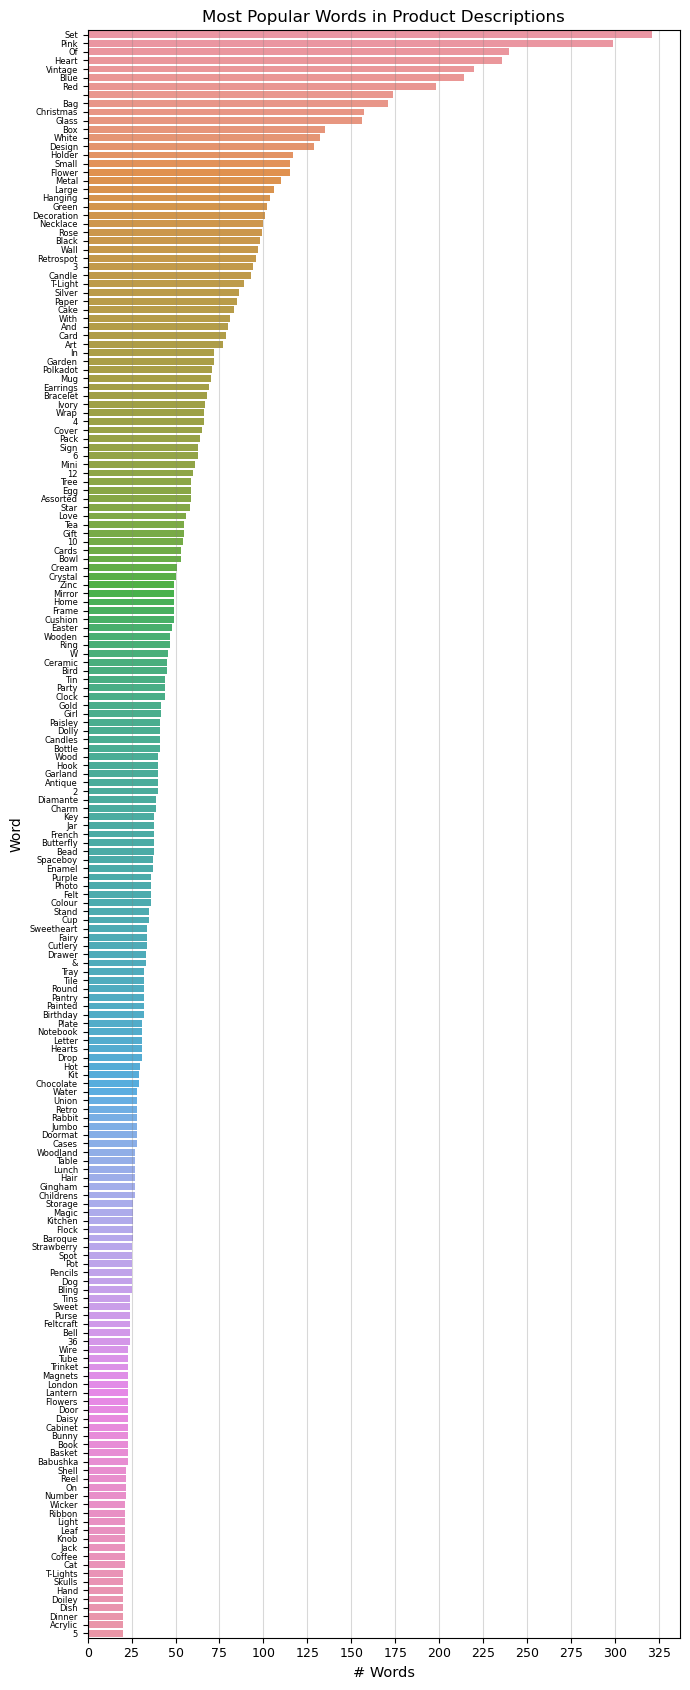

In [64]:
#Make a horizontal bar plot displaying # times words showed up in product 'Description's
#first convert words to title case
desc_word_count_totals_plotting = desc_word_count_totals.copy()
desc_word_count_totals['word'] = desc_word_count_totals.word.str.title()

#construct plot
fig = plt.figure(figsize=(7,17))
ax1 = sns.barplot(data=desc_word_count_totals[desc_word_count_totals['#'] >= 20], y='word',x='#',orient='h')
#edit plot details
plt.title('Most Popular Words in Product Descriptions', fontsize=12)
plt.xlabel('# Words', fontsize=10.5)
plt.xticks(ticks=range(0,326,25), fontsize=9)
plt.ylabel('Word',fontsize=10)
plt.yticks(fontsize=6)
plt.grid(axis='x',alpha=0.3,color='gray')
plt.tight_layout();

The figure above illustrates the number of times each word (or set of characters) shows up across the 4,000-odd unique 'Description' values in the dataset. The term "Set" is the most popular word as it is present in about 320 unique product 'Description's. The words present in this plot, which account for 187 of 2,370 total "words" found across all 'Description' values, all associate with at least 20 distinct 'Description's.

There are a lot of words (or sets of characters) that do not indicate a specific product, but instead, they exemplify adjectives (e.g. colors, "Christmas," "Small," "London"). Though valuable, these words don't provide great insights as to the different kinds of physical products that are sold by the company. As such, it would be helpful to see this plot without these words. Of course, this would require going through the data, identifying words that allude to a physical item, & removing those that do not--a tedious, subjective, & time-consuming process.

With this information, the next step in this process would involve identifying the most popular words that represent physical items, creating between 10-25 categories that encompass these items, then group the 4,000-odd unique products into these categories. Once again, this is not realistic to do by hand & would be more doable using some machine learning program or technique, but my limited knowledge on such subjects restricts this analysis from proceeding much further.

In [65]:
#Explore some popular words & their associated 'Description's to help brainstorm some categories
    #display(data.dropna()[data.dropna().Description.str.contains('SET')].Description.value_counts(dropna=False).reset_index())
    #346 unique 'Description's
display(data.dropna()[data.dropna().Description.str.contains('BAG')].Description.value_counts(dropna=False).reset_index())
    #188 unique 'Descriptinon's


,Description,count
0,JUMBO BAG RED RETROSPOT,1659
1,LUNCH BAG RED RETROSPOT,1345
2,LUNCH BAG BLACK SKULL.,1099
3,LUNCH BAG SPACEBOY DESIGN,1006
4,LUNCH BAG CARS BLUE,1000
...,...,...
183,PINK POLKADOT KIDS BAG,1
184,GREEN WITH METAL BAG CHARM,1
185,SMALL TAHITI BEACH BAG,1
186,AMBER BERTIE GLASS BEAD BAG CHARM,1


By looking up some of the more popular words that are indicative of actual physical items, it can help provide some guidance as to what potential categories can be conceived to classify the 4,000-plus unique products there are in the dataset.

The most popular word (group of characters) is "SET." Looking this word up in the dataset, in the appropriate uppercase format, yields 346 corresponding distinct product 'Description's. Unfortunately, of many of these products that include the word "SET," this word is more of a contextual term & not the actual physical item. For example, in the 'Description' "SET OF 3 CAKE TINS PANTRY DESIGN," the actual product would be the cake tins, whereas the word "SET" informs the customer that this item comes in a set. Given this aspect, the word "SET" could be helpful for creating subcategories, such as does the product come individually, or does it come in multiple--a set.

In the most recent figure, the most popular word that immediately alludes to an actual item would be "BAG." Upon searching this value for corresponding 'Description's in the dataset, it associates with 188 unique products. The most popular product, "JUMBO BAG RED RETROSPOT," does seem to indicate that the word "BAG" is the actual item, whereas the other three terms describe the nature of the bag--the size & appearance. With only 188 'Description's associated with this word, it is easy to go through them & check how many of them specify some sort of bag as the actual item. Most of these 'Description's describe actual bags, but there are a few in which the term "BAG" is not the main item, such as "BAG 125g SWIRLY MARBLES" (the actual item would be the marbles). This example & others may not necessarily belong in the same category as most of these bags. Additional information regarding these 'Description's' values, such as an image of the product, would also be helpful in determining exactly what each 'Description' is referring to, which would further aid in categorizing the many products.

With this information in mind, categories can be brainstormed as to what might best encompass a bag. Keeping in mind that the manager has requested a few number of categories, which, as suggested previously, would ideally be between about 15-30, it may limit how specific or general such a category may be. For instance, if the number of categories for over 4,000 different products weren't as limited, an appropriate category for these items would simply be referred to as "Bags." However, since this may not necessarily be the case, assuming there is plenty of diversity & variation amongst the other 3,800 distinct products in the dataset, a more vague & imprecise category may have to be used. Such a category would need to encompass the basic function of a bag which could include the ability to more effectively store things, carry things, hold things, they are also used in the fashion industry, etc. As such, possible categories for these bags could include "Handheld," "Storage," "Fashion/Appearance," "Accessory," or something along those lines as long as it encompasses a general function of a bag. 
Of course, subcategories could further differentiate between these ~180 unique bag-related products regarding their size, description, appearance, function, price, etc.

These examples illustrate how tedious it would be to go through this dataset by hand, find actual products in the 4,000-plus 'Description's, create categories for them, & classify all of them. Such a process would be done much more capably by some machine learning algorithm or application.

## By 'Description' - Similarity
Another possibility may be to directly compare each 'Description' value to each other to determine their similarities. Those that are more similar could indicate that they describe similar items, suggesting that they could be grouped into a category together. Those that are less similar may imply that they do not share similar items & that they should not be put into the same category; however, this process doesn't directly relate products that are different in name but similar in function. For example, a towel & a mop share very few common features linguistically, but they share some similar purposes in that they can be used for cleaning purposes. Additionally, some 'Description's may be similar linguistically but their products may not have any functional commonalities (e.g. a red bag & a red laptop).

For the purposes of this analysis, such a process of measuring the linguistic similarities of strings can provide some value, but there are many potential pitfalls that can indirectly lead to inaccurate & irrelevant conclusions. Keep this note in mind for this section.

Nonetheless, this section aims to group products together based on their similarity scores as calculated by comparing two 'Description' values linguistically. Since this parameter only contains strings of texts (including various characters & numbers), a quantitative way to evaluate these values could involve measuring how similar they are. Though there are many techniques that can be used to measure similarity between excerpts of text, one that was used in this analysis is the concept of fuzzy string matching. As Nibedita Dutta puts it, 
>"Fuzzy string matching, also known as fuzzy matching, is the technique of finding strings that match with a given string partially and not exactly. When a user misspells a word or enters a word partially, fuzzy string matching helps in finding the right word – as we see in search engines. 
The algorithm behind fuzzy string matching does not simply look at the equivalency of two strings but rather quantifies how close two strings are to one another. This is usually done using a distance metric known as ‘edit distance’. This determines the closeness of two strings by identifying the minimum alterations needed to be done to convert one string into another. There are different types of edit distances that can be used like Levenshtein distance, Hamming distance, Jaro distance, etc" [(Analytics Vidhya)](https://www.analyticsvidhya.com/blog/2021/07/fuzzy-string-matching-a-hands-on-guide/).

The article of interest goes on to describe multiple techniques, metrics, & examples that provide more details as to how fuzzy string matching is done. For this analysis, the `process` module was used, which takes a piece of text as input & measures the _k_-most similar pieces of text in some list. By default, _k_ is five. An example of this function in action is written further below. 
In regards to this dataset, using this module involves taking each of the 4,000-odd unique 'Description' values & measuring their similarity to each of the other 'Description' values. Obviously, this would amount to an enormous number of computations such that this process may take an indescribably long time. As such, a good alternative would be to sample a portion of the 4,000 distinct 'Description' values--this value may depend on how long the code takes to compute. For each 'Description,' the five most similar 'Description's could be obtained. 
These products & their similarity scores could then be put into a dataframe where each row corresponds to a distinct 'Description.' Ten more columns could contain each of the five-most similar 'Description' values & their similarity scores.

This data could be used to determine what products are similar to each other, thus providing some guidance as to what potential categories could be made & how many. Of course, this method would still require considerable levels of meticulous, by-hand analysis in the process of categorizing the 4,000-plus products, but if a metric is available that helps in this process, it would definitely aid in how tedious & time consuming it may be.

In [66]:
#Import fuzzywuzzy to conduct fuzzy string matching
#pip install fuzzywuzzy
from fuzzywuzzy import process

C:\Users\elija\anaconda3\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [67]:
#Test an example
query = 'My name is Ali'
choices = ['My name Ali', 'My name is Ali', 'My Ali', 'Ali me namh', 'name me Ali was', 'ali past used name my', 
           'test', 'MY NAME IS ALI']  
#get a list of matches ordered by score, default limit is 5
process.extract(query, choices, limit=len(choices))

[('My name is Ali', 100),
 ('MY NAME IS ALI', 100),
 ('My name Ali', 95),
 ('My Ali', 86),
 ('ali past used name my', 86),
 ('name me Ali was', 69),
 ('Ali me namh', 68),
 ('test', 28)]

In [68]:
#Do an example using values from this dataset
process.extract('JUMBO BAG RED RETROSPOT', data.Description.unique(), limit=5)


[('JUMBO BAG RED RETROSPOT', 100),
 ('RETROSPOT LAMP', 86),
 ('SET/5 RED RETROSPOT LID GLASS BOWLS', 86),
 ('JUMBO BAG OWLS', 86),
 ('FOLDING UMBRELLA WHITE/RED POLKADOT', 86)]

In [71]:
#For each 'Description,' calculate 5 most similar 'Description's
    #1000 'Description's takes ~10-15 min ---> Would take too long to do for all ~4,000 products

#sample 500 random 'Description's
    #NOTE that the function random.sample() does not have a random_state parameter & so every time it is run, it will select new elements
random_descs_500 = random.sample(actual_products_descs, 500)
#display(random_descs)

In [72]:
#copy the 500 random descriptions
random_descs = random_descs_500
#strip whitespaces from 'Description's
random_descs = [i.strip() for i in random_descs]
    #display(random_descs)

#get similarity scores for these random 'Description's, keep 5 most similar 'Description's
    #specify limit=6 since this code measures similarity of each 'Description' w/itself -- can remove this later
dict_random_descs_sim_scores = { (random_descs[i]) : (process.extract(random_descs[i], random_descs, limit=6)) 
         for i in range(0,len(random_descs),1)}


In [77]:
#Check the dictionary
    #display(dict_random_descs_sim_scores)

#Convert dictionary to a dataframe, rename columns
df_random_descs_sim_scores = pd.DataFrame.from_dict(dict_random_descs_sim_scores, orient='index').reset_index().rename(
    columns={'index':'Description',1:'Most Similar Desc (Similarity Score, of 100)',2:'2nd Most Similar Desc (Similarity Score)',
             3:'3rd Most Similar Desc (Similarity Score)',4:'4th Most Similar Desc (Similarity Score)',
             5:'5th Most Similar Desc (Similarity Score)'})
#drop column calculating similarity between 'Description' & itself
df_random_descs_sim_scores = df_random_descs_sim_scores.drop(columns=[0])

#convert text to title case & make format cleaner -- columns aside from 'Description' need regex
df_random_descs_sim_scores['Description'] = df_random_descs_sim_scores.Description.str.title()
#loop through each row
for i in df_random_descs_sim_scores.index:
    #loop through relevant columns
    for col in ['Most Similar Desc (Similarity Score, of 100)','2nd Most Similar Desc (Similarity Score)',
                '3rd Most Similar Desc (Similarity Score)','4th Most Similar Desc (Similarity Score)',
                '5th Most Similar Desc (Similarity Score)']:
        #Remove unnecessary characters
        temp_str = str(df_random_descs_sim_scores.loc[i,col]).replace('(','').replace(')','').replace("'","").replace(',','')
        #Convert letters to title case -- NEED to be careful to not remove numbers that do not relate to the similarity score, 
            #which is at the end of each string
        temp_str_letters = re.sub("[0-9]+\Z","",temp_str).title().strip()
        #Put number(s) into parentheses -- ONLY want numbers indicating the similarity score, which is at the end of the string
        temp_str_nums = re.findall("[0-9]+\Z",temp_str)[0]
        #Replace old value with new value of the product description
        df_random_descs_sim_scores.loc[i,col] = "{}".format(temp_str_letters)        
        #Construct new string by joining the string referring to the product & the string referring to the similarity score
        temp_str = "{} ({})".format(temp_str_letters, temp_str_nums)
        #Replace old value with new value in the dataframe
        df_random_descs_sim_scores.loc[i,col] = temp_str
        
        #For sorting purposes, it would be considerably easier if the score & product description were in separate columns. 
            #Make it so the columns of each product description & their similarity score are consecutive -- 10 total columns.
    #Make 5 more columns containing the similarity scores per 'Description'
    for col, new_col in {'Most Similar Desc (Similarity Score, of 100)':'Top Similarity Score (of 100)',
                        '2nd Most Similar Desc (Similarity Score)':'2nd SS',
                        '3rd Most Similar Desc (Similarity Score)':'3rd SS',
                        '4th Most Similar Desc (Similarity Score)':'4th SS',
                        '5th Most Similar Desc (Similarity Score)':'5th SS',}.items():
        #Obtain the similarity score (SS)
        ss = re.findall("[0-9]+\Z",df_random_descs_sim_scores.loc[i,col].replace(')',''))[0]
        #Put the similarity score into a new column
        df_random_descs_sim_scores.loc[i,new_col] = ss
        #Remove similarity score from initial column
        df_random_descs_sim_scores.loc[i,col] = re.sub("[0-9]+\Z","",df_random_descs_sim_scores.loc[i,col].replace('(','').replace(')',''))

#Reorganize, rename columns
df_random_descs_sim_scores = df_random_descs_sim_scores.rename(columns={'Most Similar Desc (Similarity Score, of 100)':'Most Similar Desc',
                '2nd Most Similar Desc (Similarity Score)':'2nd Most Similar Desc',
                '3rd Most Similar Desc (Similarity Score)':'3rd Most Similar Desc',
                '4th Most Similar Desc (Similarity Score)':'4th Most Similar Desc',
                '5th Most Similar Desc (Similarity Score)':'5th Most Similar Desc',})[['Description','Most Similar Desc',
            'Top Similarity Score (of 100)','2nd Most Similar Desc','2nd SS','3rd Most Similar Desc','3rd SS',
            '4th Most Similar Desc','4th SS','5th Most Similar Desc','5th SS']]
#Convert similarity-score columns to integers
df_random_descs_sim_scores[['Top Similarity Score (of 100)','2nd SS','3rd SS','4th SS','5th SS']] = df_random_descs_sim_scores[['Top Similarity Score (of 100)',
                            '2nd SS','3rd SS','4th SS','5th SS']].astype('int')

display(df_random_descs_sim_scores)


,Description,Most Similar Desc,Top Similarity Score (of 100),2nd Most Similar Desc,2nd SS,3rd Most Similar Desc,3rd SS,4th Most Similar Desc,4th SS,5th Most Similar Desc,5th SS
0,Bag 125G Swirly Marbles,Jumbo Bag Pears,86,Blue Glass Gems In Bag,47,Green With Metal Bag Charm,47,Blue Daisy Mobile,45,Summer Daisies Bag Charm,45
1,Etched Glass Star Tree Decoration,Christmas Gingham Tree,86,Blue Glass Gems In Bag,86,Glass Bell Jar Large,86,Jingle Bells Tree Decoration,66,Glitter Heart Decoration,60
2,Set 10 Cards Magical Tree 17086,Set 6 Cards Sparkly Reindeer 17262,65,Set 10 Card Christmas Stamps 16963,55,Christmas Gingham Tree,49,Carnival Bracelet,48,Pink/White Christmas Tree 60Cm,46
3,Oriental Red Cushion Cover,Green Peony Cushion Cover,75,Woven Berries Cushion Cover,68,Woven Bubble Gum Cushion Cover,68,Green Pop Art Mao Cushion Cover,67,Pink Paisley Cushion Cover,64
4,Ladle Love Heart Red,Set 36 Colour Pencils Love London,86,Vintage Billboard Love/Hate Mug,86,Zinc Heart Lattice 2 Wall Planter,86,Folkart Zinc Heart Christmas Dec,86,Midnight Blue Pair Heart Hair Slide,86
...,...,...,...,...,...,...,...,...,...,...,...
495,Vintage Photo Album Paris Days,Photo Clip Line,86,Vintage Shells Print,86,Wrap Vintage Petals Design,56,Red Vintage Spot Beaker,54,Black Vintage Crystal Earrings,52
496,Classic White Frame,Large White/Pink Rose Art Flower,86,Love Seat Antique White Metal,86,Pink/White Christmas Tree 60Cm,86,Wood 2 Drawer Cabinet White Finish,86,White And Blue Ceramic Oil Burner,86
497,Painted Yellow Wooden Daisy,Blue Daisy Mobile,86,Wrap Wedding Day,54,Pink/Yellow Flowers Handbag,52,Painted Sea Shell Metal Windchime,50,Yellow Shark Helicopter,46
498,Set Of 2 Tins Jardin De Provence,Balloons Writing Set,86,Cooking Set Retrospot,86,Kensington Coffee Set,86,2 Daisies Hair Comb,86,Set Of 2 Round Tins Dutch Cheese,63


In [74]:
#Calculate descriptive statistics of similarity scores
display(df_random_descs_sim_scores[['Top Similarity Score (of 100)','2nd SS','3rd SS','4th SS','5th SS']].describe().T)


,count,mean,std,min,25%,50%,75%,max
Top Similarity Score (of 100),500.0,79.958,11.804700,47.0,77.75,86.0,86.0,98.0
2nd SS,500.0,74.194,14.409289,44.0,59.75,86.0,86.0,96.0
3rd SS,500.0,69.514,15.523652,41.0,54.00,67.0,86.0,96.0
4th SS,500.0,66.274,15.815410,40.0,52.00,60.0,86.0,86.0
5th SS,500.0,63.438,15.739938,40.0,50.00,56.0,86.0,86.0


For direct explanations regarding RegEx characters & phrases, check [here](https://www.w3schools.com/python/python_regex.asp).

The variable `df_random_descs_sim_scores` details similarity scores for 500 random 'Description' values as calculated using fuzzy string matching. For each of these 500 'Description's, this dataset contains the five most similar 'Description's & their similarity scores (SS). To be specific, this dataset only contains 500 unique 'Description's. These scores are calculated based on the linguistic commonalities between each pair of strings; the more similar the two pieces of text, the higher the value. These similarity scores range from 0-100.

Given the aggregate statistics across the five columns containing the similarity scores, it could be useful to check some of the most & least similar 'Description's to determine why their scores are so high & low respectively. As mentioned previously, a high similarity score doesn't necessarily imply that the two 'Description's revolve around the same product. Such cases could contain similar adjectives & other terms while still pertaining to different products. Such analysis could provide some guidance as to how this data could be used to categorize the subset of products in the dataset.

In [97]:
#Get most similar 'Description's
#display(df_random_descs_sim_scores.sort_values('Top Similarity Score (of 100)',ascending=False).reset_index())
#display(df_random_descs_sim_scores[df_random_descs_sim_scores['Top Similarity Score (of 100)'] >= 87].sort_values(
#    'Top Similarity Score (of 100)',ascending=False).reset_index())
#display(df_random_descs_sim_scores[df_random_descs_sim_scores['Top Similarity Score (of 100)'] >= 86].sort_values(
#    'Top Similarity Score (of 100)',ascending=False).reset_index().loc[:50,:])

display(df_random_descs_sim_scores[df_random_descs_sim_scores['Top Similarity Score (of 100)'] >= 87].sort_values(
    'Top Similarity Score (of 100)',ascending=False).reset_index()[['Description','Most Similar Desc']])

#Investigate these 'Description's in original dataset
#display(data.dropna()[(data.dropna().Description.str.contains('ACRYLIC JEWEL SNOWFLAKE')) | 
#             (data.dropna().Description.str.contains('ACRYLIC JEWEL SNOWFLAKEPINK'))].reset_index(drop=True))


,Description,Most Similar Desc
0,"Acrylic Jewel Snowflake,Pink",Acrylic Jewel Snowflake Pink
1,"Acrylic Jewel Snowflake, Pink",Acrylic Jewel Snowflakepink
2,"Letter ""E"" Bling Key Ring","Letter ""G"" Bling Key Ring"
3,Number Tile Cottage Garden 9,Number Tile Cottage Garden 7
4,"Letter ""T"" Bling Key Ring","Letter ""E"" Bling Key Ring"
5,"Letter ""G"" Bling Key Ring","Letter ""E"" Bling Key Ring"
6,Number Tile Cottage Garden 7,Number Tile Cottage Garden 9
7,"Letter ""C"" Bling Key Ring","Letter ""E"" Bling Key Ring"
8,N0 Singing Metal Sign,No Singing Metal Sign
9,Flower Purple Clock W/Sucker,Flower Purple Clock With Sucker


Note that every time the notebook is run, the dataset above will contain different products because it randomly samplse 500 distinct 'Description' values.

In analyzing the most similar 'Description's, it is evident that some pairs of 'Description's differ by very minimal inconsistencies. The four 'Description's with a 'Top Similarity Score' of 98 all seem to pertain to the same product, their only difference being in a couple of characters: "Acrylic Jewel Snowflakepink" & "Acrylic Jewel Snowflake, Pink"; "Acrylic Jewel Snowflake,Pink" & "Acrylic Jewel Snowflake Pink." Just with this information, it is difficult to determine whether these pairs of values refer to different products, or if they refer to the same & they only differ due to some typo, clerical mistake, or some other error.

This can be verified by referencing the original dataset. For three of these four product 'Description's, they have the same 'StockCode,' & that of the other description only differs by one digit. Therefore, there is some reason to suggest that the difference in the 'Description' values have to do with a typo or some similar mistake. As such, these product pairs should be grouped into a category together.

Other than these four 'Description's, the next most similar pairs of products do have some clear difference between them which usually pertains to some descriptive identifier such as the color, size, or some other key feature regarding the products' design/appearance. Additionally, some other 'Description's & the value they relate the most to contain the same words, but they are either organized differently or there is one single character that differs between the two. The fact that so many distinct 'Description' values are formatted inconsistently &/or contain typos is concerning & inconvenient for performing data analysis (something to bring up to the manager). Moreover, it makes the actual total number of distinct products more difficult to assess. Nonetheless, for 'Description's with a similarity score of at least 87, these pairs of products describe the same general item.

As soon as the similarity score descends below 87 is when pairs of product 'Description's start to refer to different products. Many of these pairs seem to have such a large similarity score because they share some common word(s) (e.g. "Set," "In," some attribute referring to the color or size, etc.); however, there are some cases in which the pairs of 'Description's do refer to the same general item.

As such, pairs of 'Description's with similarity scores of at least 87 can easily be grouped into categories together. At a score of 86 & below, this is not the case & the categorization process would require much more tedious analysis because each pair of 'Description's would have to be looked at by hand to determine if they belong in the same category or not. Regarding pairs of 'Description's with a similarity score of 87 or more, they were classified into some hypothetical categories below as an example of how this process would work. To help understand what some of these products actually were, they were looked up online.
- **Accessories:**
    - Letter "C" Bling Key Ring, Letter "E" Bling Key Ring, Letter "G" Bling Key Ring, Letter "T" Bling Key Ring
- **Decorative:**
    - Number Tile Cottage Garden 7, Number Tile Cottage Garden 9
    - N0 Singing Metal Sign, No Singing Metal Sign
    - Flower Purple Clock W/Sucker, Flower Purple Clock With Sucker, Flower Blue Clock With Sucker
    - Cream Delphinium Artificial Flower, Blue Delphinium Artificial Flower
    - Hanging Chick Green Decoration, Hanging Chick Cream Decoration
    - Crystal Chandelier T-Light Holder, Ivory Chandelier T-Light Holder
    - Embroidered Ribbon Reel Rosie, Embroidered Ribbon Reel Ruby
- **Holiday:**
    - Acrylic Jewel Snowflake,Pink; Acrylic Jewel Snowflake Pink; Acrylic Jewel Snowflake, Pink; Acrylic Jewel Snowflakepink
    - Wrap Gingham Rose, Gingham Rose Wrap
- **Kitchen:**
    - Ceramic Cake Stand + Hanging Cakes, Ceramic Cake Bowl + Hanging Cakes
- **Storage:**
    - 50'S Christmas Gift Bag Large, "Gift Bag Large 50S Christmas", Gift Bag Large 50'S Christmas, "50S Christmas Gift Bag Large"
    - Blue Bunny Easter Egg Basket, Cream Bunny Easter Egg Basket

This example provides a good starting point as to how the 4,000-odd products could be categorized.



A **previous example** of the results of this code & their 'Description' values were classified into the categories listed below.
- **Accessories:**
    - Letter "G" Bling Key Ring, Letter "H" Bling Key Ring, Letter "V" Bling Key Ring
    - Hot Water Bottle Babushka Large, Hot Water Bottle Babushka
- **Books:**
    - Bundle Of 3 Alphabet Exercise Books, Bundle Of 3 Retro Exercise Books
- **Decorative:**
    - Zinc T-Light Holder Stars Large, Zinc T-Light Holder Star Large
    - French Blue Metal Door Sign 4, French Blue Metal Door Sign 6, French Blue Metal Door Sign 8
    - Home Garland Painted Zinc, Love Garland Painted Zinc
    - Blue Delphinium Artificial Flower, Cream Delphinium Artificial Flower
    - Hanging Metal Heart Lantern, Hanging Metal Star Lantern
- **Holiday:**
    - White Christmas Garland Stars Trees; Christmas Garland Starstrees; Christmas Garland Stars,Trees
- **Kitchen:**
    - Set Of 16 Vintage Rose Cutlery, Set Of 16 Vintage Red Cutlery, Set Of 16 Vintage Pistachio Cutlery
- **Office Supplies:**
    - Pink Diamante Pen In Gift Box, Silver Diamante Pen In Gift Box
- **Storage:**
    - Gymkhana Treasure Book Box, Gymkhanna Treasure Book Box
    - Large Deco Jewellery Stand, Large Jewellery Stand
- **Toys:**
    - Blue Shark Helicopter, Red Shark Helicopter

These eight hypothetical categories above may already be encroaching the limit regarding the number of categories requested by the manager considering how few products are included. As such, they may need to be reclassified into more generic categories. An example is listed below containing the same 32 'Description's across only five categories.
- **Accessories:**
    - Letter "G" Bling Key Ring, Letter "H" Bling Key Ring, Letter "V" Bling Key Ring
    - Hot Water Bottle Babushka Large, Hot Water Bottle Babushka
    - Pink Diamante Pen In Gift Box, Silver Diamante Pen In Gift Box
- **Decorative:**
    - Zinc T-Light Holder Stars Large, Zinc T-Light Holder Star Large
    - French Blue Metal Door Sign 4, French Blue Metal Door Sign 6, French Blue Metal Door Sign 8
    - Home Garland Painted Zinc, Love Garland Painted Zinc
    - Blue Delphinium Artificial Flower, Cream Delphinium Artificial Flower
    - Hanging Metal Heart Lantern, Hanging Metal Star Lantern
    - White Christmas Garland Stars Trees; Christmas Garland Starstrees; Christmas Garland Stars,Trees
- **Home:**
    - Bundle Of 3 Alphabet Exercise Books, Bundle Of 3 Retro Exercise Books
    - Set Of 16 Vintage Rose Cutlery, Set Of 16 Vintage Red Cutlery, Set Of 16 Vintage Pistachio Cutlery
- **Storage:**
    - Gymkhana Treasure Book Box, Gymkhanna Treasure Book Box
    - Large Deco Jewellery Stand, Large Jewellery Stand
- **Toys:**
    - Blue Shark Helicopter, Red Shark Helicopter

If all of the products of these examples (62 distinct 'Description's) were compiled into one list, they may look something like the following.
- **Accessories:**
    - Letter "C" Bling Key Ring, Letter "E" Bling Key Ring, Letter "G" Bling Key Ring, Letter "H" Bling Key Ring, Letter "T" Bling Key Ring, Letter "V" Bling Key Ring
    - Hot Water Bottle Babushka Large, Hot Water Bottle Babushka
    - Pink Diamante Pen In Gift Box, Silver Diamante Pen In Gift Box
- **Decorative:**
    - Number Tile Cottage Garden 7, Number Tile Cottage Garden 9
    - N0 Singing Metal Sign, No Singing Metal Sign
    - Flower Purple Clock W/Sucker, Flower Purple Clock With Sucker, Flower Blue Clock With Sucker
    - Cream Delphinium Artificial Flower, Blue Delphinium Artificial Flower
    - Hanging Chick Green Decoration, Hanging Chick Cream Decoration
    - Crystal Chandelier T-Light Holder, Ivory Chandelier T-Light Holder, Zinc T-Light Holder Stars Large, Zinc T-Light Holder Star Large
    - Embroidered Ribbon Reel Rosie, Embroidered Ribbon Reel Ruby
    - French Blue Metal Door Sign 4, French Blue Metal Door Sign 6, French Blue Metal Door Sign 8
    - Home Garland Painted Zinc, Love Garland Painted Zinc
    - Hanging Metal Heart Lantern, Hanging Metal Star Lantern
- **Holiday:**
    - Acrylic Jewel Snowflake,Pink; Acrylic Jewel Snowflake Pink; Acrylic Jewel Snowflake, Pink; Acrylic Jewel Snowflakepink
    - Wrap Gingham Rose, Gingham Rose Wrap
    - White Christmas Garland Stars Trees; Christmas Garland Starstrees; Christmas Garland Stars,Trees
- **Home:**
    - Bundle Of 3 Alphabet Exercise Books, Bundle Of 3 Retro Exercise Books
- **Kitchen:**
    - Ceramic Cake Stand + Hanging Cakes, Ceramic Cake Bowl + Hanging Cakes
    - Set Of 16 Vintage Rose Cutlery, Set Of 16 Vintage Red Cutlery, Set Of 16 Vintage Pistachio Cutlery
- **Storage:**
    - 50'S Christmas Gift Bag Large, "Gift Bag Large 50S Christmas", Gift Bag Large 50'S Christmas, "50S Christmas Gift Bag Large"
    - Blue Bunny Easter Egg Basket, Cream Bunny Easter Egg Basket
    - Gymkhana Treasure Book Box, Gymkhanna Treasure Book Box
    - Large Deco Jewellery Stand, Large Jewellery Stand
- **Toys:**
    - Blue Shark Helicopter, Red Shark Helicopter


## Conclusions - Analysis IV
The **Analysis IV** section sought to analyze the distinct values of the 'Description' column in the dataset & determine & evaluate approaches that could be used to categorize them. Given the size & inconsistencies in the values in this parameter, it was difficult to determine realistic & efficient methods that can be used to sufficiently evaluate & classify the many products. With over 4,000 distinct 'Description's, the most ideal techniques would be to use some natural language processing application or machine learning program. Unfortunately, a lack of experience, knowledge, & confidence in this subject restricted the analysis of this section to more elementary methods, including quantifying the products based on their values across the 'Quantity' & 'UnitPrice' columns, compiling a word count of words & phrases across the product descriptions, & string matching. The latter two approaches used the 'Description' parameter.

One important aspect regarding the 'Description' parameter, which described the associated product in a data point, was that not every value directly referred to a product. There were several instances which theoretically described some important notes regarding the nature of an invoice, such as a mistake made in the transaction, a reason as to why the order was cancelled/returned, or some other detail. These data points weren't necessarily relevant for the purposes of this analysis, & so it was important to account for these values either by filtering them out or dropping them from any relevant analysis. Typically, these data points were able to be found based on the format of the text in the 'Description' column; these "non-products" usually were formatted in all lowercase letters whereas actual products were mostly formatted in all uppercase letters. Product descriptions that contradicted these trends were able to be looked up & filtered out manually.

It is important to note that the manager requested for "the products to be grouped into a small number of categories." Though slightly vague, a "small number" was taken to mean somewhere between 15-30 categories. As such, this is another fundamental aspect to keep in mind when brainstorming these categories.

The first main process utilized in this analysis involved splitting the 'Quantity' & 'UnitPrice' parameters into quantiles. Based on the values of each distinct 'Description' across these two parameters, they were used to group different 'Description's into 20 different categories. This identified what products had the greatest & smallest size orders & what products were the cheapest & most expensive.

Next, the analysis revolved specifically around the 'Description' parameter. The first process involved compiling a word count of each distinct group of characters across each 'Description' value in the dataset. The goal of this method was to determine the most popular words that pertained to actual physical items in order to help provide some basis as to what the categories could potentially be & what items they could encompass. This process wasn't ideal for a couple of reasons. Firstly, it was not incredibly effective in using the most popular words to understand what kinds of physical items there were in the dataset. This limited the analysis' ability to brainstorm the most ideal categories that could encompass the few thousand unique products. Secondly, several words that were compiled were found across multiple product 'Description's, & so it wasn't directly clear as to what item each word could possibly refer to. Ultimately, to use this process to categorize the 4,000-plus unique products, it would require an extremely time consuming & tedious process where it is likely for some human error to occur such as some 'Description' being misidentified or some value(s) being inconsistently classified. 

The final major approach utilized & evaluated in this section had to do with the concept of string matching, which relates two strings based on their linguistic patterns. Specifically, fuzzy string matching, or approximate string matching, was used to quantify the similarity between two 'Description' values. This was done by utilizing a feature of the fuzzywuzzy package called `process.extract()` which calculates a similarity score between two strings of data. 
In using this approach, a dataframe was compiled in which 500 unique 'Description' values from the original dataset were taken (randomly), & the five most similar product 'Description's were obtained along with their similarity scores. Ultimately, this data could be used to determine what products are similar to each other, thus providing some guidance as to what potential categories could be made & how many. Of course, this method would still require considerable levels of meticulous, by-hand analysis in the process of categorizing the 4,000-plus products, but if a metric is available that helps in this process, it would definitely aid in how tedious & time consuming it may be.

Upon investigating the results of this process, it was important to evaluate why different 'Description's were so similar to others. In other words, was their high similarity score because they pertained to the same or similar products, or did it have to do with the other words in their 'Description's which don't directly specify what the product actually is (e.g. color, size, or some other adjective). For the 500 data points sampled, it was determined that for pairs of 'Description's with a similarity score of 87 or higher, they referred to the same product, but there were only a handful of such instances. At a similarity score of 86 or less, pairs of products didn't necessarily pertain to the same item. As a result, there were only a few product 'Description's that were immediately able to be categorized. A couple of examples were made in which seven categories encompassed 62 unique product 'Description's. 
Although this method was effective for these few products, it was not necessarily realistic for all products. For items which don't have large similarity scores with any other product 'Description,' it doesn't provide much guidance as to what category such products fit best in.

In summary, the methods that were utilized exemplify how minimally effective they were in their ability to create categories for & classify the 4,000-odd products. In particular, the most effective method evaluated was the initial approach which classified the products based on their 'Quantity' & 'UnitPrice' values by utitiling quanties; however, it didn't involve any analysis & classification as to the nature of the item itself. To completely accomplish this analysis using these methods, it would take an unrealistic amount of time & labor, which only increases the chances of human error, potentially illegitimizing the results of such analyses.

Obviously, the most effective way to expand on this analysis further would be to utilize some more powerful techniques, such as a natural language processing method or machine learning application. These methods would be much more capable of effectively categorizing the 4,000-plus unique product 'Description's.

Other than the main categories, further analysis could break these categories down further into subcategories. These could be based on multiple factors pertaining to the inherent nature of the products such as their size, color, price, & other physical & associated details.

# Sources
- [Classification/Categorization Example](https://www.kaggle.com/code/fabiendaniel/customer-segmentation)
- [Fuzzy String Matching](https://www.analyticsvidhya.com/blog/2021/07/fuzzy-string-matching-a-hands-on-guide/)